<a href="https://colab.research.google.com/github/drmichael17/stroke-ct-diagnostic-support/blob/main/BRAIN_MRI_CLASSIFIER_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BATCH 1B
# COPY THE EXACT GOOGLE DRIVE DATASET FILES INTO THE PROJECT
# ============================================================

from google.colab import auth
from google.auth import default
from googleapiclient.discovery import build
from pathlib import Path
import io

# Authenticate Colab with Google Drive API
auth.authenticate_user()

credentials, _ = default()

drive_service = build(
    "drive",
    "v3",
    credentials=credentials
)

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Brain_MRI_Project"
)

BDNEURO_RAW = (
    PROJECT_ROOT /
    "01_BDNeuro_MRI_V7_Development" /
    "raw_archive"
)

KAGGLE_RAW = (
    PROJECT_ROOT /
    "02_Nickparvar_Kaggle_External" /
    "raw_archive"
)

BDNEURO_RAW.mkdir(
    parents=True,
    exist_ok=True
)

KAGGLE_RAW.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# EXACT GOOGLE DRIVE FILE IDs
# ------------------------------------------------------------

BDNEURO_FILE_ID = (
    "1MC5aBUJamtsl2spEEG2a_bp207mmlj02"
)

KAGGLE_FILE_ID = (
    "10QxrBtnqIMHESlVy2edNrhfcnoQUdVAC"
)

# ------------------------------------------------------------
# DESTINATION FILENAMES
# ------------------------------------------------------------

BDNEURO_DESTINATION = (
    BDNEURO_RAW /
    "BDNeuro_MRI_V7.zip"
)

KAGGLE_DESTINATION = (
    KAGGLE_RAW /
    "Nickparvar_External.zip"
)

# ------------------------------------------------------------
# DOWNLOAD FUNCTION USING AUTHENTICATED DRIVE API
# ------------------------------------------------------------

from googleapiclient.http import MediaIoBaseDownload


def download_drive_file(
    file_id,
    destination
):

    metadata = (
        drive_service
        .files()
        .get(
            fileId=file_id,
            fields=(
                "id,name,size,mimeType,"
                "md5Checksum"
            )
        )
        .execute()
    )

    print("\nSource file:")
    print("Name:", metadata["name"])
    print("ID:", metadata["id"])
    print(
        "Size:",
        round(
            int(metadata.get("size", 0))
            / (1024 ** 2),
            2
        ),
        "MB"
    )
    print("MIME type:", metadata["mimeType"])

    request = (
        drive_service
        .files()
        .get_media(
            fileId=file_id
        )
    )

    with io.FileIO(
        destination,
        mode="wb"
    ) as file_handle:

        downloader = MediaIoBaseDownload(
            file_handle,
            request,
            chunksize=10 * 1024 * 1024
        )

        done = False

        while not done:

            status, done = (
                downloader.next_chunk()
            )

            if status:
                progress = int(
                    status.progress() * 100
                )

                print(
                    f"Download progress: "
                    f"{progress}%"
                )

    local_size = (
        destination.stat().st_size
    )

    remote_size = int(
        metadata.get(
            "size",
            local_size
        )
    )

    if local_size != remote_size:
        raise RuntimeError(
            "Downloaded file size does "
            "not match Drive file size."
        )

    print("Download completed.")
    print("Saved to:")
    print(destination)

    return metadata


# ------------------------------------------------------------
# DOWNLOAD BDNEURO
# ------------------------------------------------------------

print("=" * 70)
print("BDNEURO-MRI V7")
print("=" * 70)

bd_metadata = download_drive_file(
    BDNEURO_FILE_ID,
    BDNEURO_DESTINATION
)

# ------------------------------------------------------------
# DOWNLOAD NICKPARVAR
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NICKPARVAR EXTERNAL DATASET")
print("=" * 70)

kg_metadata = download_drive_file(
    KAGGLE_FILE_ID,
    KAGGLE_DESTINATION
)

print("\n" + "=" * 70)
print("DATASET FILE TRANSFER COMPLETE")
print("=" * 70)

print("\nBDNeuro:")
print(BDNEURO_DESTINATION)

print("\nNickparvar:")
print(KAGGLE_DESTINATION)

BDNEURO-MRI V7



Source file:
Name: BDNeuro-MRI A Bangladeshi Clinical Brain Tumor MRI.zip
ID: 1MC5aBUJamtsl2spEEG2a_bp207mmlj02
Size: 106.78 MB
MIME type: application/x-zip-compressed
Download progress: 9%
Download progress: 18%
Download progress: 28%
Download progress: 37%
Download progress: 46%
Download progress: 56%
Download progress: 65%
Download progress: 74%
Download progress: 84%
Download progress: 93%
Download progress: 100%
Download completed.
Saved to:
/content/drive/MyDrive/Brain_MRI_Project/01_BDNeuro_MRI_V7_Development/raw_archive/BDNeuro_MRI_V7.zip

NICKPARVAR EXTERNAL DATASET

Source file:
Name: archive (4).zip
ID: 10QxrBtnqIMHESlVy2edNrhfcnoQUdVAC
Size: 157.04 MB
MIME type: application/x-zip-compressed
Download progress: 6%
Download progress: 12%
Download progress: 19%
Download progress: 25%
Download progress: 31%
Download progress: 38%
Download progress: 44%
Download progress: 50%
Download progress: 57%
Download progress: 63%
Download progress: 70%
Download progress: 76%
Download pro

BDNeuro-MRI V7 DOWNLOAD

Destination:
/content/drive/MyDrive/Brain_MRI_Project/01_BDNeuro_MRI_V7_Development/raw_archive/BDNeuro_MRI_V7.zip

HTTP status: 403


HTTPError: 403 Client Error: Forbidden for url: https://api.data.mendeley.com/datasets/zwr4ntf94j/zip/file_downloaded?version=7

In [ ]:
# ============================================================
# BATCH 1C
# EXTRACT VERIFIED DATASETS AND ESTABLISH PERMANENT PATHS
# ============================================================

from pathlib import Path
import zipfile
import shutil

# ------------------------------------------------------------
# PROJECT ROOT
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Brain_MRI_Project"
)

# ------------------------------------------------------------
# SOURCE ARCHIVES
# ------------------------------------------------------------

BDNEURO_ARCHIVE = (
    PROJECT_ROOT /
    "01_BDNeuro_MRI_V7_Development" /
    "raw_archive" /
    "BDNeuro_MRI_V7.zip"
)

KAGGLE_ARCHIVE = (
    PROJECT_ROOT /
    "02_Nickparvar_Kaggle_External" /
    "raw_archive" /
    "Nickparvar_External.zip"
)

# ------------------------------------------------------------
# EXTRACTION DESTINATIONS
# ------------------------------------------------------------

BDNEURO_DATASET_PATH = (
    PROJECT_ROOT /
    "01_BDNeuro_MRI_V7_Development" /
    "extracted_data" /
    "Brain_Tumor_MRI_Dataset_Final"
)

KAGGLE_DATASET_PATH = (
    PROJECT_ROOT /
    "02_Nickparvar_Kaggle_External" /
    "extracted_data" /
    "Nickparvar_Brain_Tumor_MRI"
)

BDNEURO_DATASET_PATH.mkdir(
    parents=True,
    exist_ok=True
)

KAGGLE_DATASET_PATH.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# VERIFY SOURCE ARCHIVES
# ------------------------------------------------------------

if not BDNEURO_ARCHIVE.exists():
    raise FileNotFoundError(
        f"BDNeuro archive not found:\n{BDNEURO_ARCHIVE}"
    )

if not KAGGLE_ARCHIVE.exists():
    raise FileNotFoundError(
        f"Nickparvar archive not found:\n{KAGGLE_ARCHIVE}"
    )

if not zipfile.is_zipfile(BDNEURO_ARCHIVE):
    raise ValueError(
        "BDNeuro source file is not a valid ZIP archive."
    )

if not zipfile.is_zipfile(KAGGLE_ARCHIVE):
    raise ValueError(
        "Nickparvar source file is not a valid ZIP archive."
    )

print("Source archives verified.")

# ============================================================
# EXTRACT BDNEURO
#
# The downloaded BDNeuro file contains another ZIP:
# Brain_Tumor_MRI_Dataset_Final.zip
# ============================================================

print("\nExtracting BDNeuro-MRI V7...")

TEMP_NESTED_ZIP = Path(
    "/content/Brain_Tumor_MRI_Dataset_Final.zip"
)

with zipfile.ZipFile(
    BDNEURO_ARCHIVE,
    "r"
) as outer_zip:

    nested_zip_names = [
        name
        for name in outer_zip.namelist()
        if name.endswith(
            "Brain_Tumor_MRI_Dataset_Final.zip"
        )
    ]

    if len(nested_zip_names) != 1:
        raise RuntimeError(
            "Expected exactly one "
            "Brain_Tumor_MRI_Dataset_Final.zip "
            f"inside BDNeuro archive, found {len(nested_zip_names)}."
        )

    nested_name = nested_zip_names[0]

    print("Nested dataset ZIP found:")
    print(nested_name)

    with outer_zip.open(nested_name) as source:
        with open(
            TEMP_NESTED_ZIP,
            "wb"
        ) as destination:

            shutil.copyfileobj(
                source,
                destination
            )

if not zipfile.is_zipfile(
    TEMP_NESTED_ZIP
):
    raise ValueError(
        "Nested BDNeuro ZIP could not be validated."
    )

with zipfile.ZipFile(
    TEMP_NESTED_ZIP,
    "r"
) as nested_zip:

    nested_zip.extractall(
        BDNEURO_DATASET_PATH
    )

TEMP_NESTED_ZIP.unlink(
    missing_ok=True
)

print("BDNeuro extraction complete.")

# ============================================================
# EXTRACT NICKPARVAR
# ============================================================

print("\nExtracting Nickparvar external dataset...")

with zipfile.ZipFile(
    KAGGLE_ARCHIVE,
    "r"
) as kaggle_zip:

    kaggle_zip.extractall(
        KAGGLE_DATASET_PATH
    )

print("Nickparvar extraction complete.")

# ============================================================
# PERMANENT DATASET PATHS
# ============================================================

BD_TRAIN_DIR = (
    BDNEURO_DATASET_PATH /
    "train"
)

BD_VAL_DIR = (
    BDNEURO_DATASET_PATH /
    "val"
)

BD_TEST_DIR = (
    BDNEURO_DATASET_PATH /
    "test"
)

EXTERNAL_TRAIN_DIR = (
    KAGGLE_DATASET_PATH /
    "Training"
)

EXTERNAL_TEST_DIR = (
    KAGGLE_DATASET_PATH /
    "Testing"
)

print("\n" + "=" * 70)
print("PERMANENT DATASET PATHS")
print("=" * 70)

print("\nBDNeuro training:")
print(BD_TRAIN_DIR)

print("\nBDNeuro validation:")
print(BD_VAL_DIR)

print("\nBDNeuro internal test:")
print(BD_TEST_DIR)

print("\nNickparvar Training:")
print(EXTERNAL_TRAIN_DIR)

print("\nNickparvar Testing:")
print(EXTERNAL_TEST_DIR)

Source archives verified.

Extracting BDNeuro-MRI V7...
Nested dataset ZIP found:
BDNeuro-MRI A Bangladeshi Clinical Brain Tumor MRI/Brain_Tumor_MRI_Dataset_Final.zip
BDNeuro extraction complete.

Extracting Nickparvar external dataset...
Nickparvar extraction complete.

PERMANENT DATASET PATHS

BDNeuro training:
/content/drive/MyDrive/Brain_MRI_Project/01_BDNeuro_MRI_V7_Development/extracted_data/Brain_Tumor_MRI_Dataset_Final/train

BDNeuro validation:
/content/drive/MyDrive/Brain_MRI_Project/01_BDNeuro_MRI_V7_Development/extracted_data/Brain_Tumor_MRI_Dataset_Final/val

BDNeuro internal test:
/content/drive/MyDrive/Brain_MRI_Project/01_BDNeuro_MRI_V7_Development/extracted_data/Brain_Tumor_MRI_Dataset_Final/test

Nickparvar Training:
/content/drive/MyDrive/Brain_MRI_Project/02_Nickparvar_Kaggle_External/extracted_data/Nickparvar_Brain_Tumor_MRI/Training

Nickparvar Testing:
/content/drive/MyDrive/Brain_MRI_Project/02_Nickparvar_Kaggle_External/extracted_data/Nickparvar_Brain_Tumor_MRI

In [ ]:
# ============================================================
# BATCH 1D
# VERIFY DATASET STRUCTURE AND IMAGE COUNTS
# ============================================================

from pathlib import Path
import pandas as pd

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


def count_images(folder):
    folder = Path(folder)

    return sum(
        1
        for file in folder.rglob("*")
        if (
            file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        )
    )


def get_class_counts(split_path):
    split_path = Path(split_path)

    if not split_path.exists():
        raise FileNotFoundError(
            f"Missing split folder: {split_path}"
        )

    results = {}

    for class_folder in sorted(split_path.iterdir()):

        if class_folder.is_dir():
            results[class_folder.name] = count_images(
                class_folder
            )

    return results


# ------------------------------------------------------------
# BDNEURO COUNTS
# ------------------------------------------------------------

bd_rows = []

for split_name, split_path in [
    ("train", BD_TRAIN_DIR),
    ("validation", BD_VAL_DIR),
    ("test", BD_TEST_DIR)
]:

    counts = get_class_counts(split_path)

    for class_name, count in counts.items():

        bd_rows.append(
            {
                "dataset": "BDNeuro V7",
                "split": split_name,
                "class": class_name,
                "count": count
            }
        )

bd_df = pd.DataFrame(bd_rows)


# ------------------------------------------------------------
# NICKPARVAR COUNTS
# ------------------------------------------------------------

kg_rows = []

for split_name, split_path in [
    ("Training", EXTERNAL_TRAIN_DIR),
    ("Testing", EXTERNAL_TEST_DIR)
]:

    counts = get_class_counts(split_path)

    for class_name, count in counts.items():

        kg_rows.append(
            {
                "dataset": "Nickparvar",
                "split": split_name,
                "class": class_name,
                "count": count
            }
        )

kg_df = pd.DataFrame(kg_rows)


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("BDNEURO-MRI V7")
print("=" * 70)

print(
    bd_df.to_string(
        index=False
    )
)

print("\nTotal BDNeuro images:")
print(
    bd_df["count"].sum()
)


print("\n" + "=" * 70)
print("NICKPARVAR EXTERNAL DATASET")
print("=" * 70)

print(
    kg_df.to_string(
        index=False
    )
)

print("\nTotal Nickparvar images:")
print(
    kg_df["count"].sum()
)


# ------------------------------------------------------------
# EXPECTED COUNTS
# ------------------------------------------------------------

expected_bdneuro = {
    ("train", "glioma"): 1534,
    ("train", "meningioma"): 1035,
    ("train", "no_tumor"): 551,
    ("train", "pituitary"): 1040,

    ("validation", "glioma"): 329,
    ("validation", "meningioma"): 222,
    ("validation", "no_tumor"): 118,
    ("validation", "pituitary"): 223,

    ("test", "glioma"): 328,
    ("test", "meningioma"): 221,
    ("test", "no_tumor"): 118,
    ("test", "pituitary"): 222,
}

expected_nickparvar = {
    ("Training", "glioma"): 1400,
    ("Training", "meningioma"): 1400,
    ("Training", "notumor"): 1400,
    ("Training", "pituitary"): 1400,

    ("Testing", "glioma"): 400,
    ("Testing", "meningioma"): 400,
    ("Testing", "notumor"): 400,
    ("Testing", "pituitary"): 400,
}


def validate_counts(
    dataframe,
    expected,
    dataset_name
):

    errors = []

    for (
        split,
        class_name
    ), expected_count in expected.items():

        row = dataframe[
            (dataframe["split"] == split)
            &
            (dataframe["class"] == class_name)
        ]

        if len(row) != 1:

            errors.append(
                f"{split}/{class_name}: class folder missing"
            )

            continue

        actual_count = int(
            row.iloc[0]["count"]
        )

        if actual_count != expected_count:

            errors.append(
                f"{split}/{class_name}: "
                f"expected {expected_count}, "
                f"found {actual_count}"
            )

    if errors:

        print(f"\n{dataset_name} verification FAILED")

        for error in errors:
            print(error)

    else:

        print(
            f"\n{dataset_name} counts verified successfully."
        )


validate_counts(
    bd_df,
    expected_bdneuro,
    "BDNeuro V7"
)

validate_counts(
    kg_df,
    expected_nickparvar,
    "Nickparvar"
)


# ------------------------------------------------------------
# SAVE COUNT MANIFESTS
# ------------------------------------------------------------

MANIFESTS_DIR = (
    PROJECT_ROOT /
    "08_manifests"
)

MANIFESTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

bd_df.to_csv(
    MANIFESTS_DIR /
    "bdneuro_initial_class_counts.csv",
    index=False
)

kg_df.to_csv(
    MANIFESTS_DIR /
    "nickparvar_initial_class_counts.csv",
    index=False
)

print("\nInitial count manifests saved to:")
print(MANIFESTS_DIR)

BDNEURO-MRI V7
   dataset      split      class  count
BDNeuro V7      train     glioma   1534
BDNeuro V7      train meningioma   1035
BDNeuro V7      train   no_tumor    551
BDNeuro V7      train  pituitary   1040
BDNeuro V7 validation     glioma    329
BDNeuro V7 validation meningioma    222
BDNeuro V7 validation   no_tumor    118
BDNeuro V7 validation  pituitary    223
BDNeuro V7       test     glioma    328
BDNeuro V7       test meningioma    221
BDNeuro V7       test   no_tumor    118
BDNeuro V7       test  pituitary    222

Total BDNeuro images:
5941

NICKPARVAR EXTERNAL DATASET
   dataset    split      class  count
Nickparvar Training     glioma   1400
Nickparvar Training meningioma   1400
Nickparvar Training    notumor   1400
Nickparvar Training  pituitary   1400
Nickparvar  Testing     glioma    400
Nickparvar  Testing meningioma    400
Nickparvar  Testing    notumor    400
Nickparvar  Testing  pituitary    400

Total Nickparvar images:
7200

BDNeuro V7 counts verified success

In [ ]:
# ============================================================
# BATCH 2A
# REPRODUCIBILITY, GPU CONFIGURATION AND ENVIRONMENT LOGGING
# ============================================================

# ------------------------------------------------------------
# SET ENVIRONMENT VARIABLES BEFORE IMPORTING TENSORFLOW
# ------------------------------------------------------------

import os

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ------------------------------------------------------------
# STANDARD IMPORTS
# ------------------------------------------------------------

import sys
import json
import random
import platform
import subprocess
from pathlib import Path
from datetime import datetime
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import mixed_precision
from google.colab import drive

# ------------------------------------------------------------
# MOUNT GOOGLE DRIVE
# ------------------------------------------------------------
from pathlib import Path
from google.colab import drive

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_ROOT = DRIVE_ROOT / "MyDrive"

if MYDRIVE_ROOT.exists():
    print("Google Drive is already mounted.")
else:
    print("Google Drive is not mounted. Mounting now...")
    drive.mount("/content/drive")
# ------------------------------------------------------------
# PERMANENT PROJECT PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Brain_MRI_Project"
)

BDNEURO_DATASET_PATH = (
    PROJECT_ROOT /
    "01_BDNeuro_MRI_V7_Development" /
    "extracted_data" /
    "Brain_Tumor_MRI_Dataset_Final"
)

KAGGLE_DATASET_PATH = (
    PROJECT_ROOT /
    "02_Nickparvar_Kaggle_External" /
    "extracted_data" /
    "Nickparvar_Brain_Tumor_MRI"
)

BD_TRAIN_DIR = (
    BDNEURO_DATASET_PATH /
    "train"
)

BD_VAL_DIR = (
    BDNEURO_DATASET_PATH /
    "val"
)

BD_TEST_DIR = (
    BDNEURO_DATASET_PATH /
    "test"
)

EXTERNAL_TRAIN_DIR = (
    KAGGLE_DATASET_PATH /
    "Training"
)

EXTERNAL_TEST_DIR = (
    KAGGLE_DATASET_PATH /
    "Testing"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT /
    "03_checkpoints"
)

RESULTS_DIR = (
    PROJECT_ROOT /
    "04_results"
)

FIGURES_DIR = (
    PROJECT_ROOT /
    "05_figures"
)

PREDICTIONS_DIR = (
    PROJECT_ROOT /
    "06_predictions"
)

LOGS_DIR = (
    PROJECT_ROOT /
    "07_logs"
)

MANIFESTS_DIR = (
    PROJECT_ROOT /
    "08_manifests"
)

for directory in [
    CHECKPOINT_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    LOGS_DIR,
    MANIFESTS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# LOCK STUDY CONFIGURATION
# ------------------------------------------------------------

IMG_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)

BATCH_SIZE = 32

NUM_CLASSES = 4

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

SEEDS = [
    42,
    123,
    2026
]

GLOBAL_SEED = 42

# Prespecified seed for final locked model
FINAL_SEED = 42

PRIMARY_METRIC = "macro_f1"

HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 30

EARLY_STOP_PATIENCE = 5

HEAD_LR = 1e-3
FINE_TUNE_LR = 1e-5

WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

STANDALONE_DROPOUT = 0.30
HYBRID_DROPOUT = 0.40

# ------------------------------------------------------------
# REPRODUCIBILITY FUNCTION
# ------------------------------------------------------------

def set_global_seed(seed):
    """
    Set Python, NumPy and TensorFlow seeds.
    """

    random.seed(seed)

    np.random.seed(seed)

    tf.keras.utils.set_random_seed(
        seed
    )

    print(
        f"Global random seed set to {seed}"
    )


set_global_seed(
    GLOBAL_SEED
)

# ------------------------------------------------------------
# ENABLE DETERMINISTIC TENSORFLOW OPERATIONS
# ------------------------------------------------------------

try:

    tf.config.experimental.enable_op_determinism()

    DETERMINISM_STATUS = (
        "TensorFlow op determinism enabled"
    )

except Exception as error:

    DETERMINISM_STATUS = (
        f"Determinism configuration warning: {error}"
    )

print(
    DETERMINISM_STATUS
)

# ------------------------------------------------------------
# GPU DETECTION
# ------------------------------------------------------------

physical_gpus = (
    tf.config.list_physical_devices(
        "GPU"
    )
)

print("\nGPU devices detected:")

if len(physical_gpus) == 0:

    raise RuntimeError(
        "No GPU detected. "
        "Confirm that the Colab runtime is using A100 GPU."
    )

for gpu in physical_gpus:
    print(gpu)

# ------------------------------------------------------------
# GPU INFORMATION FROM NVIDIA
# ------------------------------------------------------------

try:

    gpu_information = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu="
            "name,memory.total,"
            "driver_version,"
            "compute_cap",
            "--format=csv,noheader"
        ],
        capture_output=True,
        text=True,
        check=True
    ).stdout.strip()

except Exception as error:

    gpu_information = (
        f"Unable to query nvidia-smi: {error}"
    )

print("\nGPU information:")
print(
    gpu_information
)

# ------------------------------------------------------------
# MIXED PRECISION
# ------------------------------------------------------------

mixed_precision.set_global_policy(
    "mixed_float16"
)

precision_policy = (
    mixed_precision.global_policy()
)

print("\nMixed precision policy:")
print(
    precision_policy
)

# ------------------------------------------------------------
# PACKAGE VERSION HELPER
# ------------------------------------------------------------

def package_version(
    package_name
):

    try:
        return version(
            package_name
        )

    except PackageNotFoundError:
        return "not installed"


packages_to_log = [
    "tensorflow",
    "keras",
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "matplotlib",
    "Pillow",
    "opencv-python"
]

package_versions = {
    package:
    package_version(package)
    for package
    in packages_to_log
}

# ------------------------------------------------------------
# VERIFY DATASET PATHS
# ------------------------------------------------------------

dataset_paths = {
    "BDNeuro train":
        BD_TRAIN_DIR,

    "BDNeuro validation":
        BD_VAL_DIR,

    "BDNeuro test":
        BD_TEST_DIR,

    "Nickparvar Training":
        EXTERNAL_TRAIN_DIR,

    "Nickparvar Testing":
        EXTERNAL_TEST_DIR
}

print("\nDataset path verification:")

for name, path in dataset_paths.items():

    status = (
        "FOUND"
        if path.exists()
        else "MISSING"
    )

    print(
        f"{name}: {status}"
    )

    if not path.exists():

        raise FileNotFoundError(
            f"{name} missing at: {path}"
        )

# ------------------------------------------------------------
# CREATE REPRODUCIBILITY LOG
# ------------------------------------------------------------

environment_log = {

    "timestamp":
        datetime.now().isoformat(),

    "python_version":
        sys.version,

    "platform":
        platform.platform(),

    "tensorflow_version":
        tf.__version__,

    "gpu_information":
        gpu_information,

    "mixed_precision_policy":
        str(precision_policy),

    "determinism":
        DETERMINISM_STATUS,

    "python_hash_seed":
        os.environ.get(
            "PYTHONHASHSEED"
        ),

    "tf_deterministic_ops":
        os.environ.get(
            "TF_DETERMINISTIC_OPS"
        ),

    "global_seed":
        GLOBAL_SEED,

    "development_seeds":
        SEEDS,

    "final_model_seed":
        FINAL_SEED,

    "image_size":
        list(IMG_SIZE),

    "batch_size":
        BATCH_SIZE,

    "classes":
        CLASS_NAMES,

    "primary_metric":
        PRIMARY_METRIC,

    "package_versions":
        package_versions
}

environment_log_path = (
    LOGS_DIR /
    "environment_reproducibility.json"
)

with open(
    environment_log_path,
    "w"
) as file:

    json.dump(
        environment_log,
        file,
        indent=4
    )

# ------------------------------------------------------------
# SAVE PACKAGE SNAPSHOT
# ------------------------------------------------------------

pip_freeze_path = (
    LOGS_DIR /
    "pip_freeze.txt"
)

with open(
    pip_freeze_path,
    "w"
) as file:

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "freeze"
        ],
        stdout=file,
        text=True
    )

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BATCH 2A CONFIGURATION SUMMARY")
print("=" * 70)

print(
    "TensorFlow:",
    tf.__version__
)

print(
    "Python:",
    platform.python_version()
)

print(
    "GPU:",
    gpu_information
)

print(
    "Precision:",
    precision_policy
)

print(
    "Development seeds:",
    SEEDS
)

print(
    "Final model seed:",
    FINAL_SEED
)

print(
    "Input size:",
    INPUT_SHAPE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Primary metric:",
    PRIMARY_METRIC
)

print(
    "Classes:",
    CLASS_NAMES
)

print(
    "\nEnvironment log saved to:"
)

print(
    environment_log_path
)

print(
    "\nPackage snapshot saved to:"
)

print(
    pip_freeze_path
)

Google Drive is already mounted.
Global random seed set to 42
TensorFlow op determinism enabled

GPU devices detected:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU information:
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07, 8.0

Mixed precision policy:
<DTypePolicy "mixed_float16">

Dataset path verification:
BDNeuro train: FOUND
BDNeuro validation: FOUND
BDNeuro test: FOUND
Nickparvar Training: FOUND
Nickparvar Testing: FOUND

BATCH 2A CONFIGURATION SUMMARY
TensorFlow: 2.20.0
Python: 3.13.15
GPU: NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07, 8.0
Precision: <DTypePolicy "mixed_float16">
Development seeds: [42, 123, 2026]
Final model seed: 42
Input size: (224, 224, 3)
Batch size: 32
Primary metric: macro_f1
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']

Environment log saved to:
/content/drive/MyDrive/Brain_MRI_Project/07_logs/environment_reproducibility.json

Package snapshot saved to:
/content/drive/MyDrive/Brain_MRI_Project/07_logs/pip_freeze.txt


BDNEURO-MRI V7 INTEGRITY AUDIT

Images queued for audit: 5,941


Auditing BDNeuro images:   0%|          | 0/5941 [00:00<?, ?it/s]


Image manifest saved:
/content/drive/MyDrive/Brain_MRI_Project/08_manifests/bdneuro_v7_image_manifest.csv

BASIC INTEGRITY
Total images:       5,941
Readable images:    5,941
Unreadable images:  0
Zero-byte files:    0

IMAGE MODES
mode  channels  count
 RGB         3   4138
   L         1   1800
RGBA         4      3

FILE FORMATS
extension  count
     .jpg   5940
    .jpeg      1

IMAGE DIMENSIONS
Unique width-height combinations: 349

Most common dimensions:
 width  height  count
   512     512   3297
   224     224   1958
   225     225     73
   236     236     27
   256     256     22
   630     630     15
   442     442     14
   192     192     12
   200     252     12
   232     217     11
   228     221      9
   208     242      9
   201     251      9
   300     168      9
   214     236      7

EXACT DUPLICATE AUDIT
Exact duplicate groups: 0
Files involved in duplicate groups: 0
Redundant duplicate files: 0
Duplicate groups crossing dataset splits: 0
Duplicate groups cros

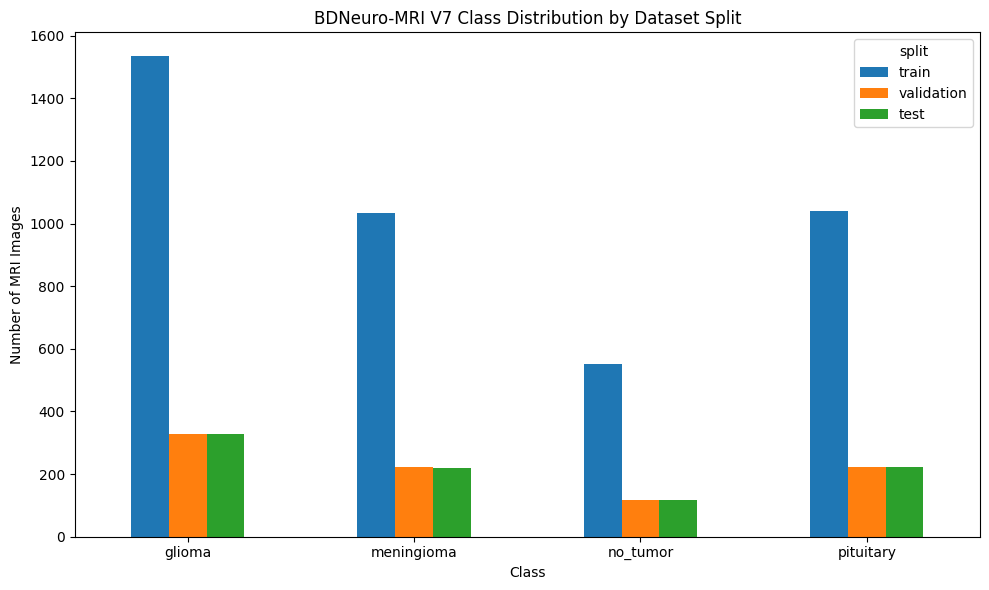

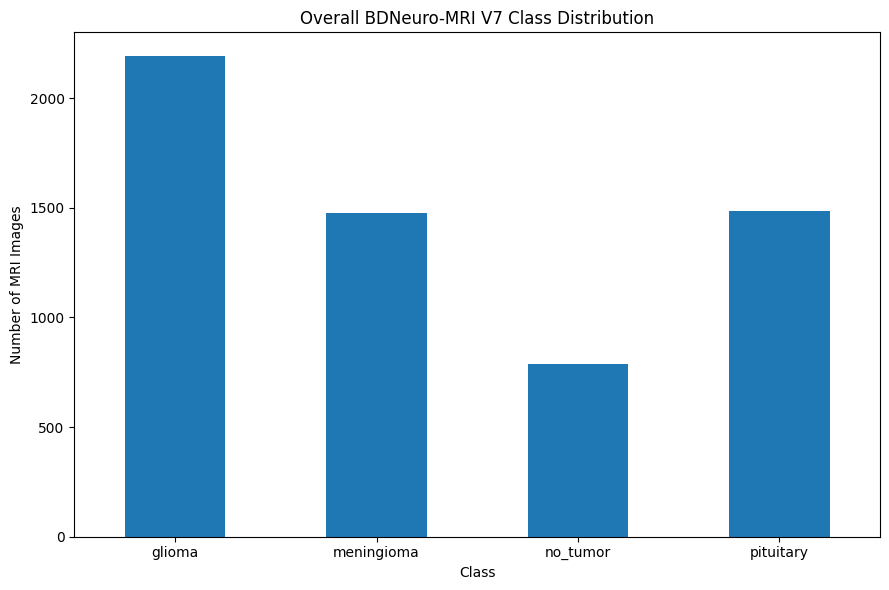

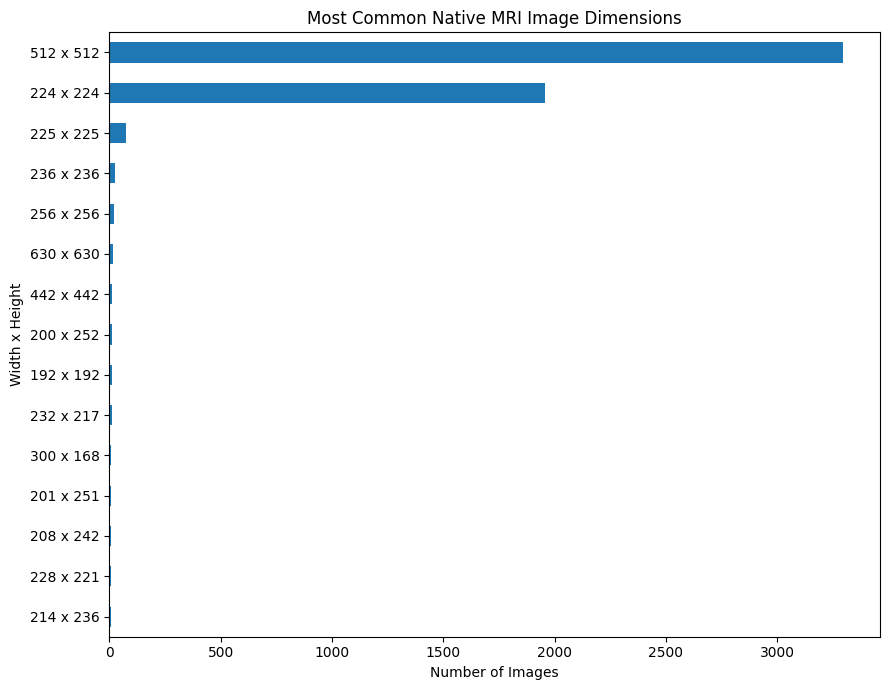

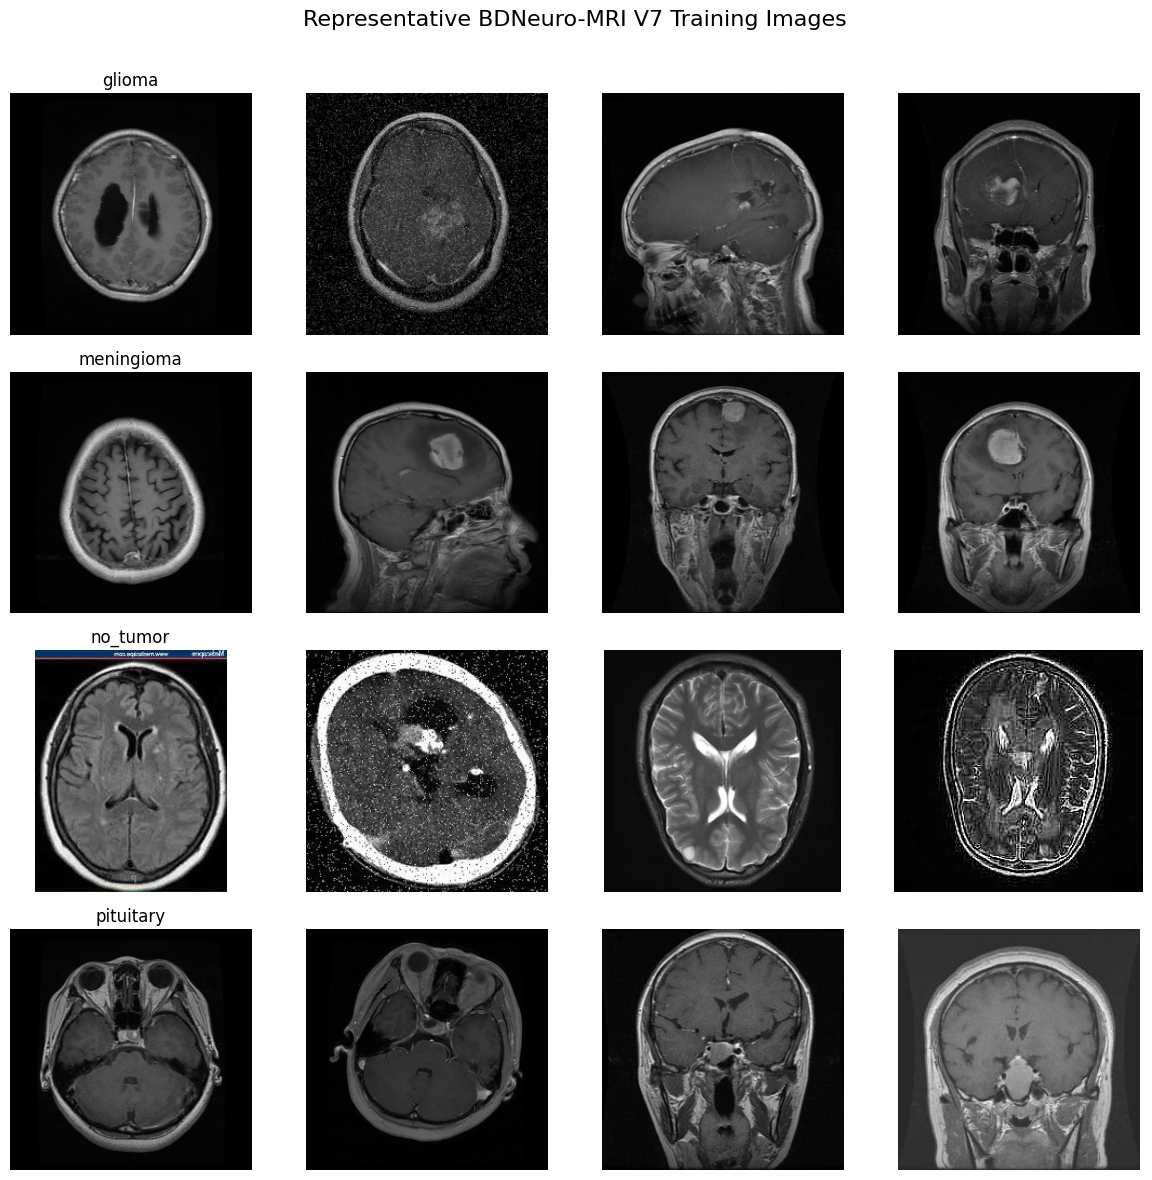


BATCH 2B AUDIT SUMMARY
Total images audited:                 5,941
Readable images:                      5,941
Unreadable images:                    0
Exact duplicate groups:               0
Redundant exact duplicate files:      0
Cross-split exact duplicate groups:   0
Cross-class exact duplicate groups:   0
Unique native dimension combinations: 349

Full image manifest:
/content/drive/MyDrive/Brain_MRI_Project/08_manifests/bdneuro_v7_image_manifest.csv

Audit summary:
/content/drive/MyDrive/Brain_MRI_Project/04_results/01_dataset_audit/bdneuro_integrity_summary.csv

Figures:
/content/drive/MyDrive/Brain_MRI_Project/05_figures/01_dataset_audit

Detailed audit results:
/content/drive/MyDrive/Brain_MRI_Project/04_results/01_dataset_audit


In [ ]:
# ============================================================
# BATCH 2B
# BDNEURO-MRI V7 INTEGRITY AUDIT AND INITIAL EDA
# ============================================================

from pathlib import Path
from collections import Counter
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

AUDIT_SEED = 42

random.seed(AUDIT_SEED)
np.random.seed(AUDIT_SEED)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

BD_SPLITS = {
    "train": BD_TRAIN_DIR,
    "validation": BD_VAL_DIR,
    "test": BD_TEST_DIR
}

EXPECTED_CLASSES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

AUDIT_FIGURES_DIR = (
    FIGURES_DIR /
    "01_dataset_audit"
)

AUDIT_RESULTS_DIR = (
    RESULTS_DIR /
    "01_dataset_audit"
)

AUDIT_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

AUDIT_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def calculate_sha256(file_path):
    """
    Calculate SHA-256 hash for one file.
    """

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:

        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            sha256.update(block)

    return sha256.hexdigest()


def mode_to_channels(mode):
    """
    Convert common Pillow image modes to channel counts.
    """

    mode_mapping = {
        "1": 1,
        "L": 1,
        "I": 1,
        "F": 1,
        "P": 1,
        "LA": 2,
        "RGB": 3,
        "YCbCr": 3,
        "HSV": 3,
        "RGBA": 4,
        "CMYK": 4
    }

    return mode_mapping.get(
        mode,
        np.nan
    )


# ------------------------------------------------------------
# COLLECT ALL BDNEURO IMAGE PATHS
# ------------------------------------------------------------

records_to_scan = []

for split_name, split_path in BD_SPLITS.items():

    for class_name in EXPECTED_CLASSES:

        class_path = (
            split_path /
            class_name
        )

        if not class_path.exists():

            raise FileNotFoundError(
                f"Missing expected directory: {class_path}"
            )

        for image_path in sorted(
            class_path.rglob("*")
        ):

            if (
                image_path.is_file()
                and
                image_path.suffix.lower()
                in IMAGE_EXTENSIONS
            ):

                records_to_scan.append(
                    {
                        "split": split_name,
                        "class": class_name,
                        "path": image_path
                    }
                )


print("=" * 70)
print("BDNEURO-MRI V7 INTEGRITY AUDIT")
print("=" * 70)

print(
    "\nImages queued for audit:",
    f"{len(records_to_scan):,}"
)

if len(records_to_scan) != 5941:

    raise RuntimeError(
        "Expected 5,941 BDNeuro images before audit, "
        f"but found {len(records_to_scan):,}."
    )


# ------------------------------------------------------------
# IMAGE-LEVEL INTEGRITY AUDIT
# ------------------------------------------------------------

audit_records = []

for record in tqdm(
    records_to_scan,
    desc="Auditing BDNeuro images"
):

    image_path = record["path"]

    audit_record = {
        "dataset": "BDNeuro V7",
        "split": record["split"],
        "class": record["class"],
        "filename": image_path.name,
        "extension": image_path.suffix.lower(),
        "absolute_path": str(image_path),
        "relative_path": str(
            image_path.relative_to(
                BDNEURO_DATASET_PATH
            )
        ),
        "file_size_bytes": image_path.stat().st_size,
        "width": np.nan,
        "height": np.nan,
        "aspect_ratio": np.nan,
        "mode": None,
        "channels": np.nan,
        "readable": False,
        "sha256": None,
        "error": None
    }

    try:

        with Image.open(image_path) as image:

            image.load()

            width, height = image.size
            mode = image.mode

            audit_record["width"] = width
            audit_record["height"] = height

            audit_record["aspect_ratio"] = (
                width / height
                if height != 0
                else np.nan
            )

            audit_record["mode"] = mode

            audit_record["channels"] = (
                mode_to_channels(mode)
            )

            audit_record["readable"] = True

        audit_record["sha256"] = (
            calculate_sha256(
                image_path
            )
        )

    except Exception as error:

        audit_record["error"] = str(
            error
        )

    audit_records.append(
        audit_record
    )


manifest_df = pd.DataFrame(
    audit_records
)


# ------------------------------------------------------------
# SAVE FULL MANIFEST
# ------------------------------------------------------------

manifest_path = (
    MANIFESTS_DIR /
    "bdneuro_v7_image_manifest.csv"
)

manifest_df.to_csv(
    manifest_path,
    index=False
)

print("\nImage manifest saved:")
print(manifest_path)


# ------------------------------------------------------------
# BASIC INTEGRITY RESULTS
# ------------------------------------------------------------

total_images = len(
    manifest_df
)

readable_images = int(
    manifest_df["readable"].sum()
)

corrupt_images = (
    total_images -
    readable_images
)

zero_byte_files = int(
    (
        manifest_df[
            "file_size_bytes"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("BASIC INTEGRITY")
print("=" * 70)

print(
    f"Total images:       {total_images:,}"
)

print(
    f"Readable images:    {readable_images:,}"
)

print(
    f"Unreadable images:  {corrupt_images:,}"
)

print(
    f"Zero-byte files:    {zero_byte_files:,}"
)


# ------------------------------------------------------------
# SAVE CORRUPT FILE REPORT
# ------------------------------------------------------------

corrupt_df = manifest_df[
    ~manifest_df["readable"]
].copy()

corrupt_path = (
    AUDIT_RESULTS_DIR /
    "bdneuro_corrupt_images.csv"
)

corrupt_df.to_csv(
    corrupt_path,
    index=False
)


# ------------------------------------------------------------
# IMAGE MODE / CHANNEL ANALYSIS
# ------------------------------------------------------------

mode_counts_df = (
    manifest_df[
        manifest_df["readable"]
    ]
    .groupby(
        [
            "mode",
            "channels"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

mode_counts_path = (
    AUDIT_RESULTS_DIR /
    "bdneuro_image_modes.csv"
)

mode_counts_df.to_csv(
    mode_counts_path,
    index=False
)

print("\n" + "=" * 70)
print("IMAGE MODES")
print("=" * 70)

print(
    mode_counts_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# FILE FORMAT ANALYSIS
# ------------------------------------------------------------

format_counts_df = (
    manifest_df
    .groupby(
        "extension"
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

format_counts_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_file_formats.csv",
    index=False
)

print("\n" + "=" * 70)
print("FILE FORMATS")
print("=" * 70)

print(
    format_counts_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# DIMENSION ANALYSIS
# ------------------------------------------------------------

dimension_counts_df = (
    manifest_df[
        manifest_df["readable"]
    ]
    .groupby(
        [
            "width",
            "height"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

dimension_counts_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_image_dimensions.csv",
    index=False
)

print("\n" + "=" * 70)
print("IMAGE DIMENSIONS")
print("=" * 70)

print(
    "Unique width-height combinations:",
    len(dimension_counts_df)
)

print(
    "\nMost common dimensions:"
)

print(
    dimension_counts_df.head(
        15
    ).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# CLASS AND SPLIT COUNTS
# ------------------------------------------------------------

class_split_counts_df = (
    manifest_df
    .groupby(
        [
            "split",
            "class"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)

split_order = [
    "train",
    "validation",
    "test"
]

class_split_counts_df[
    "split"
] = pd.Categorical(
    class_split_counts_df["split"],
    categories=split_order,
    ordered=True
)

class_split_counts_df = (
    class_split_counts_df
    .sort_values(
        [
            "split",
            "class"
        ]
    )
)

class_split_counts_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_class_split_counts.csv",
    index=False
)


class_total_counts_df = (
    manifest_df
    .groupby(
        "class"
    )
    .size()
    .reset_index(
        name="count"
    )
)

class_total_counts_df[
    "percentage"
] = (
    class_total_counts_df["count"]
    /
    total_images
    *
    100
)

class_total_counts_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_total_class_distribution.csv",
    index=False
)


# ------------------------------------------------------------
# EXACT DUPLICATE AUDIT
# ------------------------------------------------------------

valid_hash_df = manifest_df[
    manifest_df[
        "sha256"
    ].notna()
].copy()

hash_sizes = (
    valid_hash_df
    .groupby(
        "sha256"
    )
    .size()
)

duplicate_hashes = (
    hash_sizes[
        hash_sizes > 1
    ]
    .index
)

duplicate_files_df = (
    valid_hash_df[
        valid_hash_df[
            "sha256"
        ].isin(
            duplicate_hashes
        )
    ]
    .copy()
)

duplicate_files_df[
    "duplicate_group_size"
] = (
    duplicate_files_df[
        "sha256"
    ]
    .map(
        hash_sizes
    )
)


# ------------------------------------------------------------
# DUPLICATE GROUP METADATA
# ------------------------------------------------------------

duplicate_group_records = []

for group_number, (
    sha256_hash,
    group
) in enumerate(
    duplicate_files_df.groupby(
        "sha256"
    ),
    start=1
):

    splits = sorted(
        group["split"]
        .unique()
        .tolist()
    )

    classes = sorted(
        group["class"]
        .unique()
        .tolist()
    )

    duplicate_group_records.append(
        {
            "duplicate_group":
                group_number,

            "sha256":
                sha256_hash,

            "number_of_files":
                len(group),

            "number_of_splits":
                len(splits),

            "number_of_classes":
                len(classes),

            "splits":
                "|".join(splits),

            "classes":
                "|".join(classes),

            "cross_split":
                len(splits) > 1,

            "cross_class":
                len(classes) > 1,

            "redundant_files":
                len(group) - 1
        }
    )


duplicate_groups_df = pd.DataFrame(
    duplicate_group_records
)

if len(
    duplicate_groups_df
) > 0:

    duplicate_files_df = (
        duplicate_files_df
        .merge(
            duplicate_groups_df[
                [
                    "sha256",
                    "duplicate_group",
                    "cross_split",
                    "cross_class"
                ]
            ],
            on="sha256",
            how="left"
        )
    )


# ------------------------------------------------------------
# SAVE DUPLICATE REPORTS
# ------------------------------------------------------------

duplicate_groups_path = (
    AUDIT_RESULTS_DIR /
    "bdneuro_exact_duplicate_groups.csv"
)

duplicate_files_path = (
    AUDIT_RESULTS_DIR /
    "bdneuro_exact_duplicate_files.csv"
)

duplicate_groups_df.to_csv(
    duplicate_groups_path,
    index=False
)

duplicate_files_df.to_csv(
    duplicate_files_path,
    index=False
)


# ------------------------------------------------------------
# DUPLICATE SUMMARY
# ------------------------------------------------------------

if len(
    duplicate_groups_df
) == 0:

    exact_duplicate_groups = 0
    duplicate_files = 0
    redundant_files = 0
    cross_split_groups = 0
    cross_class_groups = 0

else:

    exact_duplicate_groups = len(
        duplicate_groups_df
    )

    duplicate_files = len(
        duplicate_files_df
    )

    redundant_files = int(
        duplicate_groups_df[
            "redundant_files"
        ].sum()
    )

    cross_split_groups = int(
        duplicate_groups_df[
            "cross_split"
        ].sum()
    )

    cross_class_groups = int(
        duplicate_groups_df[
            "cross_class"
        ].sum()
    )


print("\n" + "=" * 70)
print("EXACT DUPLICATE AUDIT")
print("=" * 70)

print(
    "Exact duplicate groups:",
    exact_duplicate_groups
)

print(
    "Files involved in duplicate groups:",
    duplicate_files
)

print(
    "Redundant duplicate files:",
    redundant_files
)

print(
    "Duplicate groups crossing dataset splits:",
    cross_split_groups
)

print(
    "Duplicate groups crossing class labels:",
    cross_class_groups
)


# ------------------------------------------------------------
# SPECIFIC CROSS-SPLIT LEAKAGE TABLE
# ------------------------------------------------------------

if len(
    duplicate_groups_df
) > 0:

    cross_split_hashes = (
        duplicate_groups_df.loc[
            duplicate_groups_df[
                "cross_split"
            ],
            "sha256"
        ]
    )

    cross_split_duplicate_df = (
        duplicate_files_df[
            duplicate_files_df[
                "sha256"
            ].isin(
                cross_split_hashes
            )
        ]
        .copy()
    )

else:

    cross_split_duplicate_df = pd.DataFrame(
        columns=duplicate_files_df.columns
    )


cross_split_duplicate_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_cross_split_exact_duplicates.csv",
    index=False
)


# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------

audit_summary_df = pd.DataFrame(
    [
        {
            "metric":
                "total_images",
            "value":
                total_images
        },
        {
            "metric":
                "readable_images",
            "value":
                readable_images
        },
        {
            "metric":
                "unreadable_images",
            "value":
                corrupt_images
        },
        {
            "metric":
                "zero_byte_files",
            "value":
                zero_byte_files
        },
        {
            "metric":
                "unique_dimension_combinations",
            "value":
                len(
                    dimension_counts_df
                )
        },
        {
            "metric":
                "exact_duplicate_groups",
            "value":
                exact_duplicate_groups
        },
        {
            "metric":
                "files_in_duplicate_groups",
            "value":
                duplicate_files
        },
        {
            "metric":
                "redundant_duplicate_files",
            "value":
                redundant_files
        },
        {
            "metric":
                "cross_split_duplicate_groups",
            "value":
                cross_split_groups
        },
        {
            "metric":
                "cross_class_duplicate_groups",
            "value":
                cross_class_groups
        }
    ]
)

audit_summary_path = (
    AUDIT_RESULTS_DIR /
    "bdneuro_integrity_summary.csv"
)

audit_summary_df.to_csv(
    audit_summary_path,
    index=False
)


# ============================================================
# VISUALIZATION 1
# CLASS DISTRIBUTION BY SPLIT
# ============================================================

plot_df = (
    class_split_counts_df
    .pivot(
        index="class",
        columns="split",
        values="count"
    )
    .reindex(
        EXPECTED_CLASSES
    )
)

plot_df.to_csv(
    AUDIT_RESULTS_DIR /
    "figure_class_distribution_by_split_data.csv"
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "BDNeuro-MRI V7 Class Distribution by Dataset Split"
)

ax.set_xlabel(
    "Class"
)

ax.set_ylabel(
    "Number of MRI Images"
)

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()

class_split_figure = (
    AUDIT_FIGURES_DIR /
    "bdneuro_class_distribution_by_split.png"
)

plt.savefig(
    class_split_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# VISUALIZATION 2
# TOTAL CLASS DISTRIBUTION
# ============================================================

total_plot_df = (
    class_total_counts_df
    .set_index(
        "class"
    )
    .reindex(
        EXPECTED_CLASSES
    )
)

total_plot_df.to_csv(
    AUDIT_RESULTS_DIR /
    "figure_total_class_distribution_data.csv"
)

ax = (
    total_plot_df[
        "count"
    ]
    .plot(
        kind="bar",
        figsize=(9, 6)
    )
)

ax.set_title(
    "Overall BDNeuro-MRI V7 Class Distribution"
)

ax.set_xlabel(
    "Class"
)

ax.set_ylabel(
    "Number of MRI Images"
)

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()

total_class_figure = (
    AUDIT_FIGURES_DIR /
    "bdneuro_total_class_distribution.png"
)

plt.savefig(
    total_class_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# VISUALIZATION 3
# MOST COMMON IMAGE DIMENSIONS
# ============================================================

top_dimensions_df = (
    dimension_counts_df
    .head(15)
    .copy()
)

top_dimensions_df[
    "dimension"
] = (
    top_dimensions_df[
        "width"
    ]
    .astype(int)
    .astype(str)
    +
    " x "
    +
    top_dimensions_df[
        "height"
    ]
    .astype(int)
    .astype(str)
)

top_dimensions_df.to_csv(
    AUDIT_RESULTS_DIR /
    "figure_top_image_dimensions_data.csv",
    index=False
)

ax = (
    top_dimensions_df
    .set_index(
        "dimension"
    )[
        "count"
    ]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(9, 7)
    )
)

ax.set_title(
    "Most Common Native MRI Image Dimensions"
)

ax.set_xlabel(
    "Number of Images"
)

ax.set_ylabel(
    "Width x Height"
)

plt.tight_layout()

dimension_figure = (
    AUDIT_FIGURES_DIR /
    "bdneuro_native_image_dimensions.png"
)

plt.savefig(
    dimension_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# VISUALIZATION 4
# REPRESENTATIVE TRAINING MRI MONTAGE
# ============================================================

SAMPLES_PER_CLASS = 4

training_manifest = (
    manifest_df[
        (
            manifest_df[
                "split"
            ] == "train"
        )
        &
        (
            manifest_df[
                "readable"
            ]
        )
    ]
    .copy()
)

selected_samples = []

for class_name in EXPECTED_CLASSES:

    class_df = (
        training_manifest[
            training_manifest[
                "class"
            ] == class_name
        ]
    )

    sampled = class_df.sample(
        n=SAMPLES_PER_CLASS,
        random_state=AUDIT_SEED
    )

    selected_samples.append(
        sampled
    )


montage_manifest_df = pd.concat(
    selected_samples,
    ignore_index=True
)

montage_manifest_df[
    [
        "split",
        "class",
        "filename",
        "relative_path",
        "width",
        "height",
        "mode"
    ]
].to_csv(
    AUDIT_RESULTS_DIR /
    "figure_representative_mri_montage_data.csv",
    index=False
)


fig, axes = plt.subplots(
    nrows=len(EXPECTED_CLASSES),
    ncols=SAMPLES_PER_CLASS,
    figsize=(12, 12)
)

for row_index, class_name in enumerate(
    EXPECTED_CLASSES
):

    class_samples = (
        montage_manifest_df[
            montage_manifest_df[
                "class"
            ] == class_name
        ]
        .reset_index(
            drop=True
        )
    )

    for column_index in range(
        SAMPLES_PER_CLASS
    ):

        image_path = Path(
            class_samples.loc[
                column_index,
                "absolute_path"
            ]
        )

        with Image.open(
            image_path
        ) as image:

            display_image = np.array(
                image
            )

        axes[
            row_index,
            column_index
        ].imshow(
            display_image,
            cmap=(
                "gray"
                if display_image.ndim == 2
                else None
            )
        )

        axes[
            row_index,
            column_index
        ].axis(
            "off"
        )

        if column_index == 0:

            axes[
                row_index,
                column_index
            ].set_title(
                class_name
            )


fig.suptitle(
    "Representative BDNeuro-MRI V7 Training Images",
    fontsize=16
)

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97
    ]
)

montage_figure = (
    AUDIT_FIGURES_DIR /
    "bdneuro_representative_mri_montage.png"
)

plt.savefig(
    montage_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ------------------------------------------------------------
# FINAL AUDIT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BATCH 2B AUDIT SUMMARY")
print("=" * 70)

print(
    f"Total images audited:                 {total_images:,}"
)

print(
    f"Readable images:                      {readable_images:,}"
)

print(
    f"Unreadable images:                    {corrupt_images:,}"
)

print(
    f"Exact duplicate groups:               {exact_duplicate_groups:,}"
)

print(
    f"Redundant exact duplicate files:      {redundant_files:,}"
)

print(
    f"Cross-split exact duplicate groups:   {cross_split_groups:,}"
)

print(
    f"Cross-class exact duplicate groups:   {cross_class_groups:,}"
)

print(
    f"Unique native dimension combinations: {len(dimension_counts_df):,}"
)

print(
    "\nFull image manifest:"
)

print(
    manifest_path
)

print(
    "\nAudit summary:"
)

print(
    audit_summary_path
)

print(
    "\nFigures:"
)

print(
    AUDIT_FIGURES_DIR
)

print(
    "\nDetailed audit results:"
)

print(
    AUDIT_RESULTS_DIR
)

In [ ]:
# ============================================================
# BATCH 2C
# BDNEURO CROSS-SPLIT PERCEPTUAL NEAR-DUPLICATE SCREEN
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
from scipy.fft import dctn
from tqdm.auto import tqdm


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

PHASH_SIZE = 8
PHASH_HIGHFREQ_FACTOR = 4

# Candidate threshold for a 64-bit perceptual hash.
# Smaller distance means greater visual similarity.
PHASH_THRESHOLD = 6

PAIR_CHUNK_SIZE = 256


# ------------------------------------------------------------
# LOAD THE VERIFIED MANIFEST FROM BATCH 2B
# ------------------------------------------------------------

MANIFEST_PATH = (
    MANIFESTS_DIR /
    "bdneuro_v7_image_manifest.csv"
)

manifest_df = pd.read_csv(
    MANIFEST_PATH
)

manifest_df = manifest_df[
    manifest_df["readable"] == True
].copy()

manifest_df = manifest_df.reset_index(
    drop=True
)

print("=" * 72)
print("BDNEURO PERCEPTUAL NEAR-DUPLICATE SCREEN")
print("=" * 72)

print(
    f"\nReadable images loaded: "
    f"{len(manifest_df):,}"
)

if len(manifest_df) != 5941:
    raise RuntimeError(
        "Expected 5,941 readable BDNeuro images."
    )


# ------------------------------------------------------------
# PERCEPTUAL HASH FUNCTION
# ------------------------------------------------------------

def calculate_phash64(image_path):
    """
    Compute a 64-bit perceptual hash using low-frequency DCT
    coefficients.

    Returns:
        packed_hash: 8 uint8 values representing 64 bits
        hash_hex: hexadecimal representation
    """

    resize_dimension = (
        PHASH_SIZE *
        PHASH_HIGHFREQ_FACTOR
    )

    with Image.open(image_path) as image:

        image = image.convert("L")

        image = image.resize(
            (
                resize_dimension,
                resize_dimension
            ),
            Image.Resampling.LANCZOS
        )

        image_array = np.asarray(
            image,
            dtype=np.float32
        )

    dct_result = dctn(
        image_array,
        type=2,
        norm="ortho"
    )

    low_frequency = dct_result[
        :PHASH_SIZE,
        :PHASH_SIZE
    ]

    flattened = low_frequency.flatten()

    # Exclude the DC coefficient when calculating median.
    median_value = np.median(
        flattened[1:]
    )

    hash_bits = (
        flattened >
        median_value
    ).astype(
        np.uint8
    )

    packed_hash = np.packbits(
        hash_bits
    )

    hash_hex = "".join(
        f"{value:02x}"
        for value in packed_hash
    )

    return (
        packed_hash,
        hash_hex
    )


# ------------------------------------------------------------
# COMPUTE PHASH FOR ALL 5,941 IMAGES
# ------------------------------------------------------------

packed_hashes = []
hash_hex_values = []

for image_path in tqdm(
    manifest_df["absolute_path"],
    desc="Computing perceptual hashes"
):

    packed_hash, hash_hex = (
        calculate_phash64(
            image_path
        )
    )

    packed_hashes.append(
        packed_hash
    )

    hash_hex_values.append(
        hash_hex
    )


phash_matrix = np.vstack(
    packed_hashes
).astype(
    np.uint8
)

manifest_df["phash64"] = (
    hash_hex_values
)


# ------------------------------------------------------------
# SAVE UPDATED MANIFEST WITH PHASH
# ------------------------------------------------------------

PHASH_MANIFEST_PATH = (
    MANIFESTS_DIR /
    "bdneuro_v7_manifest_with_phash.csv"
)

manifest_df.to_csv(
    PHASH_MANIFEST_PATH,
    index=False
)

print(
    "\nPerceptual hashes saved to:"
)

print(
    PHASH_MANIFEST_PATH
)


# ------------------------------------------------------------
# POPCOUNT LOOKUP TABLE
# ------------------------------------------------------------

POPCOUNT = np.array(
    [
        bin(value).count("1")
        for value in range(256)
    ],
    dtype=np.uint8
)


# ------------------------------------------------------------
# CROSS-SPLIT COMPARISON FUNCTION
# ------------------------------------------------------------

def compare_split_pair(
    dataframe,
    hash_matrix,
    split_a,
    split_b,
    threshold=6,
    chunk_size=256
):
    """
    Compare every image in split_a with every image in split_b
    using 64-bit perceptual Hamming distance.
    """

    indices_a = np.where(
        dataframe[
            "split"
        ].to_numpy() == split_a
    )[0]

    indices_b = np.where(
        dataframe[
            "split"
        ].to_numpy() == split_b
    )[0]

    hashes_a = hash_matrix[
        indices_a
    ]

    hashes_b = hash_matrix[
        indices_b
    ]

    total_pairs = (
        len(indices_a) *
        len(indices_b)
    )

    print(
        f"\nComparing {split_a} vs {split_b}"
    )

    print(
        f"Images: "
        f"{len(indices_a):,} x "
        f"{len(indices_b):,}"
    )

    print(
        f"Total pairs: "
        f"{total_pairs:,}"
    )

    candidate_records = []

    for start in tqdm(
        range(
            0,
            len(indices_a),
            chunk_size
        ),
        desc=f"{split_a} vs {split_b}"
    ):

        end = min(
            start + chunk_size,
            len(indices_a)
        )

        current_hashes = hashes_a[
            start:end
        ]

        # Shape:
        # current_chunk x split_b x 8 bytes
        xor_values = np.bitwise_xor(
            current_hashes[
                :,
                None,
                :
            ],
            hashes_b[
                None,
                :,
                :
            ]
        )

        # Convert the XOR bytes to bit-level Hamming distance.
        distances = POPCOUNT[
            xor_values
        ].sum(
            axis=2
        )

        candidate_rows, candidate_cols = (
            np.where(
                distances <= threshold
            )
        )

        for local_row, local_col in zip(
            candidate_rows,
            candidate_cols
        ):

            global_a = indices_a[
                start + local_row
            ]

            global_b = indices_b[
                local_col
            ]

            row_a = dataframe.iloc[
                global_a
            ]

            row_b = dataframe.iloc[
                global_b
            ]

            candidate_records.append(
                {
                    "split_a":
                        split_a,

                    "class_a":
                        row_a["class"],

                    "filename_a":
                        row_a["filename"],

                    "relative_path_a":
                        row_a["relative_path"],

                    "absolute_path_a":
                        row_a["absolute_path"],

                    "phash_a":
                        row_a["phash64"],

                    "split_b":
                        split_b,

                    "class_b":
                        row_b["class"],

                    "filename_b":
                        row_b["filename"],

                    "relative_path_b":
                        row_b["relative_path"],

                    "absolute_path_b":
                        row_b["absolute_path"],

                    "phash_b":
                        row_b["phash64"],

                    "hamming_distance":
                        int(
                            distances[
                                local_row,
                                local_col
                            ]
                        ),

                    "same_class":
                        (
                            row_a["class"]
                            ==
                            row_b["class"]
                        )
                }
            )

    return (
        pd.DataFrame(
            candidate_records
        ),
        total_pairs
    )


# ------------------------------------------------------------
# RUN ALL THREE CROSS-SPLIT COMPARISONS
# ------------------------------------------------------------

comparison_pairs = [
    (
        "train",
        "validation"
    ),
    (
        "train",
        "test"
    ),
    (
        "validation",
        "test"
    )
]

all_candidate_frames = []

comparison_summary = []

for split_a, split_b in comparison_pairs:

    candidates, total_pairs = (
        compare_split_pair(
            dataframe=manifest_df,
            hash_matrix=phash_matrix,
            split_a=split_a,
            split_b=split_b,
            threshold=PHASH_THRESHOLD,
            chunk_size=PAIR_CHUNK_SIZE
        )
    )

    comparison_summary.append(
        {
            "comparison":
                f"{split_a}_vs_{split_b}",

            "total_pairs":
                total_pairs,

            "candidates_distance_0_to_6":
                len(candidates)
        }
    )

    if len(candidates) > 0:

        all_candidate_frames.append(
            candidates
        )


# ------------------------------------------------------------
# COMBINE CANDIDATES
# ------------------------------------------------------------

if all_candidate_frames:

    candidate_df = pd.concat(
        all_candidate_frames,
        ignore_index=True
    )

    candidate_df = (
        candidate_df
        .sort_values(
            [
                "hamming_distance",
                "split_a",
                "split_b"
            ]
        )
        .reset_index(
            drop=True
        )
    )

else:

    candidate_df = pd.DataFrame(
        columns=[
            "split_a",
            "class_a",
            "filename_a",
            "relative_path_a",
            "absolute_path_a",
            "phash_a",
            "split_b",
            "class_b",
            "filename_b",
            "relative_path_b",
            "absolute_path_b",
            "phash_b",
            "hamming_distance",
            "same_class"
        ]
    )


# ------------------------------------------------------------
# SAVE ALL CANDIDATES
# ------------------------------------------------------------

CANDIDATE_PATH = (
    AUDIT_RESULTS_DIR /
    "bdneuro_cross_split_phash_candidates.csv"
)

candidate_df.to_csv(
    CANDIDATE_PATH,
    index=False
)


# ------------------------------------------------------------
# DISTANCE DISTRIBUTION FOR FLAGGED CANDIDATES
# ------------------------------------------------------------

if len(candidate_df) > 0:

    distance_counts_df = (
        candidate_df
        .groupby(
            "hamming_distance"
        )
        .size()
        .reset_index(
            name="candidate_pairs"
        )
        .sort_values(
            "hamming_distance"
        )
    )

else:

    distance_counts_df = pd.DataFrame(
        {
            "hamming_distance": [],
            "candidate_pairs": []
        }
    )


DISTANCE_COUNTS_PATH = (
    AUDIT_RESULTS_DIR /
    "bdneuro_phash_candidate_distance_counts.csv"
)

distance_counts_df.to_csv(
    DISTANCE_COUNTS_PATH,
    index=False
)


# ------------------------------------------------------------
# THRESHOLD SUMMARY
# ------------------------------------------------------------

threshold_summary = []

for threshold_value in [
    0,
    1,
    2,
    3,
    4,
    5,
    6
]:

    if len(candidate_df) > 0:

        count = int(
            (
                candidate_df[
                    "hamming_distance"
                ] <= threshold_value
            ).sum()
        )

    else:

        count = 0

    threshold_summary.append(
        {
            "maximum_hamming_distance":
                threshold_value,
            "candidate_pairs":
                count
        }
    )


threshold_summary_df = pd.DataFrame(
    threshold_summary
)

THRESHOLD_SUMMARY_PATH = (
    AUDIT_RESULTS_DIR /
    "bdneuro_phash_threshold_summary.csv"
)

threshold_summary_df.to_csv(
    THRESHOLD_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# SPLIT COMPARISON SUMMARY
# ------------------------------------------------------------

comparison_summary_df = pd.DataFrame(
    comparison_summary
)

COMPARISON_SUMMARY_PATH = (
    AUDIT_RESULTS_DIR /
    "bdneuro_phash_split_comparison_summary.csv"
)

comparison_summary_df.to_csv(
    COMPARISON_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# IMPORTANT SUBSETS
# ------------------------------------------------------------

if len(candidate_df) > 0:

    strongest_candidates_df = candidate_df[
        candidate_df[
            "hamming_distance"
        ] <= 4
    ].copy()

    cross_class_candidates_df = (
        candidate_df[
            candidate_df[
                "same_class"
            ] == False
        ].copy()
    )

else:

    strongest_candidates_df = (
        candidate_df.copy()
    )

    cross_class_candidates_df = (
        candidate_df.copy()
    )


strongest_candidates_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_phash_strong_candidates_distance_0_to_4.csv",
    index=False
)

cross_class_candidates_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_phash_cross_class_candidates.csv",
    index=False
)


# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

TOTAL_CROSS_SPLIT_PAIRS = int(
    comparison_summary_df[
        "total_pairs"
    ].sum()
)

print("\n" + "=" * 72)
print("BATCH 2C PERCEPTUAL HASH SUMMARY")
print("=" * 72)

print(
    f"Images screened: "
    f"{len(manifest_df):,}"
)

print(
    f"Cross-split pairs evaluated: "
    f"{TOTAL_CROSS_SPLIT_PAIRS:,}"
)

print(
    f"Candidate pairs with "
    f"Hamming distance <= {PHASH_THRESHOLD}: "
    f"{len(candidate_df):,}"
)

print(
    f"Strong candidates with "
    f"Hamming distance <= 4: "
    f"{len(strongest_candidates_df):,}"
)

print(
    f"Cross-class candidates: "
    f"{len(cross_class_candidates_df):,}"
)


print("\nCandidate counts by threshold:")

print(
    threshold_summary_df.to_string(
        index=False
    )
)


print("\nCandidate counts by split comparison:")

print(
    comparison_summary_df.to_string(
        index=False
    )
)


if len(distance_counts_df) > 0:

    print(
        "\nCandidate pairs by exact "
        "Hamming distance:"
    )

    print(
        distance_counts_df.to_string(
            index=False
        )
    )


print(
    "\nFull candidate report:"
)

print(
    CANDIDATE_PATH
)

print(
    "\nThreshold summary:"
)

print(
    THRESHOLD_SUMMARY_PATH
)

print(
    "\nSplit comparison summary:"
)

print(
    COMPARISON_SUMMARY_PATH
)

BDNEURO PERCEPTUAL NEAR-DUPLICATE SCREEN

Readable images loaded: 5,941


Computing perceptual hashes:   0%|          | 0/5941 [00:00<?, ?it/s]


Perceptual hashes saved to:
/content/drive/MyDrive/Brain_MRI_Project/08_manifests/bdneuro_v7_manifest_with_phash.csv

Comparing train vs validation
Images: 4,160 x 892
Total pairs: 3,710,720


train vs validation:   0%|          | 0/17 [00:00<?, ?it/s]


Comparing train vs test
Images: 4,160 x 889
Total pairs: 3,698,240


train vs test:   0%|          | 0/17 [00:00<?, ?it/s]


Comparing validation vs test
Images: 892 x 889
Total pairs: 792,988


validation vs test:   0%|          | 0/4 [00:00<?, ?it/s]


BATCH 2C PERCEPTUAL HASH SUMMARY
Images screened: 5,941
Cross-split pairs evaluated: 8,201,948
Candidate pairs with Hamming distance <= 6: 721
Strong candidates with Hamming distance <= 4: 26
Cross-class candidates: 88

Candidate counts by threshold:
 maximum_hamming_distance  candidate_pairs
                        0                1
                        1                1
                        2                2
                        3                2
                        4               26
                        5               26
                        6              721

Candidate counts by split comparison:
         comparison  total_pairs  candidates_distance_0_to_6
train_vs_validation      3710720                         349
      train_vs_test      3698240                         306
 validation_vs_test       792988                          66

Candidate pairs by exact Hamming distance:
 hamming_distance  candidate_pairs
                0                1
       

BDNEURO NEAR-DUPLICATE CONFIRMATION

Candidate pairs loaded: 721


Calculating SSIM:   0%|          | 0/721 [00:00<?, ?it/s]


REVIEW TIER SUMMARY
          review_tier  candidate_pairs  mean_ssim  max_ssim  min_phash_distance  max_phash_distance
    A_critical_review                2   0.726481  0.966555                   0                   2
        B_high_review               24   0.549341  0.884180                   4                   4
C_screening_candidate              695   0.540924  0.877551                   6                   6

SSIM threshold counts:
 minimum_ssim  candidate_pairs  same_class_pairs  cross_class_pairs
        0.900                1                 0                  1
        0.950                1                 0                  1
        0.970                0                 0                  0
        0.980                0                 0                  0
        0.985                0                 0                  0
        0.990                0                 0                  0
        0.995                0                 0                  0

TOP SUSPIC

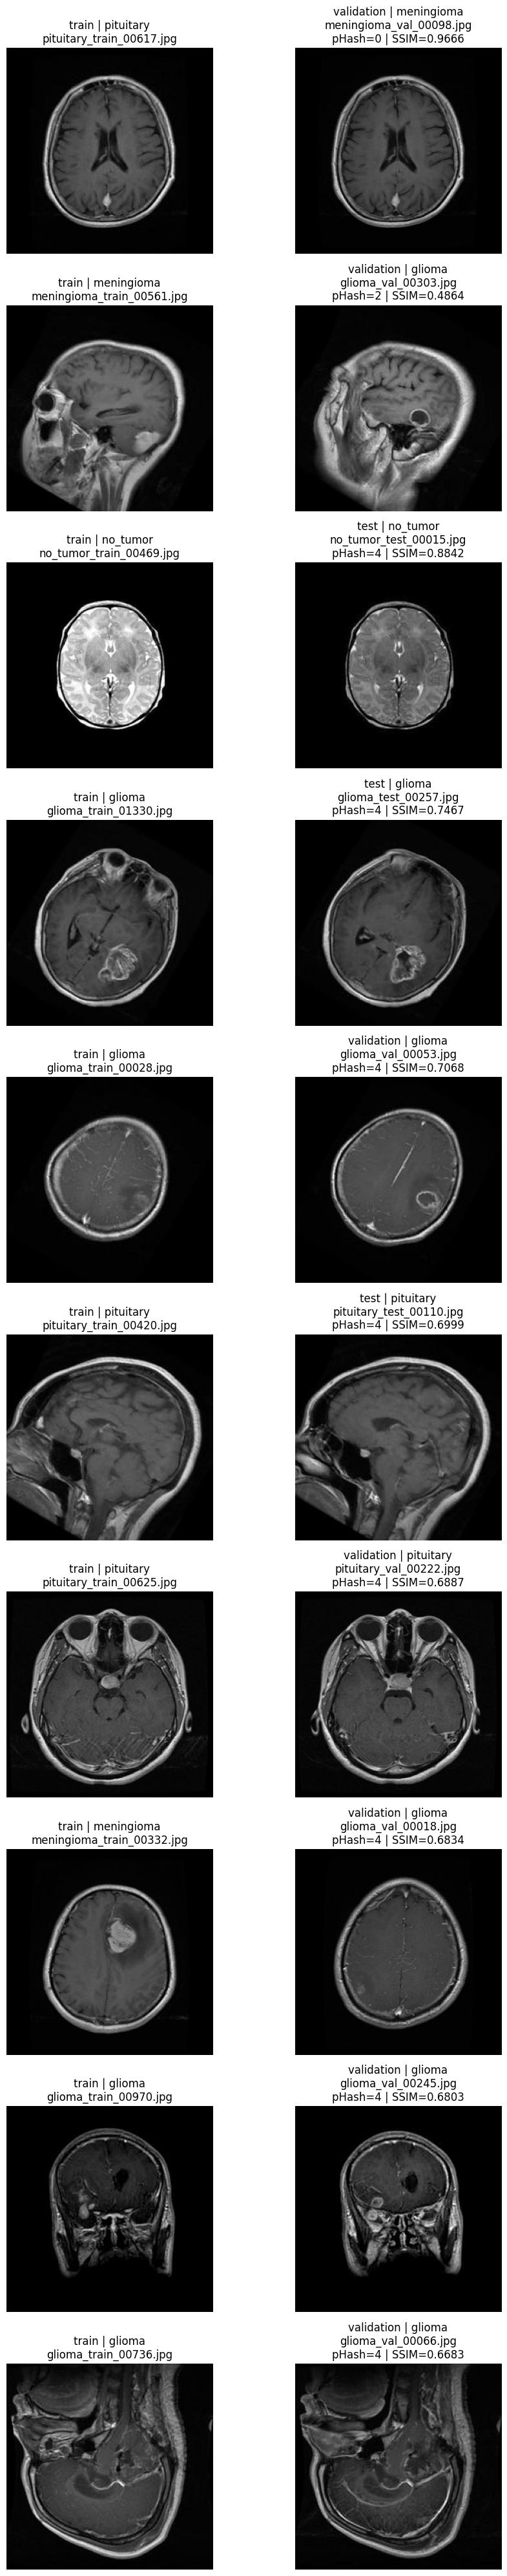

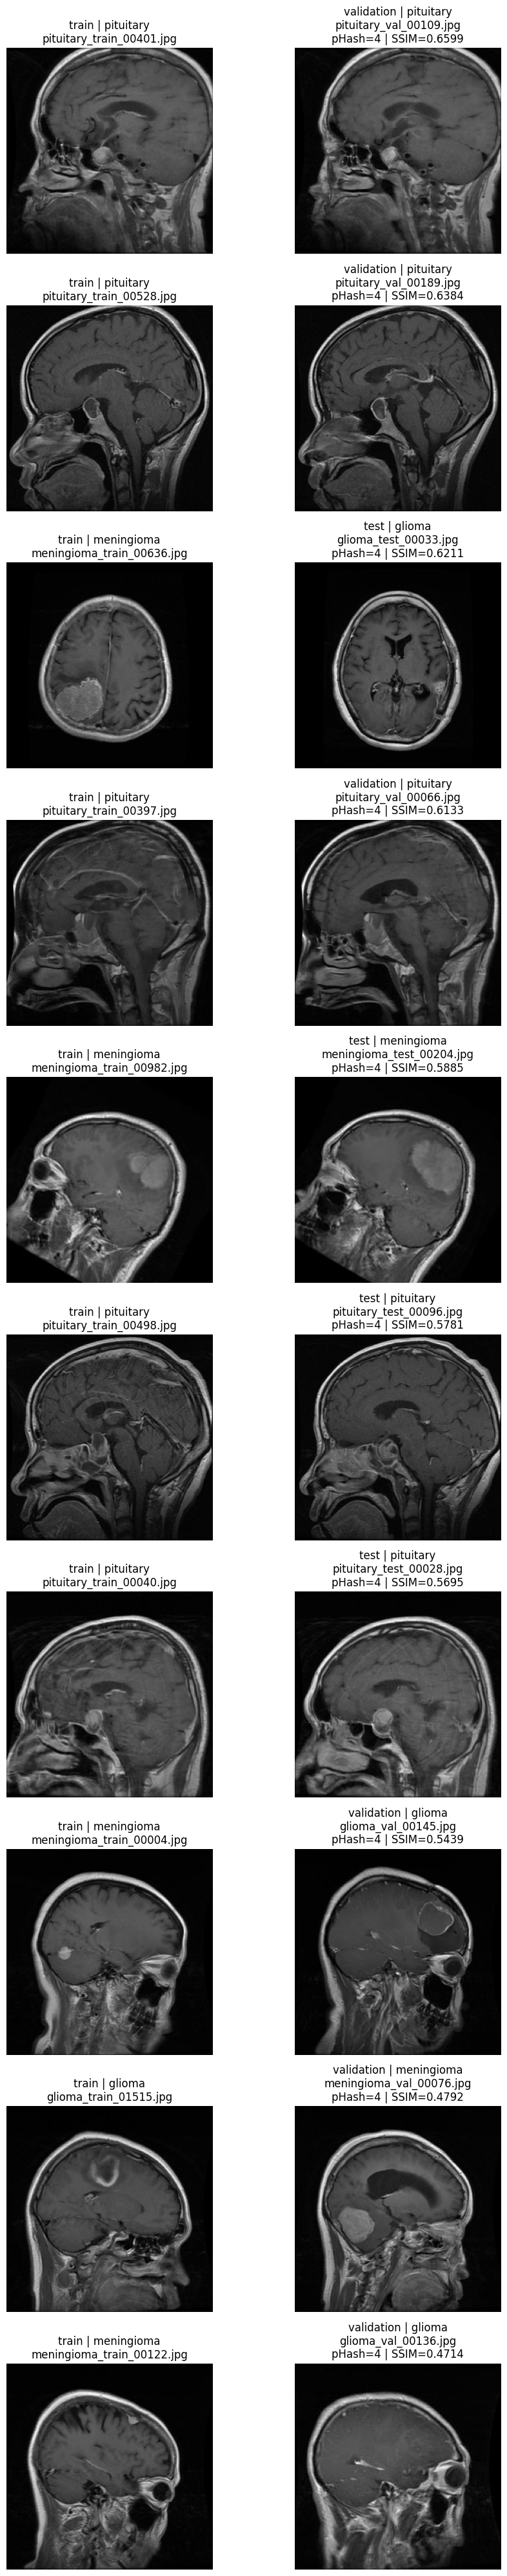

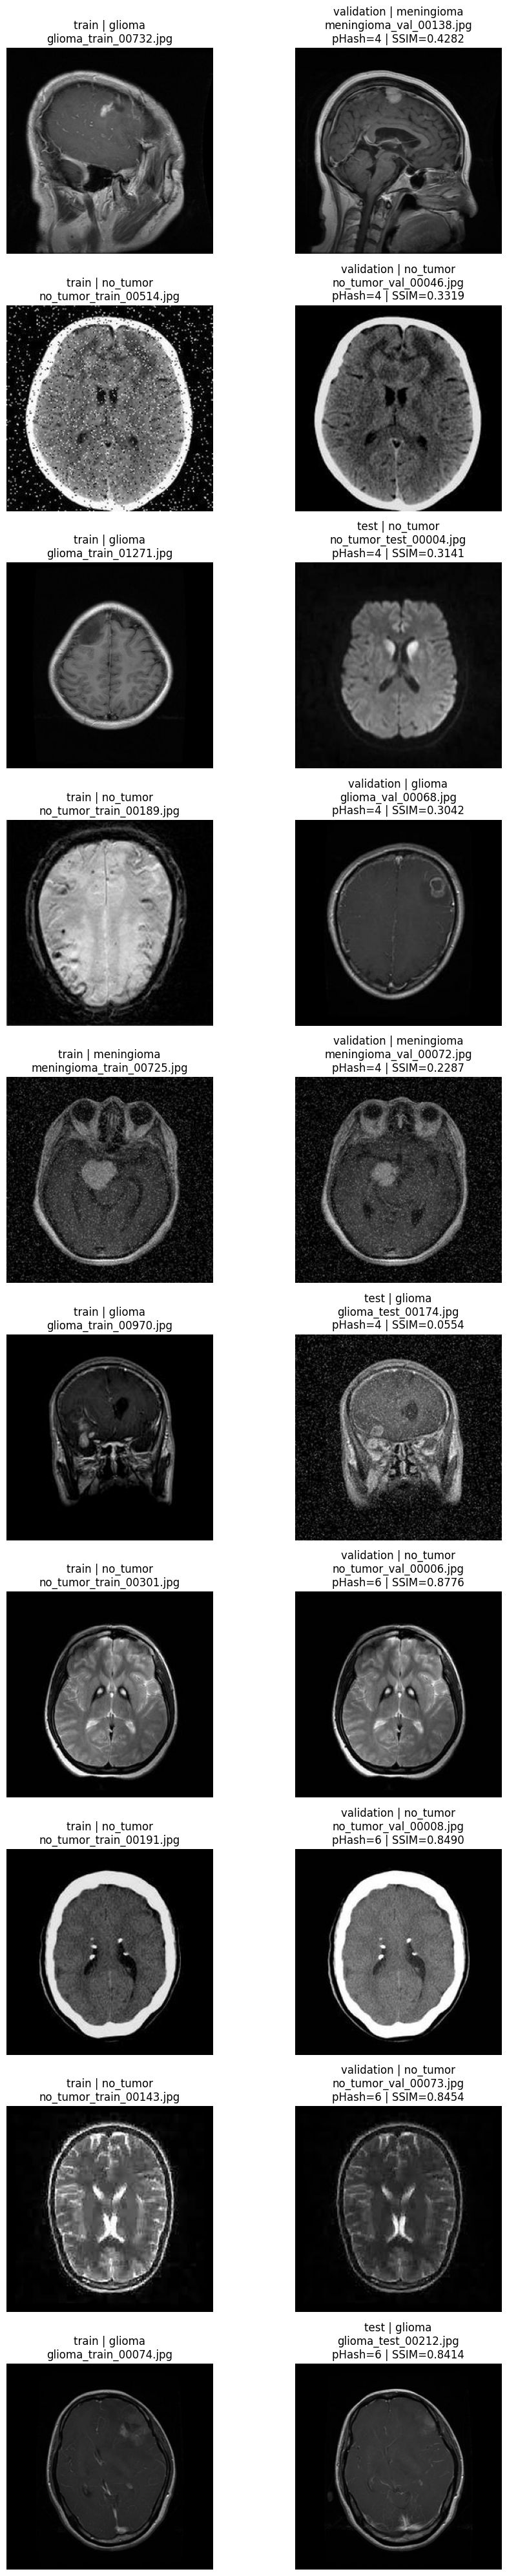


BATCH 2D SSIM REVIEW SUMMARY
Total pHash candidates evaluated: 721
Critical-review pairs: 2
High-review pairs: 24
Screening-only pairs: 695
Maximum SSIM observed: 0.966555
Pairs with SSIM >= 0.985: 0
Pairs with SSIM >= 0.990: 0

Full SSIM results:
/content/drive/MyDrive/Brain_MRI_Project/04_results/01_dataset_audit/bdneuro_cross_split_phash_ssim_results.csv

Visual review figures:
/content/drive/MyDrive/Brain_MRI_Project/05_figures/01_dataset_audit/near_duplicate_review


In [ ]:
# ============================================================
# BATCH 2D
# SSIM CONFIRMATION OF CROSS-SPLIT NEAR-DUPLICATE CANDIDATES
# ============================================================

from pathlib import Path
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from tqdm.auto import tqdm


# ------------------------------------------------------------
# ENSURE SCIKIT-IMAGE IS AVAILABLE
# ------------------------------------------------------------

try:
    from skimage.metrics import structural_similarity

except ImportError:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "scikit-image"
        ]
    )

    from skimage.metrics import structural_similarity


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

COMPARISON_SIZE = 256

CANDIDATE_PATH = (
    AUDIT_RESULTS_DIR /
    "bdneuro_cross_split_phash_candidates.csv"
)

SSIM_RESULTS_PATH = (
    AUDIT_RESULTS_DIR /
    "bdneuro_cross_split_phash_ssim_results.csv"
)

SSIM_SUMMARY_PATH = (
    AUDIT_RESULTS_DIR /
    "bdneuro_cross_split_ssim_summary.csv"
)

REVIEW_FIGURE_DIR = (
    AUDIT_FIGURES_DIR /
    "near_duplicate_review"
)

REVIEW_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# LOAD PHASH CANDIDATES
# ------------------------------------------------------------

candidate_df = pd.read_csv(
    CANDIDATE_PATH
)

print("=" * 72)
print("BDNEURO NEAR-DUPLICATE CONFIRMATION")
print("=" * 72)

print(
    f"\nCandidate pairs loaded: "
    f"{len(candidate_df):,}"
)

if len(candidate_df) != 721:

    print(
        "Warning: candidate count differs from the previous "
        "721-pair screen."
    )


# ------------------------------------------------------------
# IMAGE STANDARDIZATION FOR COMPARISON
# ------------------------------------------------------------

def load_comparison_image(
    image_path,
    target_size=256
):
    """
    Load image in grayscale and resize while preserving
    aspect ratio. Empty borders are padded rather than
    stretching the original image.
    """

    with Image.open(image_path) as image:

        image = image.convert("L")

        image = ImageOps.contain(
            image,
            (
                target_size,
                target_size
            ),
            method=Image.Resampling.LANCZOS
        )

        canvas = Image.new(
            "L",
            (
                target_size,
                target_size
            ),
            color=0
        )

        x_offset = (
            target_size -
            image.width
        ) // 2

        y_offset = (
            target_size -
            image.height
        ) // 2

        canvas.paste(
            image,
            (
                x_offset,
                y_offset
            )
        )

        array = np.asarray(
            canvas,
            dtype=np.float32
        )

    # Individual min-max normalization
    minimum = array.min()
    maximum = array.max()

    if maximum > minimum:

        array = (
            array -
            minimum
        ) / (
            maximum -
            minimum
        )

    else:

        array = np.zeros_like(
            array,
            dtype=np.float32
        )

    return array


# ------------------------------------------------------------
# ADDITIONAL SIMILARITY METRICS
# ------------------------------------------------------------

def calculate_similarity_metrics(
    image_a,
    image_b
):

    ssim_value = structural_similarity(
        image_a,
        image_b,
        data_range=1.0
    )

    mae_value = np.mean(
        np.abs(
            image_a -
            image_b
        )
    )

    mse_value = np.mean(
        (
            image_a -
            image_b
        ) ** 2
    )

    flat_a = image_a.ravel()
    flat_b = image_b.ravel()

    if (
        np.std(flat_a) > 0
        and
        np.std(flat_b) > 0
    ):

        correlation = np.corrcoef(
            flat_a,
            flat_b
        )[0, 1]

    else:

        correlation = np.nan

    return (
        float(ssim_value),
        float(mae_value),
        float(mse_value),
        float(correlation)
    )


# ------------------------------------------------------------
# CALCULATE SSIM FOR ALL 721 CANDIDATES
# ------------------------------------------------------------

ssim_values = []
mae_values = []
mse_values = []
correlation_values = []

for row in tqdm(
    candidate_df.itertuples(
        index=False
    ),
    total=len(candidate_df),
    desc="Calculating SSIM"
):

    image_a = load_comparison_image(
        row.absolute_path_a,
        COMPARISON_SIZE
    )

    image_b = load_comparison_image(
        row.absolute_path_b,
        COMPARISON_SIZE
    )

    (
        ssim_value,
        mae_value,
        mse_value,
        correlation
    ) = calculate_similarity_metrics(
        image_a,
        image_b
    )

    ssim_values.append(
        ssim_value
    )

    mae_values.append(
        mae_value
    )

    mse_values.append(
        mse_value
    )

    correlation_values.append(
        correlation
    )


candidate_df[
    "ssim"
] = ssim_values

candidate_df[
    "normalized_mae"
] = mae_values

candidate_df[
    "normalized_mse"
] = mse_values

candidate_df[
    "pixel_correlation"
] = correlation_values


# ------------------------------------------------------------
# ASSIGN REVIEW PRIORITY
#
# These are REVIEW categories.
# They are NOT automatic duplicate classifications.
# ------------------------------------------------------------

def assign_review_tier(row):

    if (
        row["hamming_distance"] <= 2
        or
        row["ssim"] >= 0.985
    ):

        return "A_critical_review"

    elif (
        row["hamming_distance"] <= 4
        or
        row["ssim"] >= 0.970
    ):

        return "B_high_review"

    else:

        return "C_screening_candidate"


candidate_df[
    "review_tier"
] = candidate_df.apply(
    assign_review_tier,
    axis=1
)


# ------------------------------------------------------------
# SORT BY SUSPICION
# ------------------------------------------------------------

candidate_df = candidate_df.sort_values(
    [
        "review_tier",
        "hamming_distance",
        "ssim"
    ],
    ascending=[
        True,
        True,
        False
    ]
).reset_index(
    drop=True
)


# ------------------------------------------------------------
# SAVE FULL RESULTS
# ------------------------------------------------------------

candidate_df.to_csv(
    SSIM_RESULTS_PATH,
    index=False
)


# ------------------------------------------------------------
# SUMMARY BY REVIEW TIER
# ------------------------------------------------------------

tier_summary_df = (
    candidate_df
    .groupby(
        "review_tier"
    )
    .agg(
        candidate_pairs=(
            "review_tier",
            "size"
        ),
        mean_ssim=(
            "ssim",
            "mean"
        ),
        max_ssim=(
            "ssim",
            "max"
        ),
        min_phash_distance=(
            "hamming_distance",
            "min"
        ),
        max_phash_distance=(
            "hamming_distance",
            "max"
        )
    )
    .reset_index()
)

tier_summary_df.to_csv(
    SSIM_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# SSIM THRESHOLD TABLE
# ------------------------------------------------------------

ssim_thresholds = [
    0.90,
    0.95,
    0.97,
    0.98,
    0.985,
    0.99,
    0.995
]

ssim_threshold_records = []

for threshold in ssim_thresholds:

    subset = candidate_df[
        candidate_df[
            "ssim"
        ] >= threshold
    ]

    ssim_threshold_records.append(
        {
            "minimum_ssim":
                threshold,

            "candidate_pairs":
                len(subset),

            "same_class_pairs":
                int(
                    subset[
                        "same_class"
                    ].sum()
                )
                if len(subset)
                else 0,

            "cross_class_pairs":
                int(
                    (
                        subset[
                            "same_class"
                        ] == False
                    ).sum()
                )
                if len(subset)
                else 0
        }
    )


ssim_threshold_df = pd.DataFrame(
    ssim_threshold_records
)

ssim_threshold_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_ssim_threshold_counts.csv",
    index=False
)


# ------------------------------------------------------------
# PRINT THE STRONGEST PAIRS
# ------------------------------------------------------------

strongest_df = candidate_df[
    candidate_df[
        "review_tier"
    ].isin(
        [
            "A_critical_review",
            "B_high_review"
        ]
    )
].copy()


print("\n" + "=" * 72)
print("REVIEW TIER SUMMARY")
print("=" * 72)

print(
    tier_summary_df.to_string(
        index=False
    )
)


print("\nSSIM threshold counts:")

print(
    ssim_threshold_df.to_string(
        index=False
    )
)


print("\n" + "=" * 72)
print("TOP SUSPICIOUS PAIRS")
print("=" * 72)

display_columns = [
    "split_a",
    "class_a",
    "filename_a",
    "split_b",
    "class_b",
    "filename_b",
    "hamming_distance",
    "ssim",
    "pixel_correlation",
    "review_tier"
]

print(
    candidate_df[
        display_columns
    ]
    .head(30)
    .to_string(
        index=False
    )
)


# ============================================================
# VISUAL REVIEW MONTAGES
# ============================================================

# Select most suspicious pairs.
review_df = (
    candidate_df
    .sort_values(
        [
            "hamming_distance",
            "ssim"
        ],
        ascending=[
            True,
            False
        ]
    )
    .head(30)
    .reset_index(
        drop=True
    )
)


review_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_top30_near_duplicate_visual_review.csv",
    index=False
)


PAIRS_PER_FIGURE = 10

number_of_figures = int(
    np.ceil(
        len(review_df)
        /
        PAIRS_PER_FIGURE
    )
)


for figure_index in range(
    number_of_figures
):

    start = (
        figure_index *
        PAIRS_PER_FIGURE
    )

    end = min(
        start +
        PAIRS_PER_FIGURE,
        len(review_df)
    )

    current_df = (
        review_df
        .iloc[
            start:end
        ]
        .reset_index(
            drop=True
        )
    )

    fig, axes = plt.subplots(
        nrows=len(current_df),
        ncols=2,
        figsize=(
            10,
            4 * len(current_df)
        )
    )

    if len(current_df) == 1:

        axes = np.array(
            [
                axes
            ]
        )

    for row_index, row in (
        current_df.iterrows()
    ):

        image_a = load_comparison_image(
            row[
                "absolute_path_a"
            ],
            COMPARISON_SIZE
        )

        image_b = load_comparison_image(
            row[
                "absolute_path_b"
            ],
            COMPARISON_SIZE
        )

        axes[
            row_index,
            0
        ].imshow(
            image_a,
            cmap="gray"
        )

        axes[
            row_index,
            1
        ].imshow(
            image_b,
            cmap="gray"
        )

        axes[
            row_index,
            0
        ].axis(
            "off"
        )

        axes[
            row_index,
            1
        ].axis(
            "off"
        )

        axes[
            row_index,
            0
        ].set_title(
            f"{row['split_a']} | "
            f"{row['class_a']}\n"
            f"{row['filename_a']}"
        )

        axes[
            row_index,
            1
        ].set_title(
            f"{row['split_b']} | "
            f"{row['class_b']}\n"
            f"{row['filename_b']}\n"
            f"pHash={row['hamming_distance']} | "
            f"SSIM={row['ssim']:.4f}"
        )

    plt.tight_layout()

    figure_path = (
        REVIEW_FIGURE_DIR /
        (
            f"near_duplicate_review_"
            f"{figure_index + 1}.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

critical_count = int(
    (
        candidate_df[
            "review_tier"
        ] == "A_critical_review"
    ).sum()
)

high_count = int(
    (
        candidate_df[
            "review_tier"
        ] == "B_high_review"
    ).sum()
)

screen_count = int(
    (
        candidate_df[
            "review_tier"
        ] == "C_screening_candidate"
    ).sum()
)


print("\n" + "=" * 72)
print("BATCH 2D SSIM REVIEW SUMMARY")
print("=" * 72)

print(
    f"Total pHash candidates evaluated: "
    f"{len(candidate_df):,}"
)

print(
    f"Critical-review pairs: "
    f"{critical_count:,}"
)

print(
    f"High-review pairs: "
    f"{high_count:,}"
)

print(
    f"Screening-only pairs: "
    f"{screen_count:,}"
)

print(
    f"Maximum SSIM observed: "
    f"{candidate_df['ssim'].max():.6f}"
)

print(
    f"Pairs with SSIM >= 0.985: "
    f"{(candidate_df['ssim'] >= 0.985).sum():,}"
)

print(
    f"Pairs with SSIM >= 0.990: "
    f"{(candidate_df['ssim'] >= 0.990).sum():,}"
)

print(
    "\nFull SSIM results:"
)

print(
    SSIM_RESULTS_PATH
)

print(
    "\nVisual review figures:"
)

print(
    REVIEW_FIGURE_DIR
)

IMAGE GEOMETRY SUMMARY
              metric       value
    number_of_images 5941.000000
   unique_dimensions  349.000000
       minimum_width  150.000000
       maximum_width 1375.000000
        median_width  512.000000
      minimum_height  167.000000
      maximum_height 1446.000000
       median_height  512.000000
minimum_aspect_ratio    0.644809
maximum_aspect_ratio    1.785714
 median_aspect_ratio    1.000000
       square_images 5443.000000
   square_percentage   91.617573

Orientation distribution:
orientation  count  percentage
  landscape    154    2.592156
   portrait    344    5.790271
     square   5443   91.617573


Analyzing image intensity:   0%|          | 0/5941 [00:00<?, ?it/s]


INTENSITY SUMMARY
                 count      mean       std       min       25%       50%       75%       max
mean_intensity  5941.0  0.174277  0.070544  0.022794  0.128344  0.164335  0.203237  0.632152
std_intensity   5941.0  0.171502  0.043421  0.047386  0.147658  0.165478  0.185154  0.401207
p01             5941.0  0.006230  0.027840  0.000000  0.000000  0.000000  0.000000  0.270588
p50             5941.0  0.121940  0.106183  0.000000  0.019608  0.109804  0.196078  0.858824
p99             5941.0  0.686548  0.136323  0.203922  0.603922  0.674510  0.749020  1.000000


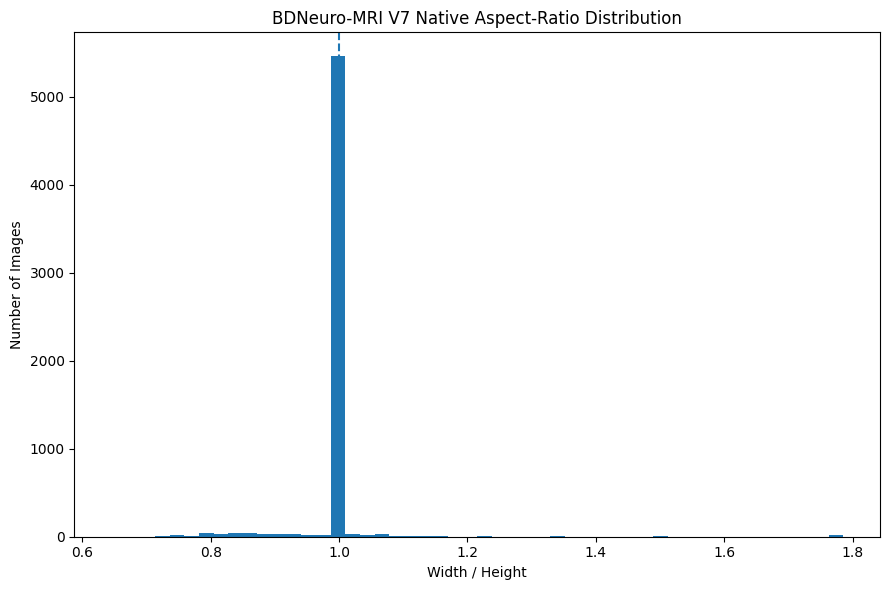

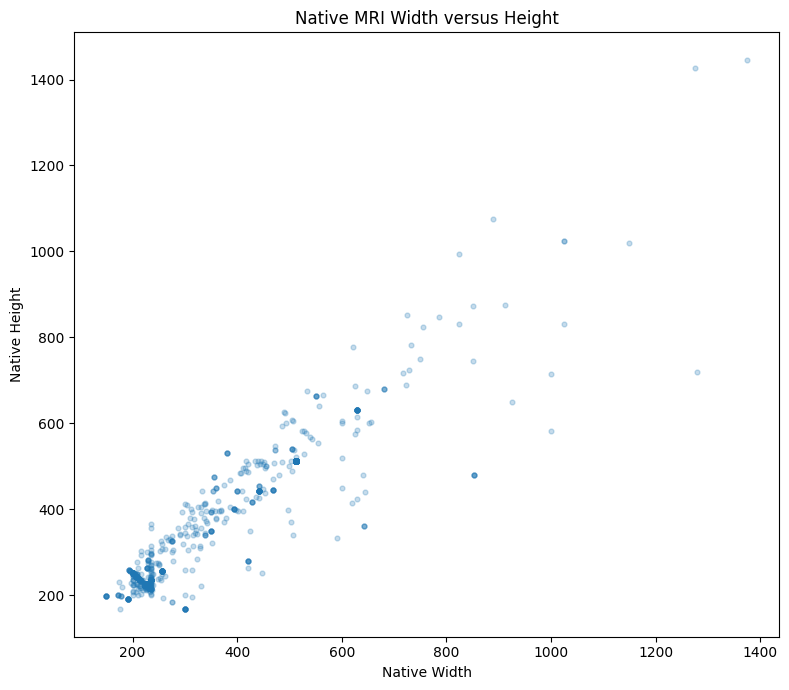

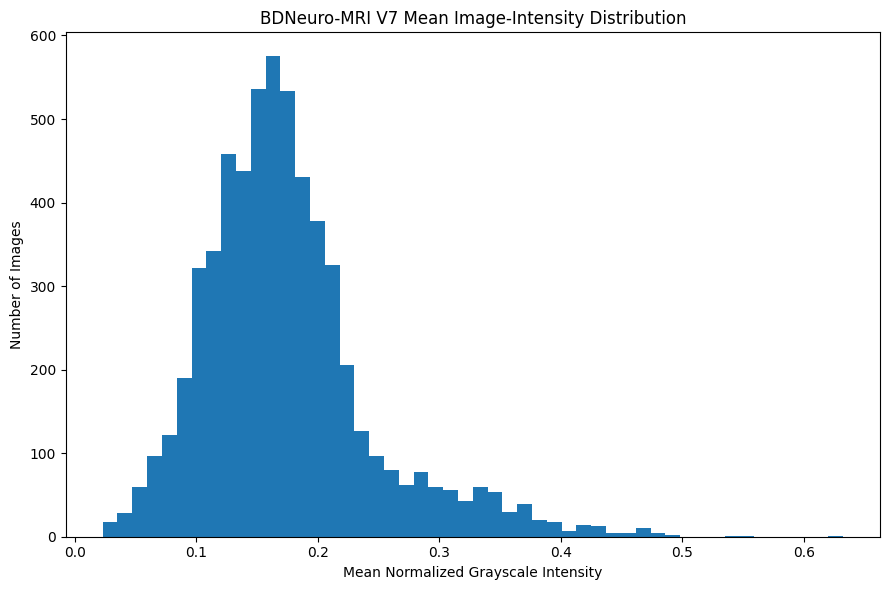

/tmp/ipykernel_6712/558558910.py:615: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


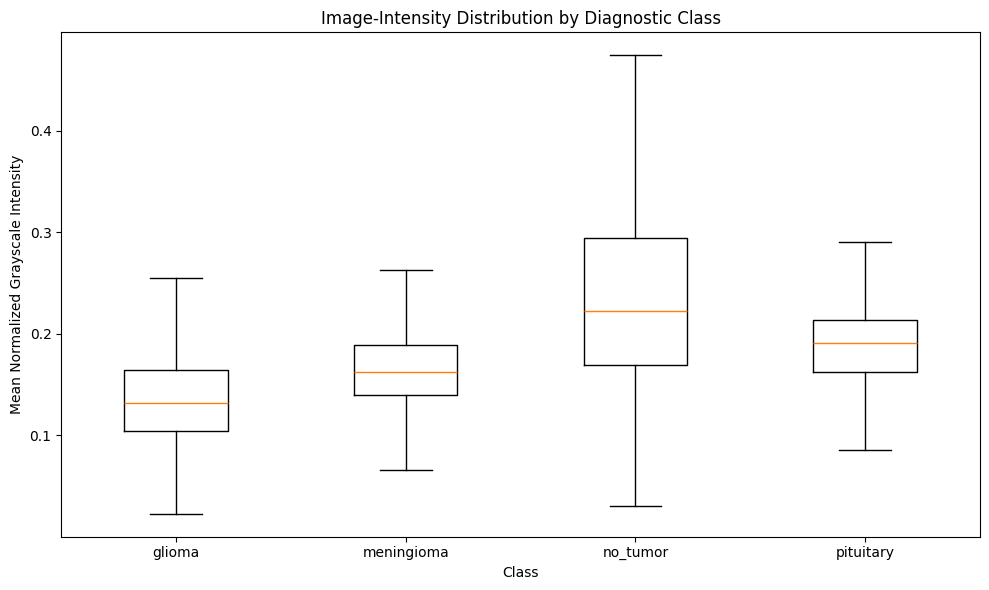


BATCH 2E SUMMARY
Images analyzed: 5,941
Unique native dimensions: 349
Square images: 5,443 (91.62%)
Median aspect ratio: 1.0000
Minimum aspect ratio: 0.6448
Maximum aspect ratio: 1.7857
Images with aspect ratio <0.80 or >1.25: 102

Geometry summary:
/content/drive/MyDrive/Brain_MRI_Project/04_results/01_dataset_audit/bdneuro_geometry_summary.csv

Intensity statistics:
/content/drive/MyDrive/Brain_MRI_Project/04_results/01_dataset_audit/bdneuro_image_intensity_statistics.csv

EDA figures:
/content/drive/MyDrive/Brain_MRI_Project/05_figures/01_dataset_audit


In [ ]:
# ============================================================
# BATCH 2E
# BDNEURO IMAGE GEOMETRY AND INTENSITY EDA
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm


# ------------------------------------------------------------
# LOAD VERIFIED MANIFEST
# ------------------------------------------------------------

MANIFEST_PATH = (
    MANIFESTS_DIR /
    "bdneuro_v7_manifest_with_phash.csv"
)

eda_df = pd.read_csv(
    MANIFEST_PATH
)

eda_df = eda_df[
    eda_df["readable"] == True
].copy()

eda_df = eda_df.reset_index(
    drop=True
)

if len(eda_df) != 5941:
    raise RuntimeError(
        f"Expected 5,941 images, found {len(eda_df)}."
    )


# ------------------------------------------------------------
# GEOMETRY VARIABLES
# ------------------------------------------------------------

eda_df["aspect_ratio"] = (
    eda_df["width"] /
    eda_df["height"]
)

eda_df["pixel_area"] = (
    eda_df["width"] *
    eda_df["height"]
)

eda_df["is_square"] = (
    eda_df["width"] ==
    eda_df["height"]
)

eda_df["orientation"] = np.select(
    [
        eda_df["width"] > eda_df["height"],
        eda_df["width"] < eda_df["height"]
    ],
    [
        "landscape",
        "portrait"
    ],
    default="square"
)


# ------------------------------------------------------------
# GEOMETRY SUMMARY
# ------------------------------------------------------------

geometry_summary = pd.DataFrame(
    {
        "metric": [
            "number_of_images",
            "unique_dimensions",
            "minimum_width",
            "maximum_width",
            "median_width",
            "minimum_height",
            "maximum_height",
            "median_height",
            "minimum_aspect_ratio",
            "maximum_aspect_ratio",
            "median_aspect_ratio",
            "square_images",
            "square_percentage"
        ],
        "value": [
            len(eda_df),
            eda_df[
                ["width", "height"]
            ].drop_duplicates().shape[0],
            eda_df["width"].min(),
            eda_df["width"].max(),
            eda_df["width"].median(),
            eda_df["height"].min(),
            eda_df["height"].max(),
            eda_df["height"].median(),
            eda_df["aspect_ratio"].min(),
            eda_df["aspect_ratio"].max(),
            eda_df["aspect_ratio"].median(),
            eda_df["is_square"].sum(),
            eda_df["is_square"].mean() * 100
        ]
    }
)

geometry_summary.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_geometry_summary.csv",
    index=False
)


print("=" * 72)
print("IMAGE GEOMETRY SUMMARY")
print("=" * 72)

print(
    geometry_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# ORIENTATION COUNTS
# ------------------------------------------------------------

orientation_df = (
    eda_df
    .groupby(
        "orientation"
    )
    .size()
    .reset_index(
        name="count"
    )
)

orientation_df[
    "percentage"
] = (
    orientation_df["count"]
    /
    len(eda_df)
    *
    100
)

orientation_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_orientation_distribution.csv",
    index=False
)

print("\nOrientation distribution:")

print(
    orientation_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# ASPECT-RATIO CATEGORIES
# ------------------------------------------------------------

def aspect_category(value):

    if value < 0.80:
        return "<0.80"

    elif value < 0.90:
        return "0.80-0.89"

    elif value < 0.95:
        return "0.90-0.94"

    elif value <= 1.05:
        return "0.95-1.05"

    elif value <= 1.10:
        return "1.06-1.10"

    elif value <= 1.25:
        return "1.11-1.25"

    else:
        return ">1.25"


eda_df[
    "aspect_ratio_category"
] = eda_df[
    "aspect_ratio"
].apply(
    aspect_category
)

aspect_category_df = (
    eda_df
    .groupby(
        "aspect_ratio_category"
    )
    .size()
    .reset_index(
        name="count"
    )
)

aspect_order = [
    "<0.80",
    "0.80-0.89",
    "0.90-0.94",
    "0.95-1.05",
    "1.06-1.10",
    "1.11-1.25",
    ">1.25"
]

aspect_category_df[
    "aspect_ratio_category"
] = pd.Categorical(
    aspect_category_df[
        "aspect_ratio_category"
    ],
    categories=aspect_order,
    ordered=True
)

aspect_category_df = (
    aspect_category_df
    .sort_values(
        "aspect_ratio_category"
    )
)

aspect_category_df[
    "percentage"
] = (
    aspect_category_df["count"]
    /
    len(eda_df)
    *
    100
)

aspect_category_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_aspect_ratio_categories.csv",
    index=False
)


# ------------------------------------------------------------
# IMAGE INTENSITY STATISTICS
# ------------------------------------------------------------

intensity_records = []

for row in tqdm(
    eda_df.itertuples(
        index=False
    ),
    total=len(eda_df),
    desc="Analyzing image intensity"
):

    with Image.open(
        row.absolute_path
    ) as image:

        image = image.convert("L")

        array = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0

    intensity_records.append(
        {
            "relative_path":
                row.relative_path,

            "split":
                row.split,

            "class":
                row._2
                if hasattr(row, "_2")
                else getattr(
                    row,
                    "class"
                ),

            "mean_intensity":
                float(
                    array.mean()
                ),

            "std_intensity":
                float(
                    array.std()
                ),

            "minimum_intensity":
                float(
                    array.min()
                ),

            "maximum_intensity":
                float(
                    array.max()
                ),

            "p01":
                float(
                    np.percentile(
                        array,
                        1
                    )
                ),

            "p50":
                float(
                    np.percentile(
                        array,
                        50
                    )
                ),

            "p99":
                float(
                    np.percentile(
                        array,
                        99
                    )
                )
        }
    )


intensity_df = pd.DataFrame(
    intensity_records
)

intensity_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_image_intensity_statistics.csv",
    index=False
)


# ------------------------------------------------------------
# OVERALL INTENSITY SUMMARY
# ------------------------------------------------------------

intensity_summary_df = (
    intensity_df[
        [
            "mean_intensity",
            "std_intensity",
            "p01",
            "p50",
            "p99"
        ]
    ]
    .describe()
    .T
)

intensity_summary_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_intensity_summary.csv"
)


print(
    "\n" + "=" * 72
)

print(
    "INTENSITY SUMMARY"
)

print(
    "=" * 72
)

print(
    intensity_summary_df.to_string()
)


# ============================================================
# FIGURE 1
# ASPECT RATIO DISTRIBUTION
# ============================================================

aspect_plot_data = (
    eda_df[
        [
            "aspect_ratio",
            "split",
            "class"
        ]
    ]
    .copy()
)

aspect_plot_data.to_csv(
    AUDIT_RESULTS_DIR /
    "figure_aspect_ratio_distribution_data.csv",
    index=False
)

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    eda_df[
        "aspect_ratio"
    ],
    bins=50
)

plt.axvline(
    1.0,
    linestyle="--"
)

plt.xlabel(
    "Width / Height"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "BDNeuro-MRI V7 Native Aspect-Ratio Distribution"
)

plt.tight_layout()

plt.savefig(
    AUDIT_FIGURES_DIR /
    "bdneuro_aspect_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# FIGURE 2
# WIDTH VS HEIGHT
# ============================================================

dimension_scatter_data = (
    eda_df[
        [
            "width",
            "height",
            "split",
            "class"
        ]
    ]
    .copy()
)

dimension_scatter_data.to_csv(
    AUDIT_RESULTS_DIR /
    "figure_width_height_scatter_data.csv",
    index=False
)

plt.figure(
    figsize=(8, 7)
)

plt.scatter(
    eda_df["width"],
    eda_df["height"],
    alpha=0.25,
    s=12
)

plt.xlabel(
    "Native Width"
)

plt.ylabel(
    "Native Height"
)

plt.title(
    "Native MRI Width versus Height"
)

plt.tight_layout()

plt.savefig(
    AUDIT_FIGURES_DIR /
    "bdneuro_width_height_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# FIGURE 3
# MEAN INTENSITY DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    intensity_df[
        "mean_intensity"
    ],
    bins=50
)

plt.xlabel(
    "Mean Normalized Grayscale Intensity"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "BDNeuro-MRI V7 Mean Image-Intensity Distribution"
)

plt.tight_layout()

plt.savefig(
    AUDIT_FIGURES_DIR /
    "bdneuro_mean_intensity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# FIGURE 4
# MEAN INTENSITY BY CLASS
# ============================================================

class_intensity_data = (
    intensity_df[
        [
            "class",
            "mean_intensity"
        ]
    ]
    .copy()
)

class_intensity_data.to_csv(
    AUDIT_RESULTS_DIR /
    "figure_intensity_by_class_data.csv",
    index=False
)

class_data = []

for class_name in EXPECTED_CLASSES:

    values = (
        intensity_df.loc[
            intensity_df[
                "class"
            ] == class_name,
            "mean_intensity"
        ]
        .to_numpy()
    )

    class_data.append(
        values
    )


plt.figure(
    figsize=(10, 6)
)

plt.boxplot(
    class_data,
    labels=EXPECTED_CLASSES,
    showfliers=False
)

plt.ylabel(
    "Mean Normalized Grayscale Intensity"
)

plt.xlabel(
    "Class"
)

plt.title(
    "Image-Intensity Distribution by Diagnostic Class"
)

plt.tight_layout()

plt.savefig(
    AUDIT_FIGURES_DIR /
    "bdneuro_intensity_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ------------------------------------------------------------
# IDENTIFY GEOMETRIC OUTLIERS
# ------------------------------------------------------------

geometric_outliers_df = eda_df[
    (
        eda_df[
            "aspect_ratio"
        ] < 0.80
    )
    |
    (
        eda_df[
            "aspect_ratio"
        ] > 1.25
    )
].copy()

geometric_outliers_df.to_csv(
    AUDIT_RESULTS_DIR /
    "bdneuro_geometric_outliers.csv",
    index=False
)


print(
    "\n" + "=" * 72
)

print(
    "BATCH 2E SUMMARY"
)

print(
    "=" * 72
)

print(
    f"Images analyzed: "
    f"{len(eda_df):,}"
)

print(
    f"Unique native dimensions: "
    f"{eda_df[['width','height']].drop_duplicates().shape[0]:,}"
)

print(
    f"Square images: "
    f"{eda_df['is_square'].sum():,} "
    f"({eda_df['is_square'].mean()*100:.2f}%)"
)

print(
    f"Median aspect ratio: "
    f"{eda_df['aspect_ratio'].median():.4f}"
)

print(
    f"Minimum aspect ratio: "
    f"{eda_df['aspect_ratio'].min():.4f}"
)

print(
    f"Maximum aspect ratio: "
    f"{eda_df['aspect_ratio'].max():.4f}"
)

print(
    f"Images with aspect ratio <0.80 "
    f"or >1.25: "
    f"{len(geometric_outliers_df):,}"
)

print(
    "\nGeometry summary:"
)

print(
    AUDIT_RESULTS_DIR /
    "bdneuro_geometry_summary.csv"
)

print(
    "\nIntensity statistics:"
)

print(
    AUDIT_RESULTS_DIR /
    "bdneuro_image_intensity_statistics.csv"
)

print(
    "\nEDA figures:"
)

print(
    AUDIT_FIGURES_DIR
)

Class mapping:
0: glioma
1: meningioma
2: no_tumor
3: pituitary

Verified manifest loaded:
5,941 images


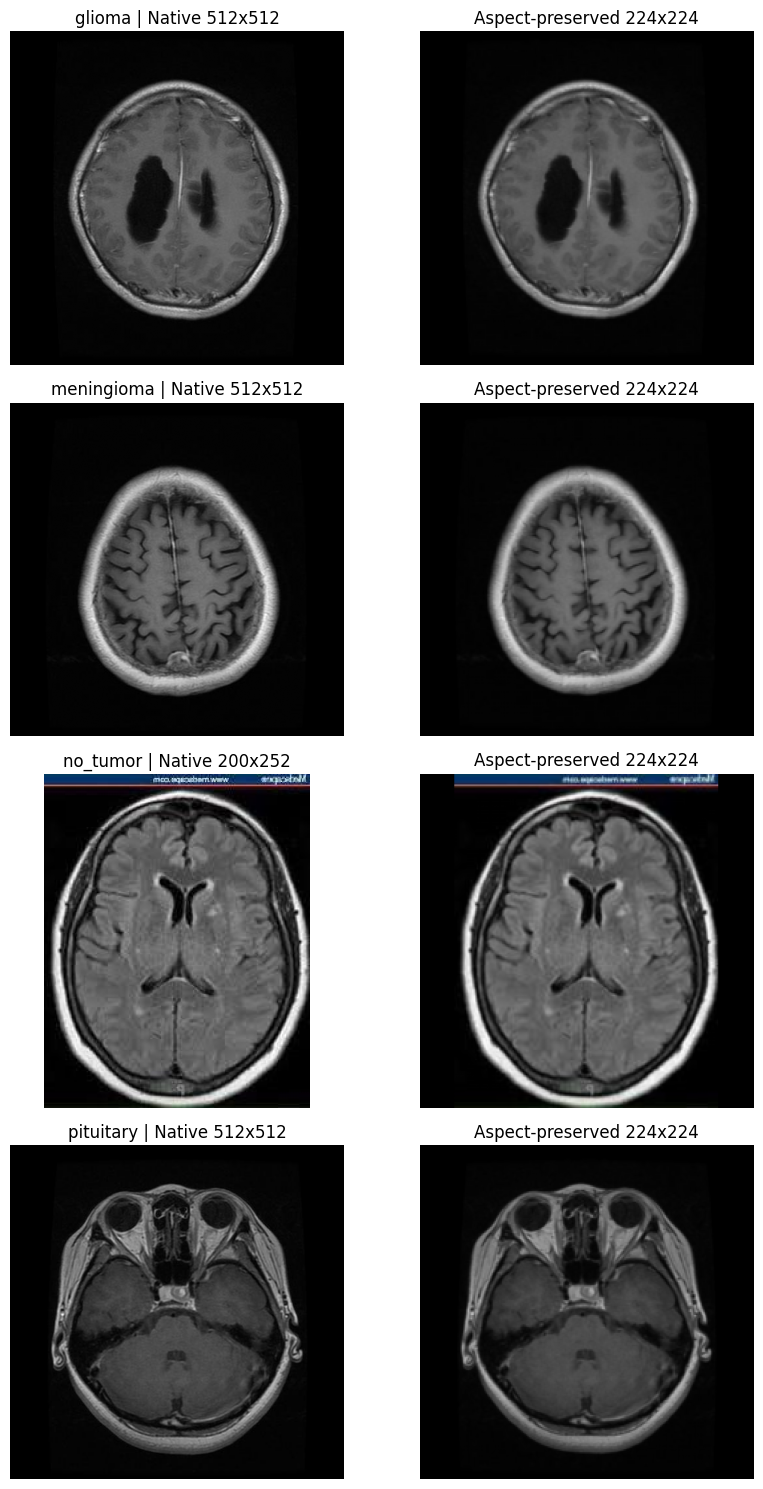

ValueError: arrays must be of dtype byte, short, float32 or float64

Error in callback <function _draw_all_if_interactive at 0x7d6761ee7d80> (for post_execute):


ValueError: arrays must be of dtype byte, short, float32 or float64

ValueError: arrays must be of dtype byte, short, float32 or float64

<Figure size 1800x1200 with 24 Axes>

In [ ]:
# ============================================================
# BATCH 3A
# PREPROCESSING AND CONSERVATIVE MRI AUGMENTATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

IMG_HEIGHT = 224
IMG_WIDTH = 224

IMG_SIZE = (
    IMG_HEIGHT,
    IMG_WIDTH
)

AUTOTUNE = tf.data.AUTOTUNE

PREPROCESSING_SEED = 42


# ------------------------------------------------------------
# CANONICAL CLASS ORDER
# ------------------------------------------------------------

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name
    in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: class_name
    for class_name, index
    in CLASS_TO_INDEX.items()
}

print("Class mapping:")

for class_name, index in CLASS_TO_INDEX.items():
    print(
        f"{index}: {class_name}"
    )


# ------------------------------------------------------------
# CORE ASPECT-RATIO-PRESERVING RESIZE
# ------------------------------------------------------------

def resize_with_padding(
    image,
    target_height=224,
    target_width=224
):
    """
    Resize while preserving aspect ratio, then pad to the
    requested dimensions.

    Padding uses zeros, which corresponds to black background.
    """

    image = tf.image.resize_with_pad(
        image,
        target_height=target_height,
        target_width=target_width,
        method="bilinear",
        antialias=True
    )

    return image


# ------------------------------------------------------------
# IMAGE DECODING
# ------------------------------------------------------------

def decode_image(
    image_path
):
    """
    Read an image from disk and convert it to RGB float32.
    """

    image_bytes = tf.io.read_file(
        image_path
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [
            None,
            None,
            3
        ]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = resize_with_padding(
        image,
        IMG_HEIGHT,
        IMG_WIDTH
    )

    return image


# ------------------------------------------------------------
# CONSERVATIVE MRI AUGMENTATION
# ------------------------------------------------------------

augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=PREPROCESSING_SEED
        ),

        tf.keras.layers.RandomRotation(
            factor=0.04,
            fill_mode="constant",
            fill_value=0.0,
            seed=PREPROCESSING_SEED
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="constant",
            fill_value=0.0,
            seed=PREPROCESSING_SEED
        ),

        tf.keras.layers.RandomZoom(
            height_factor=(-0.08, 0.08),
            width_factor=(-0.08, 0.08),
            fill_mode="constant",
            fill_value=0.0,
            seed=PREPROCESSING_SEED
        ),

        tf.keras.layers.RandomContrast(
            factor=0.08,
            seed=PREPROCESSING_SEED
        )
    ],
    name="conservative_mri_augmentation"
)


# ------------------------------------------------------------
# LOAD VERIFIED BDNEURO MANIFEST
# ------------------------------------------------------------

MANIFEST_PATH = (
    MANIFESTS_DIR /
    "bdneuro_v7_manifest_with_phash.csv"
)

manifest_df = pd.read_csv(
    MANIFEST_PATH
)

manifest_df = manifest_df[
    manifest_df["readable"] == True
].copy()

manifest_df = manifest_df.reset_index(
    drop=True
)

if len(manifest_df) != 5941:

    raise RuntimeError(
        f"Expected 5,941 images, "
        f"found {len(manifest_df):,}."
    )

print(
    "\nVerified manifest loaded:"
)

print(
    f"{len(manifest_df):,} images"
)


# ------------------------------------------------------------
# SELECT REPRODUCIBLE EXAMPLES
# ------------------------------------------------------------

sample_records = []

for class_name in CLASS_NAMES:

    class_subset = manifest_df[
        (
            manifest_df["split"] == "train"
        )
        &
        (
            manifest_df["class"] == class_name
        )
    ]

    sample_record = class_subset.sample(
        n=1,
        random_state=PREPROCESSING_SEED
    )

    sample_records.append(
        sample_record
    )


sample_df = pd.concat(
    sample_records,
    ignore_index=True
)

sample_df[
    [
        "class",
        "filename",
        "relative_path",
        "width",
        "height",
        "aspect_ratio"
    ]
].to_csv(
    AUDIT_RESULTS_DIR /
    "preprocessing_visual_check_samples.csv",
    index=False
)


# ============================================================
# FIGURE 1
# ORIGINAL VS ASPECT-PRESERVED 224 X 224
# ============================================================

fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=2,
    figsize=(9, 15)
)


for row_index, row in sample_df.iterrows():

    image_path = row[
        "absolute_path"
    ]

    with Image.open(
        image_path
    ) as image:

        original = np.asarray(
            image
        )

    processed = decode_image(
        image_path
    ).numpy()

    processed_display = (
        processed /
        255.0
    )

    axes[
        row_index,
        0
    ].imshow(
        original,
        cmap=(
            "gray"
            if original.ndim == 2
            else None
        )
    )

    axes[
        row_index,
        0
    ].axis(
        "off"
    )

    axes[
        row_index,
        0
    ].set_title(
        f"{row['class']} | Native "
        f"{int(row['width'])}x"
        f"{int(row['height'])}"
    )

    axes[
        row_index,
        1
    ].imshow(
        np.clip(
            processed_display,
            0,
            1
        )
    )

    axes[
        row_index,
        1
    ].axis(
        "off"
    )

    axes[
        row_index,
        1
    ].set_title(
        "Aspect-preserved 224x224"
    )


plt.tight_layout()

preprocessing_figure_path = (
    AUDIT_FIGURES_DIR /
    "bdneuro_original_vs_resize_with_padding.png"
)

plt.savefig(
    preprocessing_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# FIGURE 2
# AUGMENTATION VISUAL CHECK
# ============================================================

AUGMENTATION_EXAMPLES = 5


fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=AUGMENTATION_EXAMPLES + 1,
    figsize=(18, 12)
)


for row_index, row in sample_df.iterrows():

    base_image = decode_image(
        row[
            "absolute_path"
        ]
    )

    base_display = (
        base_image.numpy()
        /
        255.0
    )

    axes[
        row_index,
        0
    ].imshow(
        np.clip(
            base_display,
            0,
            1
        )
    )

    axes[
        row_index,
        0
    ].axis(
        "off"
    )

    axes[
        row_index,
        0
    ].set_title(
        f"{row['class']}\nOriginal"
    )


    for column_index in range(
        1,
        AUGMENTATION_EXAMPLES + 1
    ):

        augmented = augmentation(
            tf.expand_dims(
                base_image,
                axis=0
            ),
            training=True
        )[0]

        augmented_display = (
            augmented.numpy()
            /
            255.0
        )

        axes[
            row_index,
            column_index
        ].imshow(
            np.clip(
                augmented_display,
                0,
                1
            )
        )

        axes[
            row_index,
            column_index
        ].axis(
            "off"
        )

        axes[
            row_index,
            column_index
        ].set_title(
            f"Aug {column_index}"
        )


plt.tight_layout()

augmentation_figure_path = (
    AUDIT_FIGURES_DIR /
    "bdneuro_conservative_augmentation_examples.png"
)

plt.savefig(
    augmentation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ------------------------------------------------------------
# BASIC OUTPUT VALIDATION
# ------------------------------------------------------------

test_path = sample_df.iloc[
    0
]["absolute_path"]

test_image = decode_image(
    test_path
)

print("\n" + "=" * 72)
print("BATCH 3A PREPROCESSING SUMMARY")
print("=" * 72)

print(
    "Output image shape:",
    test_image.shape
)

print(
    "Output dtype:",
    test_image.dtype
)

print(
    "Minimum pixel value:",
    float(
        tf.reduce_min(
            test_image
        )
    )
)

print(
    "Maximum pixel value:",
    float(
        tf.reduce_max(
            test_image
        )
    )
)

print(
    "\nResize strategy:"
)

print(
    "Aspect-ratio-preserving resize + zero padding"
)

print(
    "\nTraining augmentation:"
)

print(
    "Horizontal flip"
)

print(
    "Rotation: approximately +/- 14 degrees"
)

print(
    "Translation: up to 5%"
)

print(
    "Zoom: approximately +/- 8%"
)

print(
    "Contrast: approximately +/- 8%"
)

print(
    "\nPreprocessing figure:"
)

print(
    preprocessing_figure_path
)

print(
    "\nAugmentation figure:"
)

print(
    augmentation_figure_path
)

In [ ]:
# Rebuild augmentation with flexible batch size
augmentation = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.025, fill_mode="constant", seed=42),
    tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode="constant", seed=42),
    tf.keras.layers.RandomZoom(0.08, fill_mode="constant", seed=42),
    tf.keras.layers.RandomContrast(0.08, seed=42),
])

df = pd.read_csv(MANIFESTS_DIR / "bdneuro_v7_image_manifest.csv")
df = df[df["readable"] == True].copy()

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df["label"] = df["class"].map(class_to_idx)

def make_dataset(split, training=False):
    d = df[df["split"] == split]

    ds = tf.data.Dataset.from_tensor_slices(
        (d["absolute_path"].values, d["label"].values)
    )

    ds = ds.map(
        lambda p, y: (decode_image(p), tf.cast(y, tf.int32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(len(d), seed=42)

    ds = ds.batch(BATCH_SIZE)

    if training:
        ds = ds.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset("train", True)
val_ds   = make_dataset("validation")
test_ds  = make_dataset("test")

for name, ds in [
    ("Train", train_ds),
    ("Validation", val_ds),
    ("Test", test_ds)
]:
    images, labels = next(iter(ds))
    print(name, images.shape, images.dtype, labels.shape)

Train (32, 224, 224, 3) <dtype: 'float16'> (32,)
Validation (32, 224, 224, 3) <dtype: 'float32'> (32,)
Test (32, 224, 224, 3) <dtype: 'float32'> (32,)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
import numpy as np
import tensorflow as tf

# Class weights
train_labels = df[df["split"] == "train"]["label"].values

weights = compute_class_weight(
    "balanced",
    classes=np.arange(4),
    y=train_labels
)

class_weights = {i: float(w) for i, w in enumerate(weights)}
print("Class weights:", class_weights)

# DenseNet121
tf.keras.utils.set_random_seed(42)

base = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.layers.Lambda(
    tf.keras.applications.densenet.preprocess_input
)(inputs)

x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    4,
    activation="softmax",
    dtype="float32"
)(x)

densenet = tf.keras.Model(inputs, outputs)

densenet.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint = CHECKPOINT_DIR / "densenet121_stage1.weights.h5"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = densenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Class weights: {0: 0.6779661016949152, 1: 1.0048309178743962, 2: 1.8874773139745917, 3: 1.0}
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 113s 699ms/step - accuracy: 0.5276 - loss: 1.0895 - val_accuracy: 0.7365 - val_loss: 0.6925
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 94s 662ms/step - accuracy: 0.7142 - loss: 0.6930 - val_accuracy: 0.7332 - val_loss: 0.6698
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 94s 662ms/step - accuracy: 0.7599 - loss: 0.6090 - val_accuracy: 0.7590 - val_loss: 0.6290
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 94s 663ms/step - accuracy: 0.7750 - loss: 0.5610 - val_accuracy: 0.7960 - val_loss: 0.5505
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 94s 663ms/step - accuracy: 0.7925 - loss: 0.5279 - val_accuracy: 0.8128 - val_loss: 0.4870
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 93s 654ms/step - accuracy: 0.8055 - loss: 0.5186 - val_accuracy: 0.8061 - val_loss: 0.5157
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 93s 653ms/step - accuracy: 0.

In [ ]:
y_true = np.concatenate(
    [y.numpy() for _, y in val_ds]
)

y_prob = densenet.predict(
    val_ds,
    verbose=0
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print("Validation Macro-F1:", round(macro_f1, 4))

Validation Macro-F1: 0.826


In [ ]:
# Unfreeze upper DenseNet layers
base.trainable = True

# Keep most of the backbone frozen
for layer in base.layers[:-80]:
    layer.trainable = False

# Keep BatchNorm layers frozen for stability
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

densenet.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_checkpoint = (
    CHECKPOINT_DIR /
    "densenet121_finetuned.weights.h5"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        fine_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

history_ft = densenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)






y_prob = densenet.predict(val_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    "Fine-tuned validation Macro-F1:",
    round(macro_f1, 4)
)

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 115s 703ms/step - accuracy: 0.8209 - loss: 0.4519 - val_accuracy: 0.8307 - val_loss: 0.4491 - learning_rate: 1.0000e-05
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 94s 661ms/step - accuracy: 0.8334 - loss: 0.4403 - val_accuracy: 0.8363 - val_loss: 0.4587 - learning_rate: 1.0000e-05
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 95s 671ms/step - accuracy: 0.8313 - loss: 0.4128 - val_accuracy: 0.8453 - val_loss: 0.4125 - learning_rate: 1.0000e-05
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 95s 670ms/step - accuracy: 0.8478 - loss: 0.3959 - val_accuracy: 0.8565 - val_loss: 0.4022 - learning_rate: 1.0000e-05
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 94s 660ms/step - accuracy: 0.8582 - loss: 0.3662 - val_accuracy: 0.8464 - val_loss: 0.4108 - learning_rate: 1.0000e-05
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 95s 670ms/step - accuracy: 0.8541 - loss: 0.3635 - val_accuracy: 0.8587 - val_loss: 0.3975 - learning_rate: 1.0000e-05
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 95s 6

In [ ]:
densenet_seed_results = {
    42: 0.8764
}

In [ ]:
# ============================================================
# DENSENET121: REMAINING SEEDS
# ============================================================

from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

def train_ds_for_seed(seed):
    aug = tf.keras.Sequential([
        tf.keras.Input(shape=(224, 224, 3)),
        tf.keras.layers.RandomFlip("horizontal", seed=seed),
        tf.keras.layers.RandomRotation(0.025, fill_mode="constant", seed=seed),
        tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode="constant", seed=seed),
        tf.keras.layers.RandomZoom(0.08, fill_mode="constant", seed=seed),
        tf.keras.layers.RandomContrast(0.08, seed=seed),
    ])

    d = df[df["split"] == "train"]

    ds = tf.data.Dataset.from_tensor_slices(
        (d["absolute_path"].values, d["label"].values)
    )

    ds = ds.map(
        lambda p, y: (decode_image(p), tf.cast(y, tf.int32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.shuffle(len(d), seed=seed)
    ds = ds.batch(BATCH_SIZE)

    ds = ds.map(
        lambda x, y: (aug(x, training=True), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.prefetch(tf.data.AUTOTUNE)


def run_densenet(seed):

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    train_seed_ds = train_ds_for_seed(seed)

    base = tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    inputs = tf.keras.Input((224, 224, 3))
    x = tf.keras.applications.densenet.preprocess_input(inputs)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    outputs = tf.keras.layers.Dense(
        4, activation="softmax", dtype="float32"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    # Stage 1
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        train_seed_ds,
        validation_data=val_ds,
        epochs=10,
        class_weight=class_weights,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=5, restore_best_weights=True
            )
        ],
        verbose=1
    )

    # Stage 2
    base.trainable = True

    for layer in base.layers[:-80]:
        layer.trainable = False

    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(1e-5, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        train_seed_ds,
        validation_data=val_ds,
        epochs=30,
        class_weight=class_weights,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=5, restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", patience=2, factor=0.2
            )
        ],
        verbose=1
    )

    prob = model.predict(val_ds, verbose=0)
    pred = np.argmax(prob, axis=1)

    score = f1_score(
        y_true,
        pred,
        average="macro"
    )

    model.save_weights(
        CHECKPOINT_DIR / f"densenet121_seed_{seed}.weights.h5"
    )

    print(f"\nSeed {seed} validation Macro-F1: {score:.4f}")

    return score


results = {42: 0.8764}

for seed in [123, 2026]:
    results[seed] = run_densenet(seed)

scores = np.array(list(results.values()))

print("\nDenseNet121 seed results")
for seed, score in results.items():
    print(f"Seed {seed}: {score:.4f}")

print(f"Mean Macro-F1: {scores.mean():.4f}")
print(f"SD: {scores.std(ddof=1):.4f}")

pd.DataFrame(
    [{"seed": s, "val_macro_f1": f} for s, f in results.items()]
).to_csv(
    RESULTS_DIR / "densenet121_seed_results.csv",
    index=False
)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 80s 472ms/step - accuracy: 0.5281 - loss: 1.0823 - val_accuracy: 0.7164 - val_loss: 0.7164
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 65s 440ms/step - accuracy: 0.7298 - loss: 0.6795 - val_accuracy: 0.7747 - val_loss: 0.5933
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 65s 440ms/step - accuracy: 0.7582 - loss: 0.6004 - val_accuracy: 0.7870 - val_loss: 0.5336
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 65s 439ms/step - accuracy: 0.7733 - loss: 0.5717 - val_accuracy: 0.7758 - val_loss: 0.5769
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 65s 440ms/step - accuracy: 0.7853 - loss: 0.5407 - val_accuracy: 0.7971 - val_loss: 0.5030
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 65s 439ms/step - accuracy: 0.7942 - loss: 0.5159 - val_accuracy: 0.8038 - val_loss: 0.5226
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 65s 440ms/step - accuracy: 0.8089 - loss: 0.4971 - val_accuracy: 0.8184 - val_loss: 0.4736
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 65s 440ms/step - accuracy: 0.8075 - loss: 0

In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

base = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

inputs = tf.keras.Input((224, 224, 3))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    4,
    activation="softmax",
    dtype="float32"
)(x)

efficientnet = tf.keras.Model(inputs, outputs)

# Stage 1
efficientnet.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

# Stage 2
base.trainable = True

for layer in base.layers[:-60]:
    layer.trainable = False

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

efficientnet.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=2,
            factor=0.2,
            min_lr=1e-7
        )
    ]
)

efficientnet.save_weights(
    CHECKPOINT_DIR /
    "efficientnetb0_seed42.weights.h5"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 103s 661ms/step - accuracy: 0.6281 - loss: 0.8967 - val_accuracy: 0.7108 - val_loss: 0.7507
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 91s 642ms/step - accuracy: 0.7575 - loss: 0.6268 - val_accuracy: 0.7455 - val_loss: 0.6642
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 91s 642ms/step - accuracy: 0.7832 - loss: 0.5555 - val_accuracy: 0.7601 - val_loss: 0.6230
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 92s 644ms/step - accuracy: 0.8007 - loss: 0.5171 - val_accuracy: 0.7769 - val_loss: 0.5775
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 92s 642ms/step - accuracy: 0.7981 - loss: 0.5027 - val_accuracy: 0.7780 - val_loss: 0.5718
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 91s 642ms/step - accuracy: 0.8101 - loss: 0.4767 - val_accuracy: 0.7971 - val_loss: 0.5438
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 92s 643ms/step - accuracy: 0.8144 - loss: 0.4699 - val_accuracy: 0.8128 - val_loss: 0.5045
Epoch 8/10
130/130 ━━━━━━━━━━━━

In [ ]:
eff_prob = efficientnet.predict(val_ds, verbose=0)
eff_pred = np.argmax(eff_prob, axis=1)

eff_macro_f1 = f1_score(
    y_true,
    eff_pred,
    average="macro"
)

print(
    "EfficientNet-B0 seed 42 validation Macro-F1:",
    round(eff_macro_f1, 4)
)

EfficientNet-B0 seed 42 validation Macro-F1: 0.9033


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

base = tf.keras.applications.MobileNetV3Large(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

inputs = tf.keras.Input((224, 224, 3))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    4, activation="softmax", dtype="float32"
)(x)

mobilenet = tf.keras.Model(inputs, outputs)

# Stage 1
mobilenet.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

# Stage 2
base.trainable = True

for layer in base.layers[:-50]:
    layer.trainable = False

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

mobilenet.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-5, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=2,
            factor=0.2,
            min_lr=1e-7
        )
    ]
)

mobilenet.save_weights(
    CHECKPOINT_DIR / "mobilenetv3large_seed42.weights.h5"
)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 97s 647ms/step - accuracy: 0.6022 - loss: 0.9681 - val_accuracy: 0.7892 - val_loss: 0.5678
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 90s 634ms/step - accuracy: 0.7663 - loss: 0.6037 - val_accuracy: 0.7836 - val_loss: 0.5526
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 90s 634ms/step - accuracy: 0.7925 - loss: 0.5281 - val_accuracy: 0.8206 - val_loss: 0.4497
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 90s 633ms/step - accuracy: 0.8173 - loss: 0.4666 - val_accuracy: 0.8061 - val_loss: 0.4753
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 90s 634ms/step - accuracy: 0.8313 - loss: 0.4346 - val_accuracy: 0.8464 - val_loss: 0.4280
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 90s 633ms/step - accuracy: 0.8356 - loss: 0.4118 - val_accuracy: 0.8430 - val_loss: 0.4257
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 91s 634ms/step - accuracy: 0.8399 - loss: 0.4035 - val_accuracy: 0.8442 - val_loss: 0.4358
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 91s 635ms/step - accuracy: 0.8486 - loss: 0

In [ ]:
mob_prob = mobilenet.predict(val_ds, verbose=0)
mob_pred = np.argmax(mob_prob, axis=1)

mob_macro_f1 = f1_score(
    y_true,
    mob_pred,
    average="macro"
)

print(
    "MobileNetV3-Large seed 42 validation Macro-F1:",
    round(mob_macro_f1, 4)
)

MobileNetV3-Large seed 42 validation Macro-F1: 0.9389


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Branch backbones
dense_base = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

eff_base = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Start frozen
dense_base.trainable = False
eff_base.trainable = False

inputs = tf.keras.Input((224, 224, 3))

# DenseNet branch
d = tf.keras.applications.densenet.preprocess_input(inputs)
d = dense_base(d, training=False)
d = tf.keras.layers.GlobalAveragePooling2D()(d)
d = tf.keras.layers.Dense(256, activation="relu")(d)

# EfficientNet branch
e = eff_base(inputs, training=False)
e = tf.keras.layers.GlobalAveragePooling2D()(e)
e = tf.keras.layers.Dense(256, activation="relu")(e)

# Fusion
x = tf.keras.layers.Concatenate()([d, e])
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.40)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    4,
    activation="softmax",
    dtype="float32"
)(x)

hybrid = tf.keras.Model(inputs, outputs)

# Stage 1
hybrid.compile(
    optimizer=tf.keras.optimizers.AdamW(
        1e-3,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hybrid.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

# Stage 2
dense_base.trainable = True
eff_base.trainable = True

for layer in dense_base.layers[:-80]:
    layer.trainable = False

for layer in eff_base.layers[:-60]:
    layer.trainable = False

for base_model in [dense_base, eff_base]:
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

hybrid.compile(
    optimizer=tf.keras.optimizers.AdamW(
        1e-5,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hybrid.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=2,
            factor=0.2,
            min_lr=1e-7
        )
    ]
)

hybrid.save_weights(
    CHECKPOINT_DIR / "hybrid_seed42.weights.h5"
)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 123s 728ms/step - accuracy: 0.7356 - loss: 0.6840 - val_accuracy: 0.8016 - val_loss: 0.4714
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 676ms/step - accuracy: 0.8411 - loss: 0.3933 - val_accuracy: 0.8408 - val_loss: 0.4480
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 674ms/step - accuracy: 0.8663 - loss: 0.3421 - val_accuracy: 0.8038 - val_loss: 0.5649
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 676ms/step - accuracy: 0.8827 - loss: 0.2952 - val_accuracy: 0.8632 - val_loss: 0.3359
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 675ms/step - accuracy: 0.8950 - loss: 0.2583 - val_accuracy: 0.8744 - val_loss: 0.3363
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 676ms/step - accuracy: 0.9065 - loss: 0.2443 - val_accuracy: 0.9114 - val_loss: 0.2477
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 674ms/step - accuracy: 0.9050 - loss: 0.2255 - val_accuracy: 0.8576 - val_loss: 0.4174
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 676ms/step - accuracy: 0.9096 - loss: 

In [ ]:
hyb_prob = hybrid.predict(val_ds, verbose=0)
hyb_pred = np.argmax(hyb_prob, axis=1)

hyb_macro_f1 = f1_score(
    y_true,
    hyb_pred,
    average="macro"
)

print(
    "Hybrid seed 42 validation Macro-F1:",
    round(hyb_macro_f1, 4)
)

Hybrid seed 42 validation Macro-F1: 0.932


In [ ]:
from pathlib import Path
import pandas as pd

ROOT = Path("/content/drive/MyDrive/Brain_MRI_Project")
RESULTS_DIR = ROOT / "04_results"
CHECKPOINT_DIR = ROOT / "03_checkpoints"

RESULTS_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

previous_results = pd.DataFrame([
    ["DenseNet121", 42, 0.8764],
    ["DenseNet121", 123, 0.8698],
    ["DenseNet121", 2026, 0.8648],
    ["EfficientNet-B0", 42, 0.9033],
    ["MobileNetV3-Large", 42, 0.9389],
    ["Hybrid", 42, 0.9320],
], columns=["model", "seed", "val_macro_f1"])

previous_results.to_csv(
    RESULTS_DIR / "recovered_validation_results.csv",
    index=False
)

print(previous_results)
print("\nRecovered results saved to Drive.")

               model  seed  val_macro_f1
0        DenseNet121    42        0.8764
1        DenseNet121   123        0.8698
2        DenseNet121  2026        0.8648
3    EfficientNet-B0    42        0.9033
4  MobileNetV3-Large    42        0.9389
5             Hybrid    42        0.9320

Recovered results saved to Drive.


In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/Brain_MRI_Project")

OUT = (
    ROOT /
    "01_BDNeuro_MRI_V7_Development" /
    "extracted_data"
)

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]

# Find any directory containing train, val and test
candidates = []

for p in [OUT] + [x for x in OUT.rglob("*") if x.is_dir()]:
    if (
        (p / "train").is_dir()
        and (p / "val").is_dir()
        and (p / "test").is_dir()
    ):
        candidates.append(p)

if not candidates:
    print("No dataset root detected.")
    print("\nExtracted folder structure:")
    for p in sorted(OUT.rglob("*")):
        if p.is_dir():
            print(p.relative_to(OUT))
    raise FileNotFoundError("Could not locate train/val/test folders.")

DATA_ROOT = candidates[0]

print("DATA_ROOT FOUND:")
print(DATA_ROOT)

total = 0

for split in ["train", "val", "test"]:
    print(f"\n{split}")
    split_total = 0

    for cls in CLASS_NAMES:
        p = DATA_ROOT / split / cls

        n = (
            sum(
                1 for f in p.rglob("*")
                if f.is_file()
                and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
            )
            if p.exists()
            else 0
        )

        print(f"{cls}: {n}")
        split_total += n

    print(f"{split} total: {split_total}")
    total += split_total

print(f"\nOVERALL TOTAL: {total}")

DATA_ROOT FOUND:
/content/drive/MyDrive/Brain_MRI_Project/01_BDNeuro_MRI_V7_Development/extracted_data

train
glioma: 1534
meningioma: 1035
no_tumor: 551
pituitary: 1040
train total: 4160

val
glioma: 329
meningioma: 222
no_tumor: 118
pituitary: 223
val total: 892

test
glioma: 328
meningioma: 221
no_tumor: 118
pituitary: 222
test total: 889

OVERALL TOTAL: 5941


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

DATA_ROOT = Path(
    "/content/drive/MyDrive/Brain_MRI_Project/"
    "01_BDNeuro_MRI_V7_Development/extracted_data"
)

ROOT = Path("/content/drive/MyDrive/Brain_MRI_Project")
CHECKPOINT_DIR = ROOT / "03_checkpoints"
RESULTS_DIR = ROOT / "04_results"

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
LABEL_MAP = {c: i for i, c in enumerate(CLASS_NAMES)}
BATCH_SIZE = 32

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
tf.keras.mixed_precision.set_global_policy("mixed_float16")


def build_frame(split):
    rows = []

    for cls in CLASS_NAMES:
        files = sorted(
            f for f in (DATA_ROOT / split / cls).rglob("*")
            if f.is_file()
            and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
        )

        rows.extend(
            (str(f), cls, LABEL_MAP[cls])
            for f in files
        )

    return pd.DataFrame(
        rows,
        columns=["filepath", "class_name", "label_id"]
    )


train_df = build_frame("train")
val_df = build_frame("val")
test_df = build_frame("test")


def decode_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(
        img,
        channels=3,
        expand_animations=False
    )
    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)

    img = tf.image.resize_with_pad(
        img,
        224,
        224,
        method="bilinear",
        antialias=True
    )

    return img, label


def make_augmentation(seed):
    return tf.keras.Sequential([
        tf.keras.layers.Input((224, 224, 3)),
        tf.keras.layers.RandomFlip(
            "horizontal", seed=seed
        ),
        tf.keras.layers.RandomRotation(
            0.025,
            fill_mode="constant",
            seed=seed
        ),
        tf.keras.layers.RandomTranslation(
            0.05, 0.05,
            fill_mode="constant",
            seed=seed
        ),
        tf.keras.layers.RandomZoom(
            0.08,
            fill_mode="constant",
            seed=seed
        ),
        tf.keras.layers.RandomContrast(
            0.08,
            seed=seed
        )
    ])


def make_ds(frame, training=False, seed=42):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            frame.filepath.values,
            frame.label_id.values.astype(np.int32)
        )
    )

    if training:
        ds = ds.shuffle(
            len(frame),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)

    if training:
        aug = make_augmentation(seed)
        ds = ds.map(
            lambda x, y: (aug(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    return ds.prefetch(tf.data.AUTOTUNE)


def train_ds_for_seed(seed):
    return make_ds(train_df, training=True, seed=seed)


train_ds = train_ds_for_seed(42)
val_ds = make_ds(val_df)
test_ds = make_ds(test_df)

y_true = val_df.label_id.to_numpy()

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(4),
    y=train_df.label_id.to_numpy()
)

class_weights = {
    i: float(w)
    for i, w in enumerate(weights)
}

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("y_true:", len(y_true))

xb, yb = next(iter(train_ds))
print("Train batch:", xb.shape, xb.dtype)

Train: 4160
Validation: 892
Test: 889
y_true: 892
Train batch: (32, 224, 224, 3) <dtype: 'float16'>


In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from sklearn.metrics import f1_score

ROOT = Path("/content/drive/MyDrive/Brain_MRI_Project")
CHECKPOINT_DIR = ROOT / "03_checkpoints"
RESULTS_DIR = ROOT / "04_results"
RECOVERY_DIR = CHECKPOINT_DIR / "finalist_recovery"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RECOVERY_DIR.mkdir(parents=True, exist_ok=True)

RESULT_FILE = RESULTS_DIR / "finalist_seed_results.csv"


def stage1_callbacks(run_dir, best_file, done_file):
    return [
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=str(run_dir / "stage1_backup"),
            save_freq="epoch",
            delete_checkpoint=False
        ),
        tf.keras.callbacks.ModelCheckpoint(
            str(best_file),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.LambdaCallback(
            on_train_end=lambda logs:
            done_file.write_text("complete")
        )
    ]


def stage2_callbacks(run_dir, best_file, done_file):
    return [
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=str(run_dir / "stage2_backup"),
            save_freq="epoch",
            delete_checkpoint=False
        ),
        tf.keras.callbacks.ModelCheckpoint(
            str(best_file),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=2,
            factor=0.2,
            min_lr=1e-7
        ),
        tf.keras.callbacks.LambdaCallback(
            on_train_end=lambda logs:
            done_file.write_text("complete")
        )
    ]


def run_mobilenet(seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    tr = train_ds_for_seed(seed)

    run_dir = RECOVERY_DIR / f"mobilenet_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    s1_best = run_dir / "stage1_best.weights.h5"
    s2_best = run_dir / "stage2_best.weights.h5"
    s1_done = run_dir / "stage1.done"
    s2_done = run_dir / "stage2.done"

    base = tf.keras.applications.MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    inp = tf.keras.Input((224, 224, 3))
    x = base(inp, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    out = tf.keras.layers.Dense(
        4,
        activation="softmax",
        dtype="float32"
    )(x)

    model = tf.keras.Model(inp, out)

    # Stage 1
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-3,
            weight_decay=1e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    if s1_done.exists() and s1_best.exists():
        print("Stage 1 already complete. Loading checkpoint.")
        model.load_weights(s1_best)
    else:
        model.fit(
            tr,
            validation_data=val_ds,
            epochs=10,
            class_weight=class_weights,
            callbacks=stage1_callbacks(
                run_dir, s1_best, s1_done
            )
        )
        model.load_weights(s1_best)

    # Stage 2
    base.trainable = True

    for layer in base.layers[:-50]:
        layer.trainable = False

    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-5,
            weight_decay=1e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    if s2_done.exists() and s2_best.exists():
        print("Stage 2 already complete. Loading checkpoint.")
        model.load_weights(s2_best)
    else:
        model.fit(
            tr,
            validation_data=val_ds,
            epochs=30,
            class_weight=class_weights,
            callbacks=stage2_callbacks(
                run_dir, s2_best, s2_done
            )
        )
        model.load_weights(s2_best)

    prob = model.predict(val_ds, verbose=0)
    pred = np.argmax(prob, axis=1)

    score = f1_score(
        y_true,
        pred,
        average="macro"
    )

    model.save_weights(
        CHECKPOINT_DIR /
        f"mobilenetv3_seed_{seed}.weights.h5"
    )

    return score


def run_hybrid(seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    tr = train_ds_for_seed(seed)

    run_dir = RECOVERY_DIR / f"hybrid_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    s1_best = run_dir / "stage1_best.weights.h5"
    s2_best = run_dir / "stage2_best.weights.h5"
    s1_done = run_dir / "stage1.done"
    s2_done = run_dir / "stage2.done"

    dense = tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    eff = tf.keras.applications.EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    dense.trainable = False
    eff.trainable = False

    inp = tf.keras.Input((224, 224, 3))

    d = tf.keras.applications.densenet.preprocess_input(inp)
    d = dense(d, training=False)
    d = tf.keras.layers.GlobalAveragePooling2D()(d)
    d = tf.keras.layers.Dense(256, activation="relu")(d)

    e = eff(inp, training=False)
    e = tf.keras.layers.GlobalAveragePooling2D()(e)
    e = tf.keras.layers.Dense(256, activation="relu")(e)

    x = tf.keras.layers.Concatenate()([d, e])
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.20)(x)

    out = tf.keras.layers.Dense(
        4,
        activation="softmax",
        dtype="float32"
    )(x)

    model = tf.keras.Model(inp, out)

    # Stage 1
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-3,
            weight_decay=1e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    if s1_done.exists() and s1_best.exists():
        print("Stage 1 already complete. Loading checkpoint.")
        model.load_weights(s1_best)
    else:
        model.fit(
            tr,
            validation_data=val_ds,
            epochs=10,
            class_weight=class_weights,
            callbacks=stage1_callbacks(
                run_dir, s1_best, s1_done
            )
        )
        model.load_weights(s1_best)

    # Stage 2
    dense.trainable = True
    eff.trainable = True

    for layer in dense.layers[:-80]:
        layer.trainable = False

    for layer in eff.layers[:-60]:
        layer.trainable = False

    for backbone in [dense, eff]:
        for layer in backbone.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-5,
            weight_decay=1e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    if s2_done.exists() and s2_best.exists():
        print("Stage 2 already complete. Loading checkpoint.")
        model.load_weights(s2_best)
    else:
        model.fit(
            tr,
            validation_data=val_ds,
            epochs=30,
            class_weight=class_weights,
            callbacks=stage2_callbacks(
                run_dir, s2_best, s2_done
            )
        )
        model.load_weights(s2_best)

    prob = model.predict(val_ds, verbose=0)
    pred = np.argmax(prob, axis=1)

    score = f1_score(
        y_true,
        pred,
        average="macro"
    )

    model.save_weights(
        CHECKPOINT_DIR /
        f"hybrid_seed_{seed}.weights.h5"
    )

    return score


# Preserve known seed-42 results
if RESULT_FILE.exists():
    results = pd.read_csv(RESULT_FILE)
else:
    results = pd.DataFrame([
        ["MobileNetV3-Large", 42, 0.9389],
        ["Hybrid", 42, 0.9320]
    ], columns=["model", "seed", "val_macro_f1"])

    results.to_csv(RESULT_FILE, index=False)


queue = [
    ("MobileNetV3-Large", 123, run_mobilenet),
    ("MobileNetV3-Large", 2026, run_mobilenet),
    ("Hybrid", 123, run_hybrid),
    ("Hybrid", 2026, run_hybrid)
]


for i, (name, seed, fn) in enumerate(queue, 1):

    already_done = (
        (results["model"] == name) &
        (results["seed"] == seed)
    ).any()

    if already_done:
        print(f"\nSKIPPING: {name}, seed {seed}, already complete")
        continue

    print("\n" + "=" * 60)
    print(f"RUN {i}/4: {name}, seed {seed}")
    print("=" * 60)

    score = fn(seed)

    results.loc[len(results)] = [
        name,
        seed,
        score
    ]

    results.to_csv(
        RESULT_FILE,
        index=False
    )

    print(
        f"\nCOMPLETED: {name}, seed {seed}, "
        f"Macro-F1 = {score:.4f}"
    )

    gc.collect()


print("\n" + "=" * 60)
print("FINALIST RESULTS")
print("=" * 60)

print(results.to_string(index=False))

for name in ["MobileNetV3-Large", "Hybrid"]:

    scores = results.loc[
        results["model"] == name,
        "val_macro_f1"
    ].values

    if len(scores) == 3:
        print(
            f"\n{name}: "
            f"{scores.mean():.4f} ± "
            f"{scores.std(ddof=1):.4f}"
        )

print("\nResults saved to:")
print(RESULT_FILE)


RUN 1/4: MobileNetV3-Large, seed 123
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 80s 543ms/step - accuracy: 0.5810 - loss: 1.0113 - val_accuracy: 0.7410 - val_loss: 0.6451
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 69s 527ms/step - accuracy: 0.7594 - loss: 0.6092 - val_accuracy: 0.7836 - val_loss: 0.5519
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 70s 539ms/step - accuracy: 0.7983 - loss: 0.5160 - val_accuracy: 0.7982 - val_loss: 0.5115
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 70s 536ms/step - accuracy: 0.8161 - loss: 0.4633 - val_accuracy: 0.8229 - val_loss: 0.4758
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 70s 536ms/step - accuracy: 0.8255 - loss: 0.4427 - val_accuracy: 0.8374 - val_loss: 0.4152
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 70s 535ms/step - accuracy: 0.8416 - loss: 0.4086 - val_accuracy: 0.8543 - val_loss: 0.3976
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 68s 525ms/step - accuracy: 0.8454 - loss: 0.3931 - val_accuracy: 0.8206 - val_loss: 0

In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

FINAL_MODEL = CHECKPOINT_DIR / "NeuroFusion_MobileNetV3Large_final.keras"
BEST_WEIGHTS = CHECKPOINT_DIR / "mobilenetv3_final_seed42.weights.h5"

tr = train_ds_for_seed(42)

base = tf.keras.applications.MobileNetV3Large(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

inputs = tf.keras.Input((224, 224, 3))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    4,
    activation="softmax",
    dtype="float32"
)(x)

model = tf.keras.Model(inputs, outputs)

# Stage 1
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    tr,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

# Stage 2
base.trainable = True

for layer in base.layers[:-50]:
    layer.trainable = False

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    tr,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            BEST_WEIGHTS,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=2,
            factor=0.2,
            min_lr=1e-7
        )
    ]
)

# Save COMPLETE model for deployment
model.save(FINAL_MODEL)

print("Full model saved:")
print(FINAL_MODEL)

# Independent reload test
del model
gc.collect()
tf.keras.backend.clear_session()

model = tf.keras.models.load_model(FINAL_MODEL)

# Validation verification
val_prob = model.predict(val_ds, verbose=0)
val_pred = np.argmax(val_prob, axis=1)

val_f1 = f1_score(y_true, val_pred, average="macro")

print("\nReloaded model validation Macro-F1:", round(val_f1, 4))

# Untouched internal test evaluation
test_true = test_df.label_id.to_numpy()
test_prob = model.predict(test_ds, verbose=0)
test_pred = np.argmax(test_prob, axis=1)

test_acc = accuracy_score(test_true, test_pred)
test_bal_acc = balanced_accuracy_score(test_true, test_pred)
test_f1 = f1_score(test_true, test_pred, average="macro")

print("\nINTERNAL TEST RESULTS")
print("Accuracy:", round(test_acc, 4))
print("Balanced accuracy:", round(test_bal_acc, 4))
print("Macro-F1:", round(test_f1, 4))

pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy", "macro_f1"],
    "value": [test_acc, test_bal_acc, test_f1]
}).to_csv(
    RESULTS_DIR / "mobilenet_final_internal_test_metrics.csv",
    index=False
)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 74s 528ms/step - accuracy: 0.6060 - loss: 0.9633 - val_accuracy: 0.7422 - val_loss: 0.6463
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 516ms/step - accuracy: 0.7673 - loss: 0.5839 - val_accuracy: 0.7926 - val_loss: 0.5207
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 515ms/step - accuracy: 0.7993 - loss: 0.5073 - val_accuracy: 0.8274 - val_loss: 0.4506
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 515ms/step - accuracy: 0.8147 - loss: 0.4619 - val_accuracy: 0.8105 - val_loss: 0.4844
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 515ms/step - accuracy: 0.8337 - loss: 0.4300 - val_accuracy: 0.8206 - val_loss: 0.4584
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 514ms/step - accuracy: 0.8397 - loss: 0.4070 - val_accuracy: 0.8352 - val_loss: 0.4292
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 514ms/step - accuracy: 0.8392 - loss: 0.4106 - val_accuracy: 0.8262 - val_loss: 0.4361
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 67s 516ms/step - accuracy: 0.8502 - loss: 0

In [ ]:
import hashlib
import pandas as pd

# Save validation predictions
val_out = val_df.copy()
val_out["predicted"] = val_pred
for i, c in enumerate(CLASS_NAMES):
    val_out[f"prob_{c}"] = val_prob[:, i]

val_out.to_csv(
    RESULTS_DIR / "final_model_validation_predictions.csv",
    index=False
)

# Save internal test predictions
test_out = test_df.copy()
test_out["predicted"] = test_pred
for i, c in enumerate(CLASS_NAMES):
    test_out[f"prob_{c}"] = test_prob[:, i]

test_out.to_csv(
    RESULTS_DIR / "final_model_internal_test_predictions.csv",
    index=False
)

# Fingerprint exact deployment model
with open(FINAL_MODEL, "rb") as f:
    model_sha256 = hashlib.sha256(f.read()).hexdigest()

print("FINAL MODEL LOCKED")
print("File:", FINAL_MODEL)
print("SHA256:", model_sha256)
print("Validation Macro-F1:", round(val_f1, 4))
print("Internal Test Macro-F1:", round(test_f1, 4))

FINAL MODEL LOCKED
File: /content/drive/MyDrive/Brain_MRI_Project/03_checkpoints/NeuroFusion_MobileNetV3Large_final.keras
SHA256: 1d36d54ce404af8d06e0cb6b44f99ac446d863640822305b90e6f5319351db8e
Validation Macro-F1: 0.9029
Internal Test Macro-F1: 0.9062


In [ ]:
#EXTERNAL VALIDATION OF THE MOBILE NET V3 MODEL (NUEROFUSION MODEL)

from pathlib import Path
import zipfile
import hashlib
import pandas as pd

ROOT = Path("/content/drive/MyDrive/Brain_MRI_Project")
EXT_PROJECT = ROOT / "02_Nickparvar_Kaggle_External"
EXT_OUT = EXT_PROJECT / "extracted_data"

CLASS_MAP = {
    "glioma": "glioma",
    "meningioma": "meningioma",
    "notumor": "no_tumor",
    "pituitary": "pituitary"
}

# Locate existing extracted dataset
roots = [
    p for p in EXT_OUT.rglob("*")
    if p.is_dir()
    and (p / "Training").is_dir()
    and (p / "Testing").is_dir()
] if EXT_OUT.exists() else []

if not roots:
    # Locate your original archive (4).zip
    zips = list(
        Path("/content/drive/MyDrive").rglob("archive (4).zip")
    )

    if not zips:
        raise FileNotFoundError(
            "Nickparvar archive (4).zip not found in Drive."
        )

    print("Found Nickparvar ZIP:", zips[0])

    EXT_OUT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zips[0]) as z:
        z.extractall(EXT_OUT)

    candidates = [EXT_OUT] + [
        p for p in EXT_OUT.rglob("*") if p.is_dir()
    ]

    roots = [
        p for p in candidates
        if (p / "Training").is_dir()
        and (p / "Testing").is_dir()
    ]

if not roots:
    raise FileNotFoundError(
        "Could not locate Nickparvar Training/Testing folders."
    )

EXT_ROOT = roots[0]

print("External dataset root:")
print(EXT_ROOT)


# Build external dataframe
rows = []

for split in ["Training", "Testing"]:
    for source_class, final_class in CLASS_MAP.items():

        folder = EXT_ROOT / split / source_class

        for f in sorted(folder.rglob("*")):
            if (
                f.is_file()
                and f.suffix.lower()
                in [".jpg", ".jpeg", ".png", ".bmp"]
            ):
                rows.append([
                    str(f),
                    split,
                    source_class,
                    final_class
                ])

ext_df = pd.DataFrame(
    rows,
    columns=[
        "filepath",
        "source_split",
        "source_class",
        "class_name"
    ]
)

print("\nNickparvar counts:")
print(
    ext_df.groupby(
        ["source_split", "class_name"]
    ).size().unstack(fill_value=0)
)

print("\nTotal external images:", len(ext_df))


# SHA256 helper
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


print("\nHashing BDNeuro...")
bd_all = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test")
    ],
    ignore_index=True
)

bd_all["sha256"] = bd_all["filepath"].map(sha256_file)


print("Hashing Nickparvar...")
ext_df["sha256"] = ext_df["filepath"].map(sha256_file)


# Cross-dataset exact duplicate detection
dup = ext_df.merge(
    bd_all[
        ["filepath", "class_name", "split", "sha256"]
    ],
    on="sha256",
    suffixes=("_external", "_bdneuro")
)

AUDIT_DIR = RESULTS_DIR / "02_external_validation"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

ext_df.to_csv(
    AUDIT_DIR / "nickparvar_manifest.csv",
    index=False
)

dup.to_csv(
    AUDIT_DIR /
    "bdneuro_nickparvar_exact_duplicates.csv",
    index=False
)

print("\nCROSS-DATASET EXACT DUPLICATE AUDIT")
print("Exact matching pairs:", len(dup))

if len(dup):
    print("\nBy external class:")
    print(dup["class_name_external"].value_counts())

    print("\nBy BDNeuro split:")
    print(dup["split"].value_counts())
else:
    print("No exact cross-dataset duplicates detected.")

Found Nickparvar ZIP: /content/drive/MyDrive/Brain_MRI_Project/02_Nickparvar_Kaggle_External/archive (4).zip
External dataset root:
/content/drive/MyDrive/Brain_MRI_Project/02_Nickparvar_Kaggle_External/extracted_data

Nickparvar counts:
class_name    glioma  meningioma  no_tumor  pituitary
source_split                                         
Testing          400         400       400        400
Training        1400        1400      1400       1400

Total external images: 7200

Hashing BDNeuro...
Hashing Nickparvar...

CROSS-DATASET EXACT DUPLICATE AUDIT
Exact matching pairs: 3409

By external class:
class_name_external
glioma        1097
meningioma     986
pituitary      896
no_tumor       430
Name: count, dtype: int64

By BDNeuro split:
split
train    2388
val       549
test      472
Name: count, dtype: int64


In [ ]:
# Remove every external image that exactly matches ANY BDNeuro image
bd_hashes = set(bd_all["sha256"])

ext_clean = ext_df[
    ~ext_df["sha256"].isin(bd_hashes)
].copy()

print("Original Nickparvar:", len(ext_df))
print("Exact-overlap removed:", len(ext_df) - len(ext_clean))
print("Exact-clean external cohort:", len(ext_clean))

print("\nClean cohort by split/class:")
print(
    ext_clean.groupby(
        ["source_split", "class_name"]
    ).size().unstack(fill_value=0)
)

print("\nClean cohort by class:")
print(
    ext_clean["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

ext_clean.to_csv(
    AUDIT_DIR / "nickparvar_exact_deduplicated_manifest.csv",
    index=False
)

Original Nickparvar: 7200
Exact-overlap removed: 3409
Exact-clean external cohort: 3791

Clean cohort by split/class:
class_name    glioma  meningioma  no_tumor  pituitary
source_split                                         
Testing          136         260       333        240
Training         567         554      1037        664

Clean cohort by class:
class_name
glioma         703
meningioma     814
no_tumor      1370
pituitary      904
Name: count, dtype: int64


In [ ]:
# Cross-dataset perceptual near-duplicate audit

try:
    import imagehash
except ImportError:
    !pip -q install ImageHash
    import imagehash

import numpy as np
import pandas as pd

from PIL import Image
from functools import lru_cache
from skimage.metrics import structural_similarity as ssim


def get_phash(path):
    with Image.open(path) as im:
        return np.uint64(int(str(imagehash.phash(im.convert("L"))), 16))


print("Computing BDNeuro pHashes...")
bd_all["phash"] = bd_all["filepath"].map(get_phash)

print("Computing Nickparvar pHashes...")
ext_clean["phash"] = ext_clean["filepath"].map(get_phash)


bd_hash = bd_all["phash"].to_numpy(dtype=np.uint64)
ext_hash = ext_clean["phash"].to_numpy(dtype=np.uint64)

# Fast bit-count lookup
popcount = np.unpackbits(
    np.arange(256, dtype=np.uint8)[:, None],
    axis=1
).sum(axis=1)

candidates = []

for start in range(0, len(ext_clean), 128):
    end = min(start + 128, len(ext_clean))

    xor = ext_hash[start:end, None] ^ bd_hash[None, :]
    bytes_view = xor.view(np.uint8).reshape(xor.shape + (8,))
    dist = popcount[bytes_view].sum(axis=2)

    ei, bi = np.where(dist <= 6)

    for e, b in zip(ei, bi):
        candidates.append([
            start + e,
            b,
            int(dist[e, b])
        ])

cand = pd.DataFrame(
    candidates,
    columns=["external_index", "bd_index", "phash_distance"]
)

print("\npHash candidates <= 6:", len(cand))


@lru_cache(maxsize=4096)
def load_gray(path):
    with Image.open(path) as im:
        im = im.convert("L")
        im.thumbnail((224, 224), Image.Resampling.BILINEAR)

        canvas = Image.new("L", (224, 224), 0)
        x = (224 - im.width) // 2
        y = (224 - im.height) // 2
        canvas.paste(im, (x, y))

        return np.asarray(canvas, dtype=np.float32) / 255.0


ssim_scores = []

print("Confirming candidates with SSIM...")

for _, r in cand.iterrows():

    ep = ext_clean.iloc[int(r.external_index)]["filepath"]
    bp = bd_all.iloc[int(r.bd_index)]["filepath"]

    score = ssim(
        load_gray(ep),
        load_gray(bp),
        data_range=1.0
    )

    ssim_scores.append(score)

cand["ssim"] = ssim_scores

cand["external_filepath"] = cand["external_index"].map(
    lambda i: ext_clean.iloc[i]["filepath"]
)

cand["external_class"] = cand["external_index"].map(
    lambda i: ext_clean.iloc[i]["class_name"]
)

cand["bd_filepath"] = cand["bd_index"].map(
    lambda i: bd_all.iloc[i]["filepath"]
)

cand["bd_class"] = cand["bd_index"].map(
    lambda i: bd_all.iloc[i]["class_name"]
)

cand["bd_split"] = cand["bd_index"].map(
    lambda i: bd_all.iloc[i]["split"]
)

cand.to_csv(
    AUDIT_DIR / "cross_dataset_phash_ssim_candidates.csv",
    index=False
)

print("\nNEAR-DUPLICATE SUMMARY")
print("pHash <= 6:", len(cand))
print("SSIM >= 0.950:", (cand["ssim"] >= 0.950).sum())
print("SSIM >= 0.975:", (cand["ssim"] >= 0.975).sum())
print("SSIM >= 0.985:", (cand["ssim"] >= 0.985).sum())
print("SSIM >= 0.990:", (cand["ssim"] >= 0.990).sum())

if len(cand):
    print("\nHighest SSIM:", cand["ssim"].max())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.4 MB/s eta 0:00:00
Computing BDNeuro pHashes...
Computing Nickparvar pHashes...

pHash candidates <= 6: 4883
Confirming candidates with SSIM...

NEAR-DUPLICATE SUMMARY
pHash <= 6: 4883
SSIM >= 0.950: 1149
SSIM >= 0.975: 867
SSIM >= 0.985: 686
SSIM >= 0.990: 614

Highest SSIM: 1.0


In [ ]:
# Lock a strict near-duplicate-clean external cohort

strong = cand[cand["ssim"] >= 0.985].copy()

strong_ext = set(strong["external_filepath"])

print("Strong near-duplicate pairs:", len(strong))
print("Unique external images affected:", len(strong_ext))
print("Unique BDNeuro images involved:", strong["bd_filepath"].nunique())

print("\nStrong overlaps by external class:")
print(
    strong.drop_duplicates("external_filepath")
    ["external_class"]
    .value_counts()
)

print("\nStrong overlaps by BDNeuro split:")
print(
    strong.drop_duplicates("external_filepath")
    ["bd_split"]
    .value_counts()
)

print("\nClass agreement among strong pairs:")
print(
    (
        strong["external_class"] ==
        strong["bd_class"]
    ).value_counts()
)

# Remove ALL external images with any SSIM >= 0.985 match
ext_final = ext_clean[
    ~ext_clean["filepath"].isin(strong_ext)
].copy()

print("\nFINAL EXTERNAL COHORT")
print("Before near-duplicate exclusion:", len(ext_clean))
print("Near-duplicate images removed:", len(strong_ext))
print("Final external images:", len(ext_final))

print("\nFinal class counts:")
print(
    ext_final["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("\nFinal split/class counts:")
print(
    ext_final.groupby(
        ["source_split", "class_name"]
    ).size().unstack(fill_value=0)
)

ext_final.to_csv(
    AUDIT_DIR /
    "nickparvar_final_deduplicated_external_manifest.csv",
    index=False
)

Strong near-duplicate pairs: 686
Unique external images affected: 685
Unique BDNeuro images involved: 530

Strong overlaps by external class:
external_class
no_tumor      352
meningioma    158
pituitary     122
glioma         53
Name: count, dtype: int64

Strong overlaps by BDNeuro split:
bd_split
train    497
val       98
test      90
Name: count, dtype: int64

Class agreement among strong pairs:
True     685
False      1
Name: count, dtype: int64

FINAL EXTERNAL COHORT
Before near-duplicate exclusion: 3791
Near-duplicate images removed: 685
Final external images: 3106

Final class counts:
class_name
glioma         650
meningioma     656
no_tumor      1018
pituitary      782
Name: count, dtype: int64

Final split/class counts:
class_name    glioma  meningioma  no_tumor  pituitary
source_split                                         
Testing          115         150       209        173
Training         535         506       809        609


In [ ]:
import hashlib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    classification_report
)
from sklearn.preprocessing import label_binarize

FINAL_MODEL = (
    ROOT / "03_checkpoints" /
    "NeuroFusion_MobileNetV3Large_final.keras"
)

EXPECTED_SHA256 = (
    "1d36d54ce404af8d06e0cb6b44f99ac446d863640822305b90e6f5319351db8e"
)

# Verify exact frozen model
with open(FINAL_MODEL, "rb") as f:
    actual_hash = hashlib.sha256(f.read()).hexdigest()

assert actual_hash == EXPECTED_SHA256, "Model fingerprint mismatch"

print("Frozen model verified.")


# Labels
label_map = {c: i for i, c in enumerate(CLASS_NAMES)}
ext_final["label_id"] = ext_final["class_name"].map(label_map)


# External tf.data loader
def make_external_ds(frame):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            frame["filepath"].values,
            frame["label_id"].values.astype(np.int32)
        )
    )

    ds = ds.map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.batch(32).prefetch(tf.data.AUTOTUNE)


ext_ds = make_external_ds(ext_final)

# Load frozen deployment model
model = tf.keras.models.load_model(FINAL_MODEL)

# Inference
ext_prob = model.predict(ext_ds, verbose=1)
ext_pred = np.argmax(ext_prob, axis=1)
ext_true = ext_final["label_id"].to_numpy()

# Main metrics
acc = accuracy_score(ext_true, ext_pred)
bal_acc = balanced_accuracy_score(ext_true, ext_pred)
macro_precision = precision_score(
    ext_true, ext_pred, average="macro"
)
macro_recall = recall_score(
    ext_true, ext_pred, average="macro"
)
macro_f1 = f1_score(
    ext_true, ext_pred, average="macro"
)
mcc = matthews_corrcoef(ext_true, ext_pred)

y_bin = label_binarize(
    ext_true,
    classes=np.arange(len(CLASS_NAMES))
)

macro_auc = roc_auc_score(
    y_bin,
    ext_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = average_precision_score(
    y_bin,
    ext_prob,
    average="macro"
)

print("\nEXTERNAL VALIDATION RESULTS")
print("N:", len(ext_final))
print("Accuracy:", round(acc, 4))
print("Balanced accuracy:", round(bal_acc, 4))
print("Macro precision:", round(macro_precision, 4))
print("Macro recall:", round(macro_recall, 4))
print("Macro-F1:", round(macro_f1, 4))
print("MCC:", round(mcc, 4))
print("Macro AUROC:", round(macro_auc, 4))
print("Macro AUPRC:", round(macro_auprc, 4))


# Per-class metrics
cm = confusion_matrix(ext_true, ext_pred)

rows = []

for i, cls in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    rows.append({
        "class": cls,
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "precision": precision_score(
            ext_true == i,
            ext_pred == i,
            zero_division=0
        ),
        "f1": f1_score(
            ext_true == i,
            ext_pred == i,
            zero_division=0
        )
    })

per_class = pd.DataFrame(rows)

print("\nPER-CLASS METRICS")
print(per_class.round(4).to_string(index=False))


# Save image-level predictions
predictions = ext_final.copy()
predictions["predicted_id"] = ext_pred
predictions["predicted_class"] = [
    CLASS_NAMES[i] for i in ext_pred
]
predictions["confidence"] = ext_prob.max(axis=1)

for i, cls in enumerate(CLASS_NAMES):
    predictions[f"prob_{cls}"] = ext_prob[:, i]

predictions.to_csv(
    AUDIT_DIR / "external_predictions_final.csv",
    index=False
)

summary = pd.DataFrame({
    "metric": [
        "n",
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "mcc",
        "macro_auroc",
        "macro_auprc"
    ],
    "value": [
        len(ext_final),
        acc,
        bal_acc,
        macro_precision,
        macro_recall,
        macro_f1,
        mcc,
        macro_auc,
        macro_auprc
    ]
})

summary.to_csv(
    AUDIT_DIR / "external_metrics_summary.csv",
    index=False
)

per_class.to_csv(
    AUDIT_DIR / "external_per_class_metrics.csv",
    index=False
)

print("\nPredictions and metrics saved.")

Frozen model verified.
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step

EXTERNAL VALIDATION RESULTS
N: 3106
Accuracy: 0.9495
Balanced accuracy: 0.9405
Macro precision: 0.9472
Macro recall: 0.9405
Macro-F1: 0.9426
MCC: 0.9324
Macro AUROC: 0.9935
Macro AUPRC: 0.9819

PER-CLASS METRICS
     class  sensitivity  specificity  precision     f1
    glioma       0.9200       0.9910     0.9645 0.9417
meningioma       0.8476       0.9833     0.9313 0.8875
  no_tumor       0.9971       0.9966     0.9932 0.9951
 pituitary       0.9974       0.9626     0.8997 0.9460

Predictions and metrics saved.


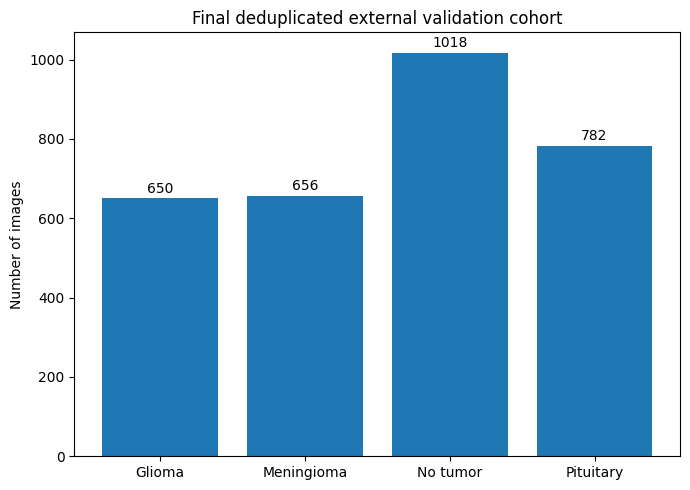

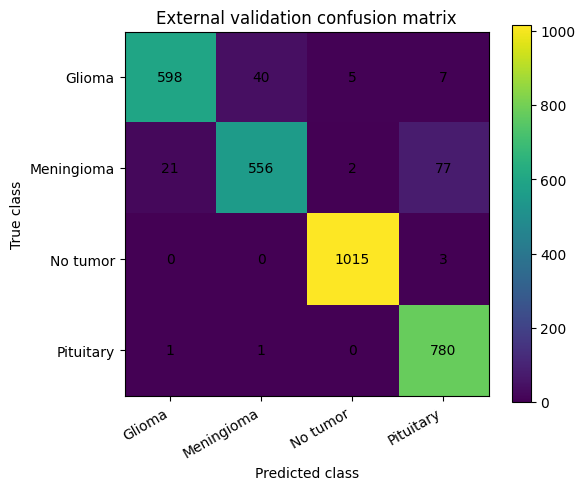

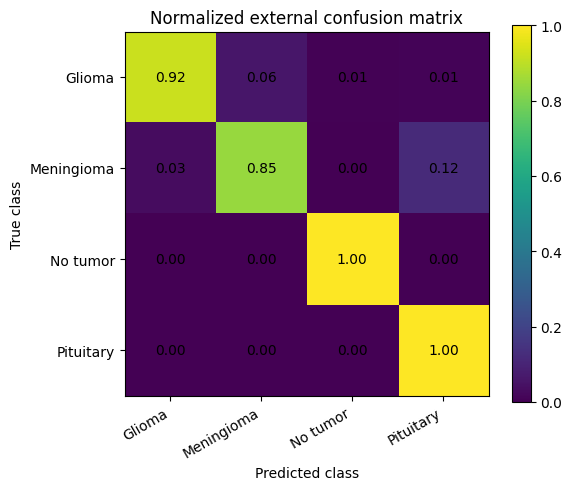

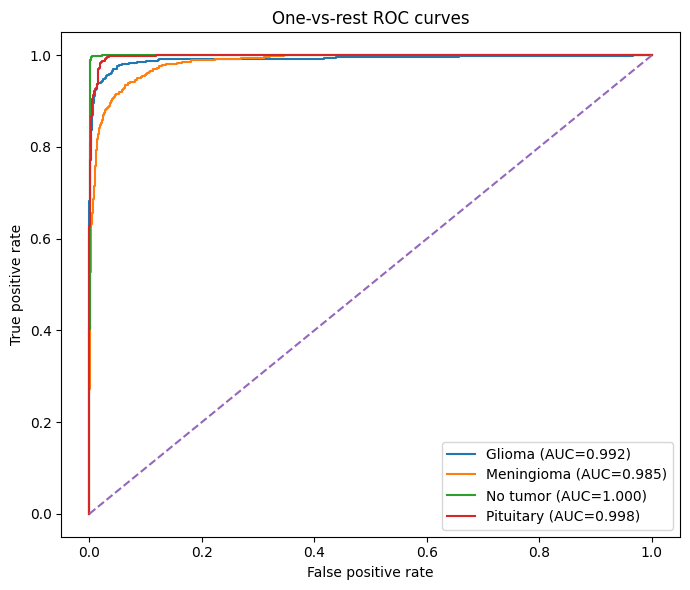

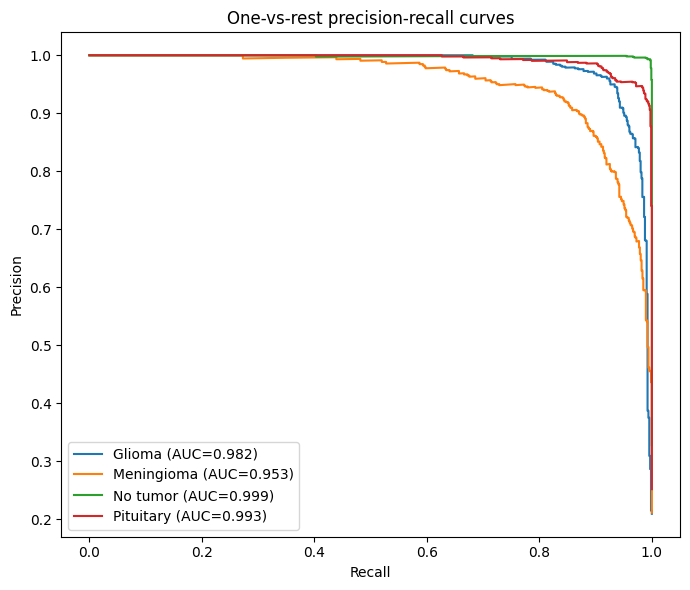

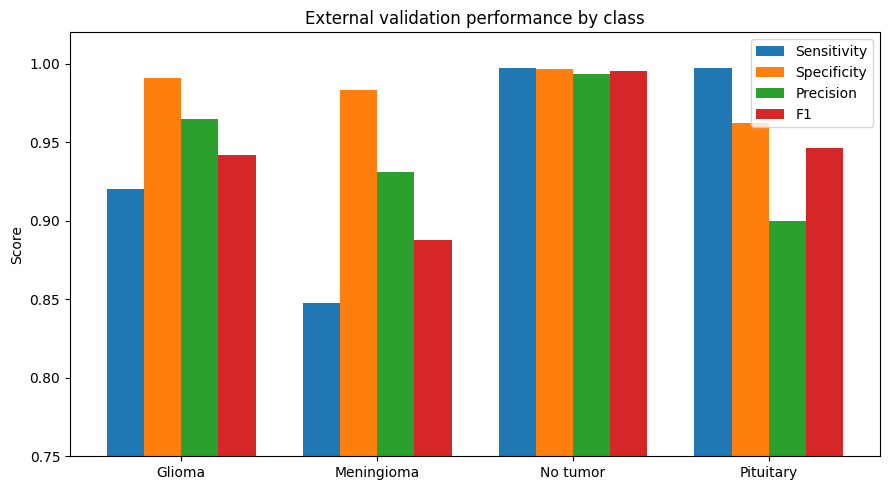

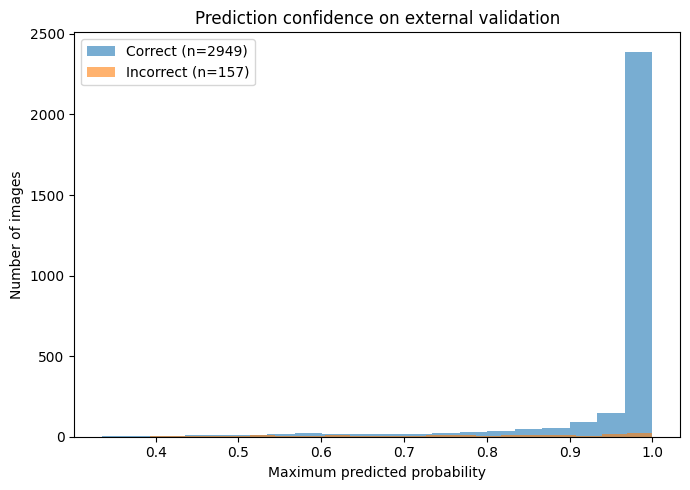

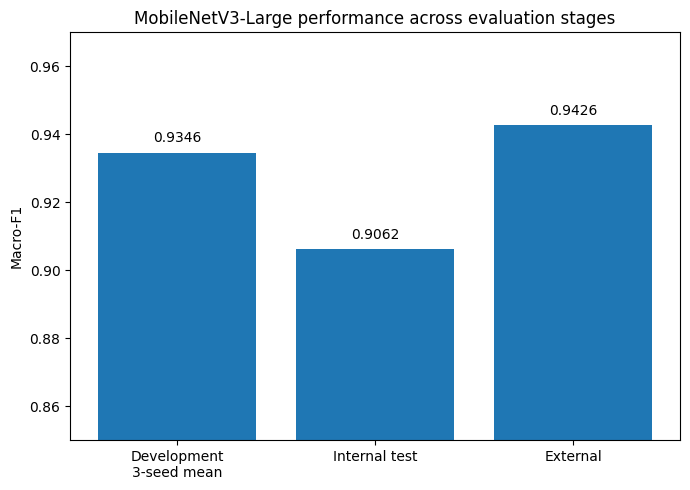

Figures saved to:
/content/drive/MyDrive/Brain_MRI_Project/05_figures/02_external_validation


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.calibration import calibration_curve

FIG_DIR = ROOT / "05_figures" / "02_external_validation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DISPLAY_NAMES = ["Glioma", "Meningioma", "No tumor", "Pituitary"]


def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()


# 1. External class distribution
counts = ext_final["class_name"].value_counts().reindex(CLASS_NAMES)

plt.figure(figsize=(7, 5))
bars = plt.bar(DISPLAY_NAMES, counts.values)
plt.ylabel("Number of images")
plt.title("Final deduplicated external validation cohort")

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 15,
        str(value),
        ha="center"
    )

savefig("external_class_distribution")


# 2. Raw confusion matrix
cm = confusion_matrix(ext_true, ext_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(4), DISPLAY_NAMES, rotation=30, ha="right")
plt.yticks(range(4), DISPLAY_NAMES)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("External validation confusion matrix")

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha="center", va="center")

savefig("external_confusion_matrix_raw")


# 3. Normalized confusion matrix
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(4), DISPLAY_NAMES, rotation=30, ha="right")
plt.yticks(range(4), DISPLAY_NAMES)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalized external confusion matrix")

for i in range(4):
    for j in range(4):
        plt.text(
            j, i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center"
        )

savefig("external_confusion_matrix_normalized")


# 4. ROC curves
plt.figure(figsize=(7, 6))

for i, name in enumerate(DISPLAY_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ext_prob[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={class_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("One-vs-rest ROC curves")
plt.legend()

savefig("external_roc_curves")


# 5. Precision-recall curves
plt.figure(figsize=(7, 6))

for i, name in enumerate(DISPLAY_NAMES):
    precision, recall, _ = precision_recall_curve(
        y_bin[:, i],
        ext_prob[:, i]
    )
    class_ap = auc(recall, precision)
    plt.plot(
        recall,
        precision,
        label=f"{name} (AUC={class_ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("One-vs-rest precision-recall curves")
plt.legend()

savefig("external_precision_recall_curves")


# 6. Per-class performance
metrics = ["sensitivity", "specificity", "precision", "f1"]
x = np.arange(4)
width = 0.19

plt.figure(figsize=(9, 5))

for k, metric in enumerate(metrics):
    plt.bar(
        x + (k - 1.5) * width,
        per_class[metric],
        width,
        label=metric.replace("_", " ").title()
    )

plt.xticks(x, DISPLAY_NAMES)
plt.ylim(0.75, 1.02)
plt.ylabel("Score")
plt.title("External validation performance by class")
plt.legend()

savefig("external_per_class_performance")


# 7. Prediction confidence
correct_conf = ext_prob.max(axis=1)[ext_pred == ext_true]
wrong_conf = ext_prob.max(axis=1)[ext_pred != ext_true]

plt.figure(figsize=(7, 5))
plt.hist(
    correct_conf,
    bins=20,
    alpha=0.6,
    label=f"Correct (n={len(correct_conf)})"
)
plt.hist(
    wrong_conf,
    bins=20,
    alpha=0.6,
    label=f"Incorrect (n={len(wrong_conf)})"
)

plt.xlabel("Maximum predicted probability")
plt.ylabel("Number of images")
plt.title("Prediction confidence on external validation")
plt.legend()

savefig("external_prediction_confidence")


# 8. Development vs internal vs external
phase_names = [
    "Development\n3-seed mean",
    "Internal test",
    "External"
]

phase_f1 = [0.9346, 0.9062, 0.9426]

plt.figure(figsize=(7, 5))
bars = plt.bar(phase_names, phase_f1)
plt.ylim(0.85, 0.97)
plt.ylabel("Macro-F1")
plt.title("MobileNetV3-Large performance across evaluation stages")

for bar, value in zip(bars, phase_f1):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.003,
        f"{value:.4f}",
        ha="center"
    )

savefig("performance_across_evaluation_stages")

print("Figures saved to:")
print(FIG_DIR)

Running 2000 stratified bootstrap replicates...

EXTERNAL VALIDATION WITH 95% BOOTSTRAP CI
Accuracy: 0.9495 (95% CI 0.9420-0.9572)
Balanced accuracy: 0.9405 (95% CI 0.9318-0.9495)
Macro-F1: 0.9426 (95% CI 0.9340-0.9513)
MCC: 0.9324 (95% CI 0.9226-0.9425)
Macro AUROC: 0.9935 (95% CI 0.9916-0.9951)
Macro AUPRC: 0.9819 (95% CI 0.9776-0.9858)


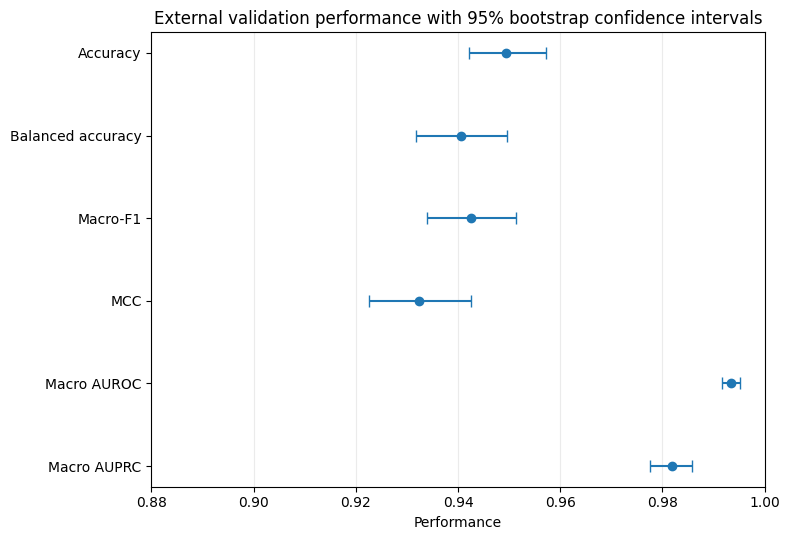


Saved:
/content/drive/MyDrive/Brain_MRI_Project/04_results/02_external_validation/external_metrics_bootstrap_95CI.csv
/content/drive/MyDrive/Brain_MRI_Project/05_figures/02_external_validation/external_metrics_bootstrap_95CI.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

N_BOOT = 2000
rng = np.random.default_rng(42)

class_indices = [
    np.where(ext_true == i)[0]
    for i in range(len(CLASS_NAMES))
]

boot = []

print(f"Running {N_BOOT} stratified bootstrap replicates...")

for b in range(N_BOOT):

    idx = np.concatenate([
        rng.choice(x, size=len(x), replace=True)
        for x in class_indices
    ])

    yt = ext_true[idx]
    yp = ext_pred[idx]
    pr = ext_prob[idx]

    yb = label_binarize(
        yt,
        classes=np.arange(len(CLASS_NAMES))
    )

    boot.append([
        accuracy_score(yt, yp),
        balanced_accuracy_score(yt, yp),
        f1_score(yt, yp, average="macro"),
        matthews_corrcoef(yt, yp),
        roc_auc_score(
            yb, pr,
            average="macro",
            multi_class="ovr"
        ),
        average_precision_score(
            yb, pr,
            average="macro"
        )
    ])

boot = np.asarray(boot)

metric_names = [
    "Accuracy",
    "Balanced accuracy",
    "Macro-F1",
    "MCC",
    "Macro AUROC",
    "Macro AUPRC"
]

point = np.array([
    acc,
    bal_acc,
    macro_f1,
    mcc,
    macro_auc,
    macro_auprc
])

lower = np.percentile(boot, 2.5, axis=0)
upper = np.percentile(boot, 97.5, axis=0)

ci_df = pd.DataFrame({
    "metric": metric_names,
    "estimate": point,
    "ci_lower_95": lower,
    "ci_upper_95": upper
})

print("\nEXTERNAL VALIDATION WITH 95% BOOTSTRAP CI")
for _, r in ci_df.iterrows():
    print(
        f"{r['metric']}: "
        f"{r['estimate']:.4f} "
        f"(95% CI {r['ci_lower_95']:.4f}-"
        f"{r['ci_upper_95']:.4f})"
    )

ci_df.to_csv(
    AUDIT_DIR / "external_metrics_bootstrap_95CI.csv",
    index=False
)

# Save all bootstrap replicates
pd.DataFrame(
    boot,
    columns=metric_names
).to_csv(
    AUDIT_DIR / "external_bootstrap_replicates_2000.csv",
    index=False
)

# Forest-style CI figure
y = np.arange(len(metric_names))

plt.figure(figsize=(8, 5.5))

plt.errorbar(
    point,
    y,
    xerr=[point - lower, upper - point],
    fmt="o",
    capsize=4
)

plt.yticks(y, metric_names)
plt.xlabel("Performance")
plt.title(
    "External validation performance with 95% bootstrap confidence intervals"
)
plt.xlim(0.88, 1.0)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "external_metrics_bootstrap_95CI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "external_metrics_bootstrap_95CI.pdf",
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(AUDIT_DIR / "external_metrics_bootstrap_95CI.csv")
print(FIG_DIR / "external_metrics_bootstrap_95CI.png")

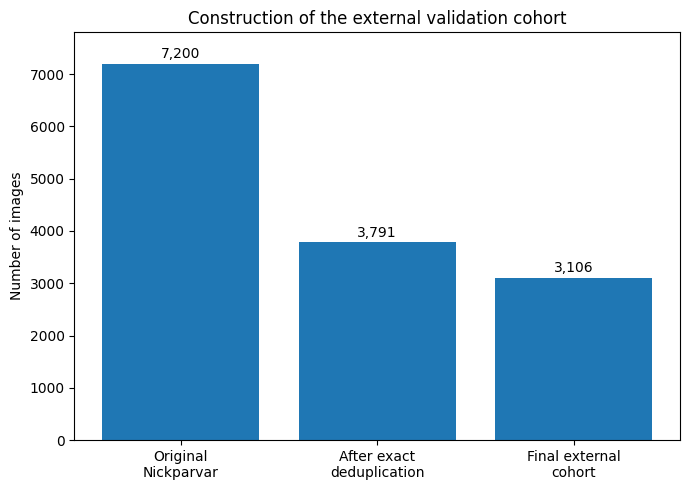

MOST COMMON ERRORS
true_class predicted_class  n
meningioma       pituitary 77
    glioma      meningioma 40
meningioma          glioma 21
    glioma       pituitary  7
    glioma        no_tumor  5
  no_tumor       pituitary  3
meningioma        no_tumor  2
 pituitary          glioma  1
 pituitary      meningioma  1


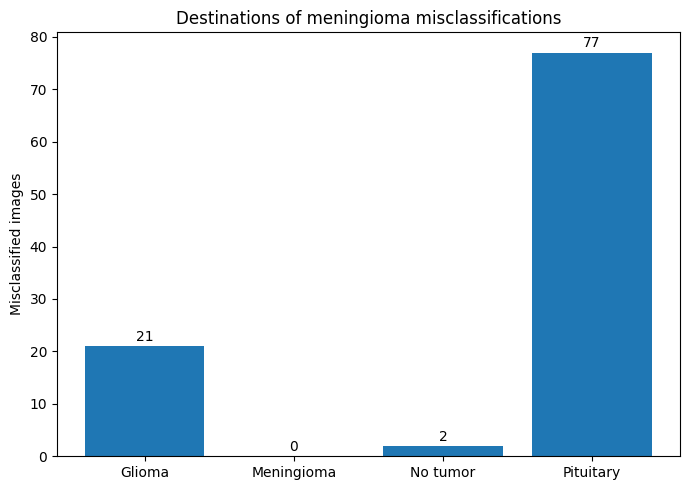


Expected Calibration Error: 0.0187


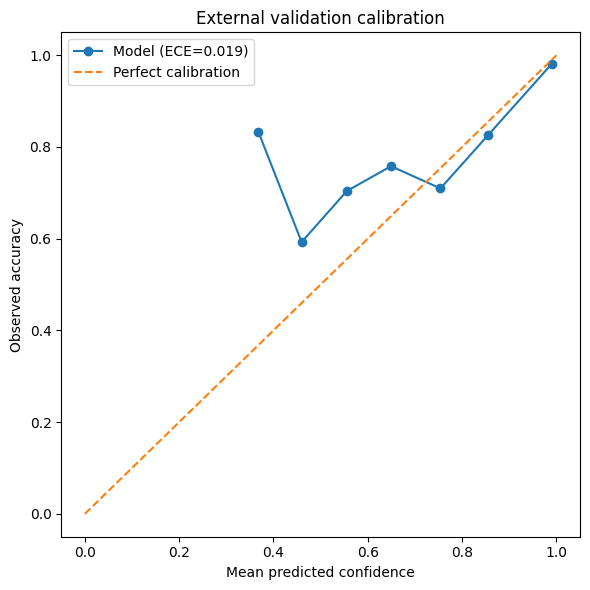


PER-CLASS F1 WITH 95% CI
     class     f1  ci_lower  ci_upper
    glioma 0.9417    0.9283    0.9547
meningioma 0.8875    0.8685    0.9061
  no_tumor 0.9951    0.9922    0.9980
 pituitary 0.9460    0.9360    0.9565


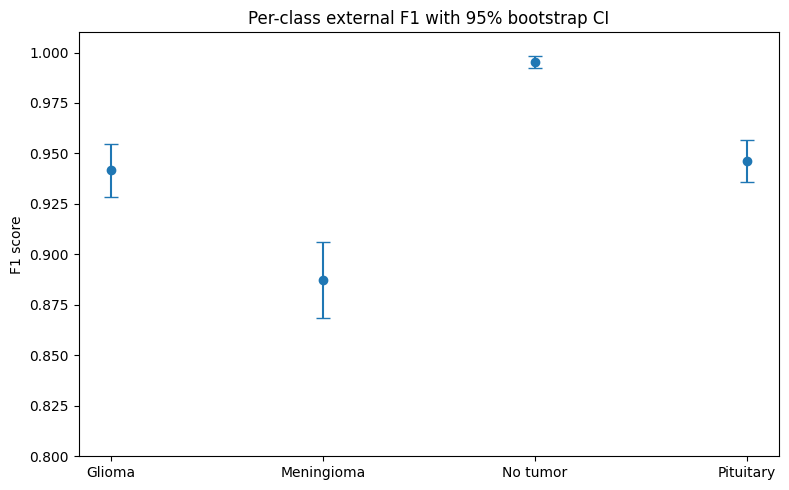


Total external errors: 157
External error rate: 0.0505

Figures saved to:
/content/drive/MyDrive/Brain_MRI_Project/05_figures/02_external_validation


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, f1_score

# --------------------------------------------------
# 1. Deduplication flow
# --------------------------------------------------

stages = [
    "Original\nNickparvar",
    "After exact\ndeduplication",
    "Final external\ncohort"
]

n_values = [7200, 3791, 3106]

plt.figure(figsize=(7, 5))
bars = plt.bar(stages, n_values)

for bar, n in zip(bars, n_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        n + 100,
        f"{n:,}",
        ha="center"
    )

plt.ylabel("Number of images")
plt.title("Construction of the external validation cohort")
plt.ylim(0, 7800)

savefig("external_cohort_deduplication_flow")


# --------------------------------------------------
# 2. Misclassification destinations
# --------------------------------------------------

cm = confusion_matrix(ext_true, ext_pred)

errors = []

for i, true_cls in enumerate(CLASS_NAMES):
    for j, pred_cls in enumerate(CLASS_NAMES):
        if i != j and cm[i, j] > 0:
            errors.append({
                "true_class": true_cls,
                "predicted_class": pred_cls,
                "n": int(cm[i, j])
            })

error_df = pd.DataFrame(errors).sort_values(
    "n",
    ascending=False
)

error_df.to_csv(
    AUDIT_DIR / "external_misclassification_patterns.csv",
    index=False
)

print("MOST COMMON ERRORS")
print(error_df.to_string(index=False))


# --------------------------------------------------
# 3. Meningioma error pattern
# --------------------------------------------------

men_idx = CLASS_NAMES.index("meningioma")

men_counts = cm[men_idx].copy()
men_counts[men_idx] = 0

plt.figure(figsize=(7, 5))
bars = plt.bar(DISPLAY_NAMES, men_counts)

for bar, n in zip(bars, men_counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        n + 1,
        str(n),
        ha="center"
    )

plt.ylabel("Misclassified images")
plt.title("Destinations of meningioma misclassifications")

savefig("meningioma_misclassification_destinations")


# --------------------------------------------------
# 4. Overall confidence calibration
# --------------------------------------------------

confidence = ext_prob.max(axis=1)
correct = (ext_pred == ext_true).astype(int)

bins = np.linspace(0, 1, 11)

bin_ids = np.digitize(
    confidence,
    bins[1:-1]
)

calibration = []

for b in range(10):
    mask = bin_ids == b

    if mask.sum() == 0:
        continue

    calibration.append({
        "bin": b,
        "n": mask.sum(),
        "mean_confidence": confidence[mask].mean(),
        "accuracy": correct[mask].mean()
    })

cal_df = pd.DataFrame(calibration)

ece = np.sum(
    (cal_df["n"] / len(ext_true)) *
    np.abs(
        cal_df["accuracy"] -
        cal_df["mean_confidence"]
    )
)

print("\nExpected Calibration Error:", round(ece, 4))

cal_df.to_csv(
    AUDIT_DIR / "external_calibration.csv",
    index=False
)

plt.figure(figsize=(6, 6))

plt.plot(
    cal_df["mean_confidence"],
    cal_df["accuracy"],
    marker="o",
    label=f"Model (ECE={ece:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("External validation calibration")
plt.legend()

savefig("external_calibration_curve")


# --------------------------------------------------
# 5. Per-class F1 bootstrap CI
# --------------------------------------------------

rng = np.random.default_rng(42)
N_BOOT_CLASS = 2000

class_boot = np.zeros(
    (N_BOOT_CLASS, len(CLASS_NAMES))
)

class_indices = [
    np.where(ext_true == i)[0]
    for i in range(4)
]

for b in range(N_BOOT_CLASS):

    idx = np.concatenate([
        rng.choice(x, len(x), replace=True)
        for x in class_indices
    ])

    class_boot[b] = f1_score(
        ext_true[idx],
        ext_pred[idx],
        labels=np.arange(4),
        average=None
    )

class_est = f1_score(
    ext_true,
    ext_pred,
    labels=np.arange(4),
    average=None
)

class_low = np.percentile(
    class_boot, 2.5, axis=0
)

class_high = np.percentile(
    class_boot, 97.5, axis=0
)

class_ci = pd.DataFrame({
    "class": CLASS_NAMES,
    "f1": class_est,
    "ci_lower": class_low,
    "ci_upper": class_high
})

class_ci.to_csv(
    AUDIT_DIR / "external_per_class_f1_95CI.csv",
    index=False
)

print("\nPER-CLASS F1 WITH 95% CI")
print(class_ci.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))

x = np.arange(4)

plt.errorbar(
    x,
    class_est,
    yerr=[
        class_est - class_low,
        class_high - class_est
    ],
    fmt="o",
    capsize=5
)

plt.xticks(x, DISPLAY_NAMES)
plt.ylabel("F1 score")
plt.ylim(0.80, 1.01)
plt.title("Per-class external F1 with 95% bootstrap CI")

savefig("external_per_class_f1_bootstrap_ci")


# --------------------------------------------------
# 6. Save all errors for later qualitative review
# --------------------------------------------------

error_cases = predictions[
    predictions["predicted_id"] !=
    predictions["label_id"]
].copy()

error_cases = error_cases.sort_values(
    "confidence",
    ascending=False
)

error_cases.to_csv(
    AUDIT_DIR / "external_misclassified_cases.csv",
    index=False
)

print("\nTotal external errors:", len(error_cases))
print("External error rate:", round(len(error_cases) / len(ext_true), 4))

print("\nFigures saved to:")
print(FIG_DIR)

In [ ]:
#TELEGRAM BOT DEPLOMENT

!pip -q install python-telegram-bot nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.4/769.4 kB 12.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import hashlib
import tensorflow as tf

ROOT = Path("/content/drive/MyDrive/Brain_MRI_Project")

MODEL_PATH = (
    ROOT / "03_checkpoints" /
    "NeuroFusion_MobileNetV3Large_final.keras"
)

EXPECTED_SHA256 = (
    "1d36d54ce404af8d06e0cb6b44f99ac446d863640822305b90e6f5319351db8e"
)

with open(MODEL_PATH, "rb") as f:
    model_hash = hashlib.sha256(f.read()).hexdigest()

assert model_hash == EXPECTED_SHA256, "Model fingerprint mismatch"

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

CLASS_NAMES = [
    "Glioma",
    "Meningioma",
    "No tumor",
    "Pituitary"
]

print("Frozen deployment model verified and loaded.")
print("Input:", model.input_shape)
print("Output:", model.output_shape)

Frozen deployment model verified and loaded.
Input: (None, 224, 224, 3)
Output: (None, 4)


In [ ]:
import numpy as np

def preprocess_telegram_image(image_bytes):
    img = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)

    img = tf.image.resize_with_pad(
        img,
        224,
        224,
        method="bilinear",
        antialias=True
    )

    return tf.expand_dims(img, axis=0)


def predict_mri(image_bytes):
    x = preprocess_telegram_image(image_bytes)

    prob = model.predict(
        x,
        verbose=0
    )[0]

    pred_id = int(np.argmax(prob))

    return pred_id, prob

In [ ]:
from getpass import getpass

TELEGRAM_BOT_TOKEN = getpass(
    "Paste your Telegram bot token: "
)

print("Token received.")

Paste your Telegram bot token: ··········
Token received.


In [ ]:
import io
import nest_asyncio

from telegram import Update
from telegram.ext import (
    Application,
    CommandHandler,
    MessageHandler,
    ContextTypes,
    filters
)

nest_asyncio.apply()


async def start(update: Update, context: ContextTypes.DEFAULT_TYPE):
    text = (
        "NeuroFusionBot\n\n"
        "Brain MRI four-class classification system.\n\n"
        "Classes:\n"
        "• Glioma\n"
        "• Meningioma\n"
        "• Pituitary tumor\n"
        "• No tumor\n\n"
        "Send a brain MRI image as a photo or image file "
        "to obtain the model prediction.\n\n"
        "Research use only. Not intended for clinical diagnosis."
    )

    await update.message.reply_text(text)


async def help_command(
    update: Update,
    context: ContextTypes.DEFAULT_TYPE
):
    text = (
        "Send one brain MRI image to this chat.\n\n"
        "Supported input: Telegram photo or image document.\n\n"
        "The model will return the predicted class, "
        "prediction confidence, and probabilities for all four classes."
    )

    await update.message.reply_text(text)


async def classify_image(
    update: Update,
    context: ContextTypes.DEFAULT_TYPE
):
    message = update.message

    try:
        await message.reply_text("Analyzing MRI image...")

        if message.photo:
            telegram_file = await message.photo[-1].get_file()

        elif message.document:
            mime = message.document.mime_type or ""

            if not mime.startswith("image/"):
                await message.reply_text(
                    "Please upload a valid image file."
                )
                return

            telegram_file = await message.document.get_file()

        else:
            return

        buffer = io.BytesIO()

        await telegram_file.download_to_memory(
            out=buffer
        )

        image_bytes = buffer.getvalue()

        pred_id, prob = predict_mri(image_bytes)

        prediction = CLASS_NAMES[pred_id]
        confidence = float(prob[pred_id]) * 100

        order = np.argsort(prob)[::-1]

        probability_text = "\n".join(
            f"{CLASS_NAMES[i]}: {prob[i] * 100:.2f}%"
            for i in order
        )

        response = (
            f"Model prediction: {prediction}\n"
            f"Confidence: {confidence:.2f}%\n\n"
            f"Class probabilities:\n"
            f"{probability_text}\n\n"
            "Research use only. This output is not a clinical diagnosis."
        )

        await message.reply_text(response)

    except Exception as e:
        print("Prediction error:", repr(e))

        await message.reply_text(
            "The image could not be processed. "
            "Please send a valid brain MRI image."
        )


async def unsupported(
    update: Update,
    context: ContextTypes.DEFAULT_TYPE
):
    await update.message.reply_text(
        "Please send a brain MRI image for classification."
    )


app = (
    Application.builder()
    .token(TELEGRAM_BOT_TOKEN)
    .build()
)

app.add_handler(
    CommandHandler("start", start)
)

app.add_handler(
    CommandHandler("help", help_command)
)

app.add_handler(
    MessageHandler(
        filters.PHOTO | filters.Document.IMAGE,
        classify_image
    )
)

app.add_handler(
    MessageHandler(
        filters.TEXT & ~filters.COMMAND,
        unsupported
    )
)

print("NeuroFusionBot is starting...")

app.run_polling(
    drop_pending_updates=True,
    close_loop=False
)

NeuroFusionBot is starting...


ERROR:telegram.ext.Application:No error handlers are registered, logging exception.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/telegram/ext/_utils/networkloop.py", line 161, in network_retry_loop
    await do_action()
  File "/usr/local/lib/python3.13/dist-packages/telegram/ext/_utils/networkloop.py", line 154, in do_action
    action_cb_task.result()
    ~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/asyncio/futures.py", line 199, in result
    raise self._exception.with_traceback(self._exception_tb)
  File "/usr/lib/python3.13/asyncio/tasks.py", line 304, in __step_run_and_handle_result
    result = coro.send(None)
  File "/usr/local/lib/python3.13/dist-packages/telegram/ext/_updater.py", line 340, in polling_action_cb
    updates = await self.bot.get_updates(
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/telegram/ext/_extbot.py", line 680, in get_updates
    updat